# Model Development

In [1]:
# Stdlib
import os

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.metrics import (
    mean_squared_error,
)
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# SciPy
from scipy.stats import uniform, norm , randint

# Utilities
import joblib
from scipy.signal import medfilt

import joblib
from scipy.stats import uniform
from collections import defaultdict

In [2]:
# Path to your saved pickle
pkl_path = "data/processed/zscores_df.pkl"

zscores_df = pd.read_pickle(pkl_path)

In [3]:
zscores_df[["Clip_Ratio","Label"]]

,Clip_Ratio,Label
0,0.048133,Pre-VTAC
1,0.036800,Pre-VTAC
2,0.035733,Pre-VTAC
3,0.036933,Pre-VTAC
4,0.037600,Pre-VTAC
...,...,...
12190,0.053472,Pre-VTAC
12191,0.048750,Pre-VTAC
12192,0.042083,Pre-VTAC
12193,0.050417,Pre-VTAC


In [4]:
zscores_df["Record"].unique()

array(['cu01', 'cu02', 'cu03', 'cu04', 'cu05', 'cu06', 'cu07', 'cu08',
       'cu09', 'cu10', 'cu11', 'cu12', 'cu13', 'cu14', 'cu15', 'cu16',
       'cu17', 'cu18', 'cu19', 'cu20', 'cu21', 'cu22', 'cu23', 'cu24',
       'cu25', 'cu26', 'cu27', 'cu28', 'cu29', 'cu30', 'cu31', 'cu32',
       'cu33', 'cu34', 'cu35', 'Case_0001', 'Case_0002', 'Case_0003',
       'Case_0004', 'Case_0006', 'Case_0007', 'Case_0008', 'Case_0009',
       'Case_0010', 'FID0009', 'FID0011', 'FID0013'], dtype=object)

In [5]:
zscores_df["Record"].unique()

array(['cu01', 'cu02', 'cu03', 'cu04', 'cu05', 'cu06', 'cu07', 'cu08',
       'cu09', 'cu10', 'cu11', 'cu12', 'cu13', 'cu14', 'cu15', 'cu16',
       'cu17', 'cu18', 'cu19', 'cu20', 'cu21', 'cu22', 'cu23', 'cu24',
       'cu25', 'cu26', 'cu27', 'cu28', 'cu29', 'cu30', 'cu31', 'cu32',
       'cu33', 'cu34', 'cu35', 'Case_0001', 'Case_0002', 'Case_0003',
       'Case_0004', 'Case_0006', 'Case_0007', 'Case_0008', 'Case_0009',
       'Case_0010', 'FID0009', 'FID0011', 'FID0013'], dtype=object)

In [6]:
zscores_df.columns

Index(['Record', 'Start', 'End', 'Label', 'Clip_Ratio', 'QT_Interval',
       'T_Wave', 'QRS_Wave', 'ECG_Raw', 'TMV_Score', 'Mean_HR', 'RMSSD',
       'SDNN', 'Max_HR', 'Min_HR', 'T_Flatness', 'T_Asymmetry', 'T_Notch',
       'T_MCS', 'TWAmp_Std', 'TWAmp_CV', 'QRS_Duration', 'QRS_Area',
       'QRS_Skewness', 'ST_Deviation_Mean', 'ST_Slope_Mean', 'AC_ECG_Peak',
       'AC_ECG_Lag_Sec', 'AC_ECG_MeanAroundPeak', 'AC_RR_Peak',
       'AC_RR_Lag_Beats', 'AC_RR_MeanAroundPeak', 'TMV_Global', 'QRS_Global',
       'VTAC_Label', 'avail', 'TMV_Score_Z', 'QT_Interval_Z', 'Mean_HR_Z',
       'Max_HR_Z', 'Min_HR_Z', 'RMSSD_Z', 'SDNN_Z', 'T_Flatness_Z',
       'TWAmp_Std_Z', 'TWAmp_CV_Z', 'QRS_Duration_Z', 'QRS_Area_Z',
       'QRS_Skewness_Z', 'ST_Deviation_Mean_Z', 'ST_Slope_Mean_Z',
       'AC_ECG_Peak_Z', 'AC_ECG_Lag_Sec_Z', 'AC_ECG_MeanAroundPeak_Z',
       'AC_RR_Peak_Z', 'AC_RR_Lag_Beats_Z', 'AC_RR_MeanAroundPeak_Z',
       'TMV_Global_Z', 'QRS_Global_Z'],
      dtype='object')

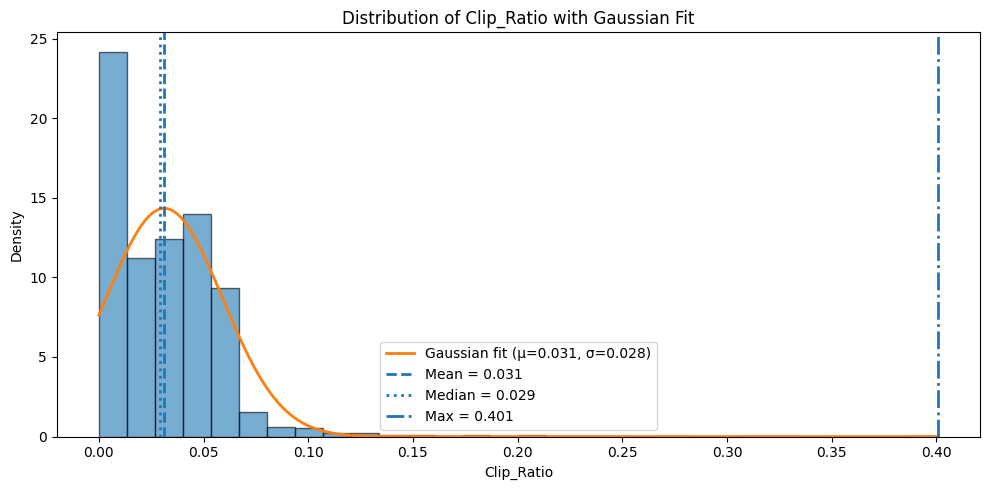

In [7]:
# Extract data and drop NaNs
x = zscores_df["Clip_Ratio"].dropna().values

# Summary statistics
mean_val = np.mean(x)
median_val = np.median(x)
max_val = np.max(x)
std_val = np.std(x, ddof=1)

# X range for Gaussian
x_range = np.linspace(x.min(), x.max(), 500)
pdf = norm.pdf(x_range, mean_val, std_val)

# Plot
plt.figure(figsize=(10, 5))

# Histogram (density)
plt.hist(x, bins=30, density=True, alpha=0.6, edgecolor="black")

# Gaussian fit
plt.plot(x_range, pdf, linewidth=2, label=f"Gaussian fit (μ={mean_val:.3f}, σ={std_val:.3f})")

# Reference lines
plt.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.3f}")
plt.axvline(median_val, linestyle=":", linewidth=2, label=f"Median = {median_val:.3f}")
plt.axvline(max_val, linestyle="-.", linewidth=2, label=f"Max = {max_val:.3f}")

# Labels
plt.xlabel("Clip_Ratio")
plt.ylabel("Density")
plt.title("Distribution of Clip_Ratio with Gaussian Fit")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
zscores_df["Record"].unique()

array(['cu01', 'cu02', 'cu03', 'cu04', 'cu05', 'cu06', 'cu07', 'cu08',
       'cu09', 'cu10', 'cu11', 'cu12', 'cu13', 'cu14', 'cu15', 'cu16',
       'cu17', 'cu18', 'cu19', 'cu20', 'cu21', 'cu22', 'cu23', 'cu24',
       'cu25', 'cu26', 'cu27', 'cu28', 'cu29', 'cu30', 'cu31', 'cu32',
       'cu33', 'cu34', 'cu35', 'Case_0001', 'Case_0002', 'Case_0003',
       'Case_0004', 'Case_0006', 'Case_0007', 'Case_0008', 'Case_0009',
       'Case_0010', 'FID0009', 'FID0011', 'FID0013'], dtype=object)

In [9]:
# Identify records starting with Case or FID
mask_records = zscores_df["Record"].str.startswith(("Case", "FID"))

# Create an index mask to drop first 50 rows per matching Record
drop_idx = (
    zscores_df[mask_records]
    .groupby("Record")
    .head(50)
    .index
)

# Drop those rows
zscores_df = zscores_df.drop(index=drop_idx).reset_index(drop=True)

In [10]:
zscores_df["Record"].unique()

array(['cu01', 'cu02', 'cu03', 'cu04', 'cu05', 'cu06', 'cu07', 'cu08',
       'cu09', 'cu10', 'cu11', 'cu12', 'cu13', 'cu14', 'cu15', 'cu16',
       'cu17', 'cu18', 'cu19', 'cu20', 'cu21', 'cu22', 'cu23', 'cu24',
       'cu25', 'cu26', 'cu27', 'cu28', 'cu29', 'cu30', 'cu31', 'cu32',
       'cu33', 'cu34', 'cu35', 'Case_0001', 'Case_0002', 'Case_0003',
       'Case_0004', 'Case_0006', 'Case_0007', 'Case_0008', 'Case_0009',
       'Case_0010', 'FID0009', 'FID0011', 'FID0013'], dtype=object)

### XGBoosting Regression


Fold 1
 Test subjects: ['FID0009', 'Case_0001', 'Case_0007', 'cu03', 'cu08', 'cu15', 'cu20', 'cu26']
  FID : ['FID0009']
  Case: ['Case_0001', 'Case_0007']
  CU  : ['cu03', 'cu08', 'cu15', 'cu20', 'cu26']

Fold 2
 Test subjects: ['FID0011', 'Case_0002', 'Case_0008', 'cu04', 'cu09', 'cu16', 'cu22', 'cu27']
  FID : ['FID0011']
  Case: ['Case_0002', 'Case_0008']
  CU  : ['cu04', 'cu09', 'cu16', 'cu22', 'cu27']

Fold 3
 Test subjects: ['FID0013', 'Case_0003', 'Case_0009', 'cu05', 'cu10', 'cu17', 'cu23', 'cu28']
  FID : ['FID0013']
  Case: ['Case_0003', 'Case_0009']
  CU  : ['cu05', 'cu10', 'cu17', 'cu23', 'cu28']

Fold 4
 Test subjects: ['Case_0004', 'Case_0010', 'cu06', 'cu11', 'cu18', 'cu24', 'cu29']
  FID : []
  Case: ['Case_0004', 'Case_0010']
  CU  : ['cu06', 'cu11', 'cu18', 'cu24', 'cu29']

Fold 5
 Test subjects: ['Case_0006', 'cu07', 'cu13', 'cu19', 'cu25', 'cu32']
  FID : []
  Case: ['Case_0006']
  CU  : ['cu07', 'cu13', 'cu19', 'cu25', 'cu32']

================ Fold 1 ===========

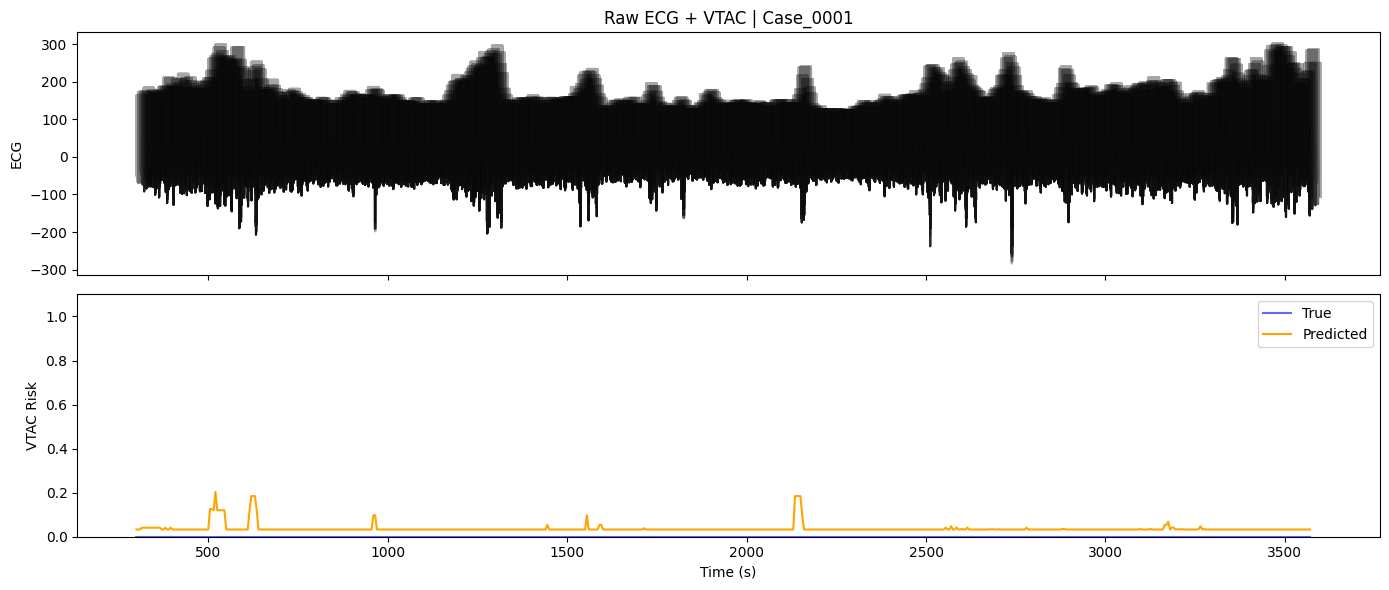

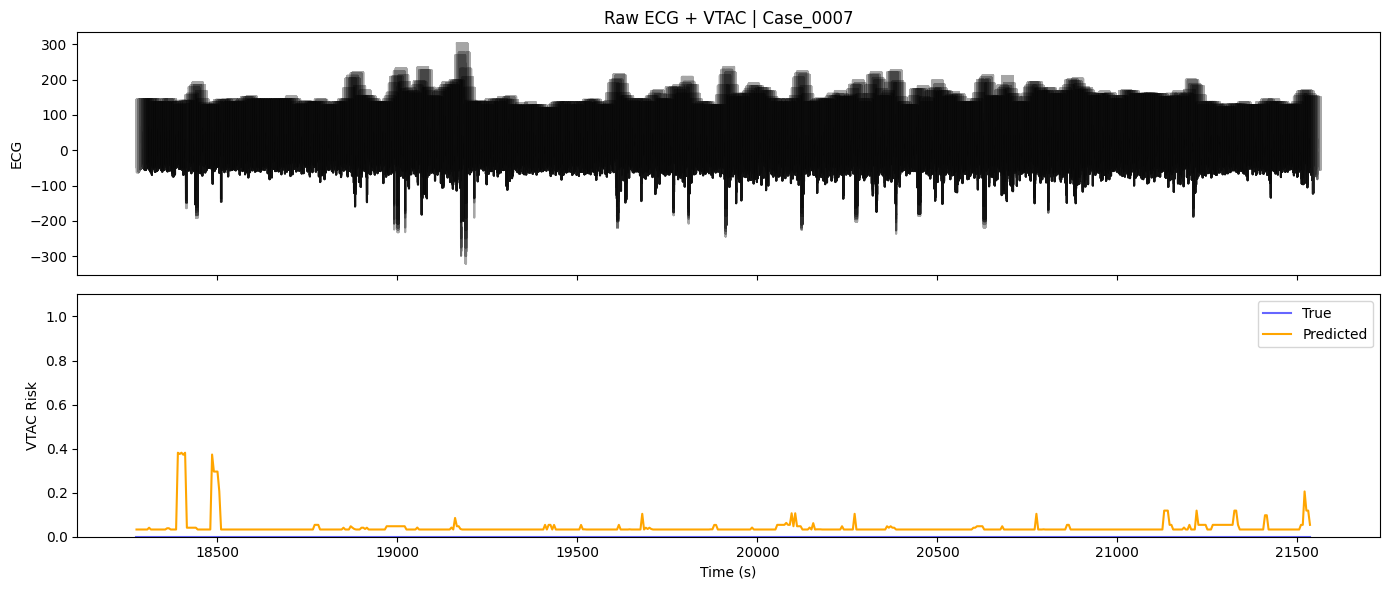

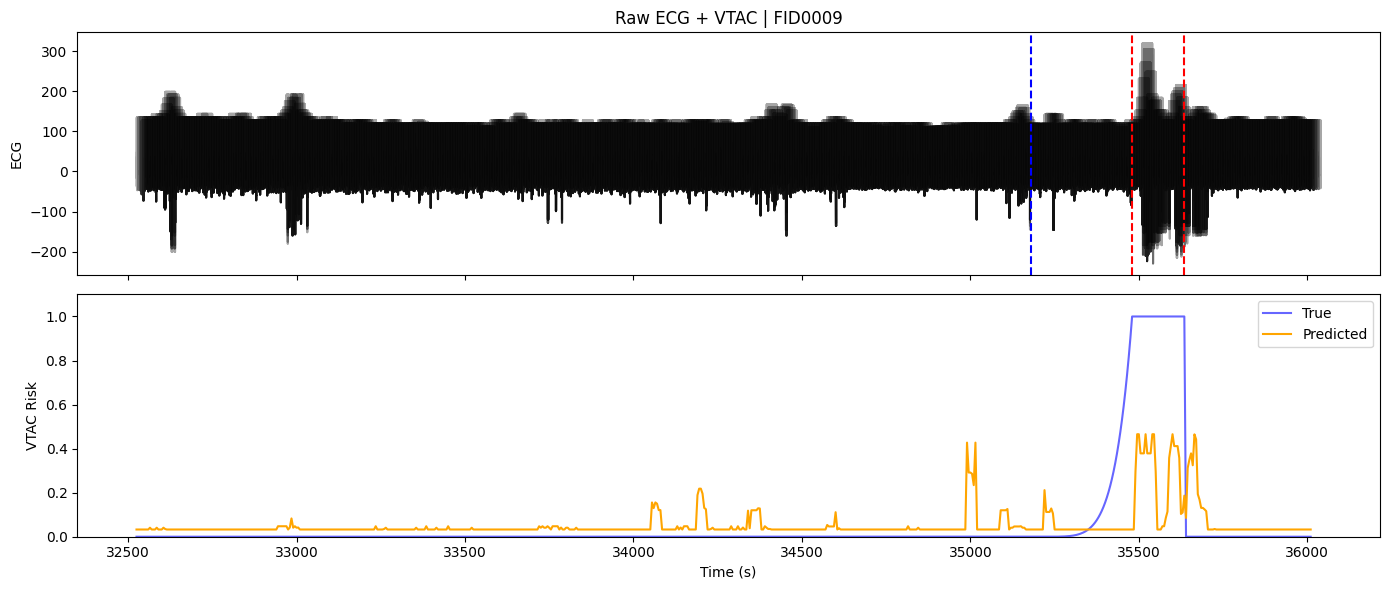

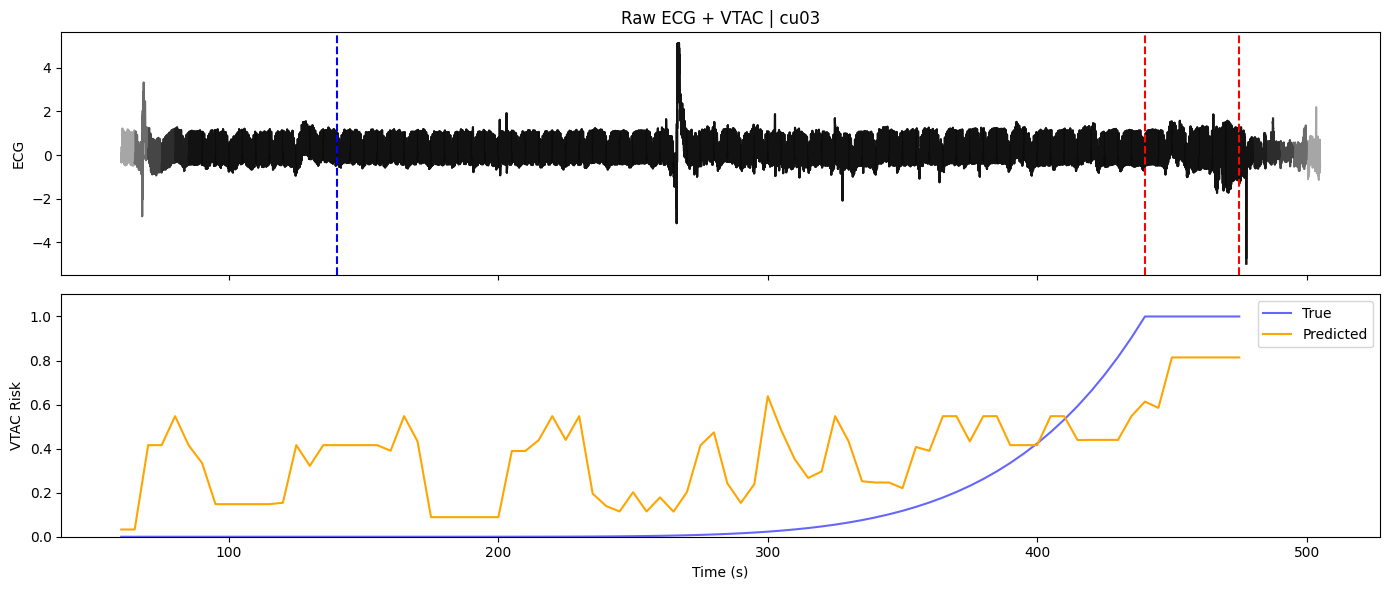

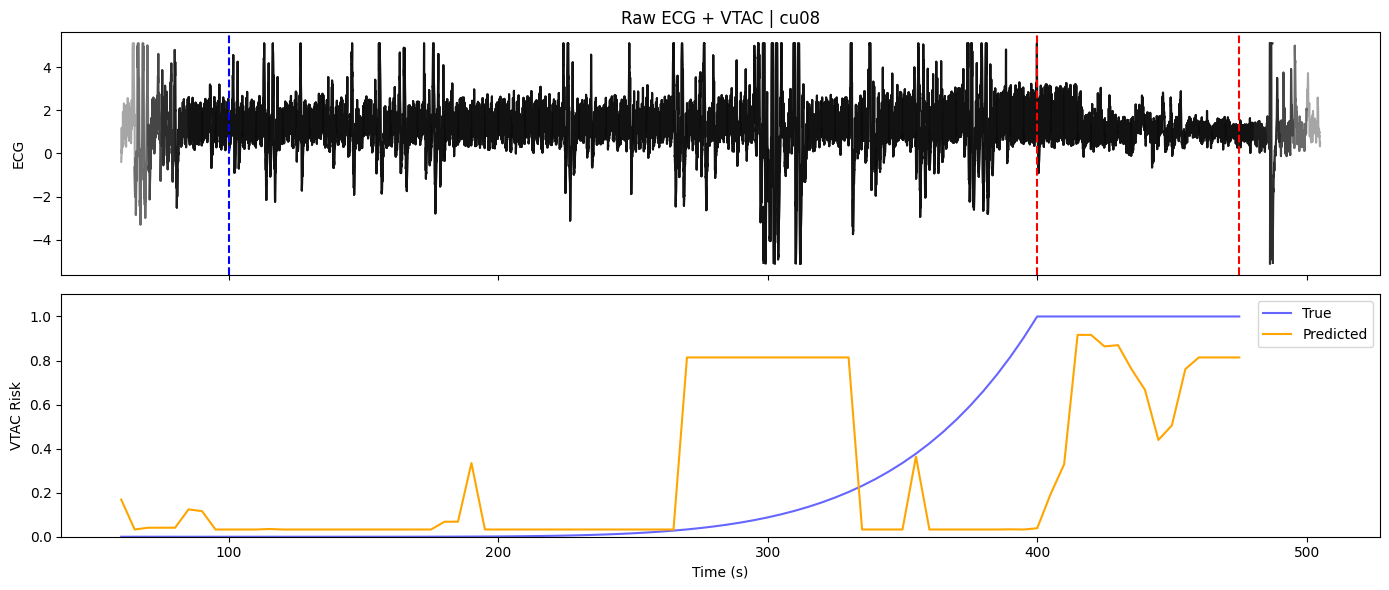

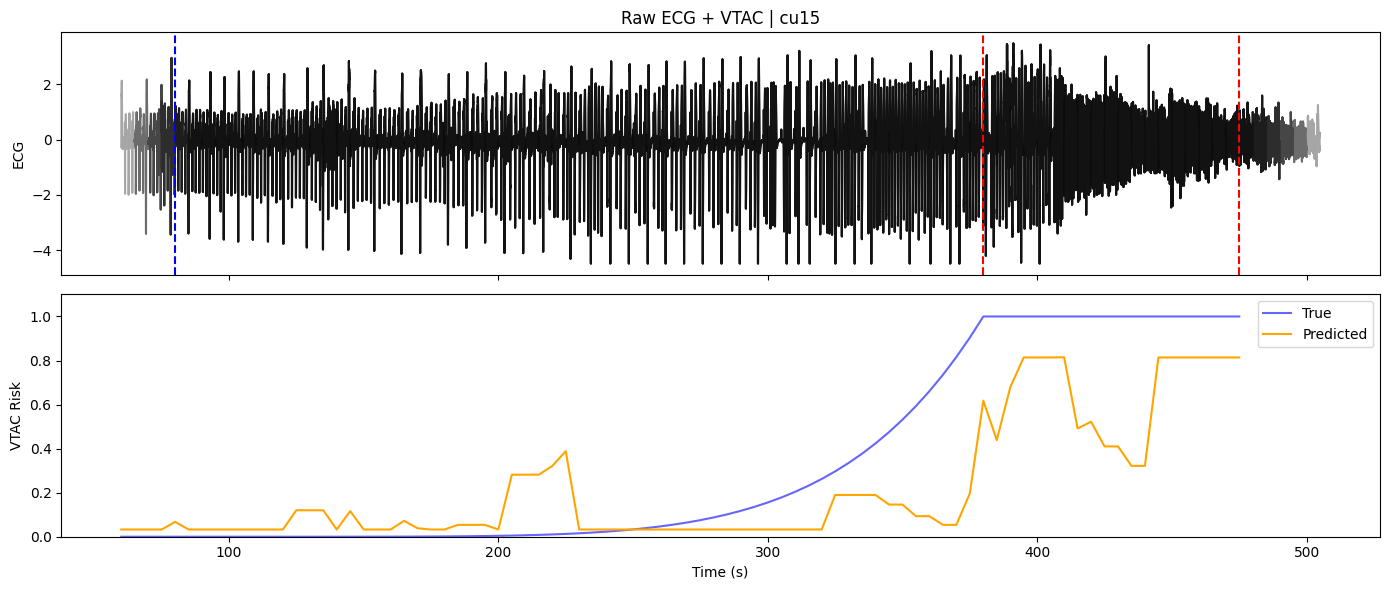

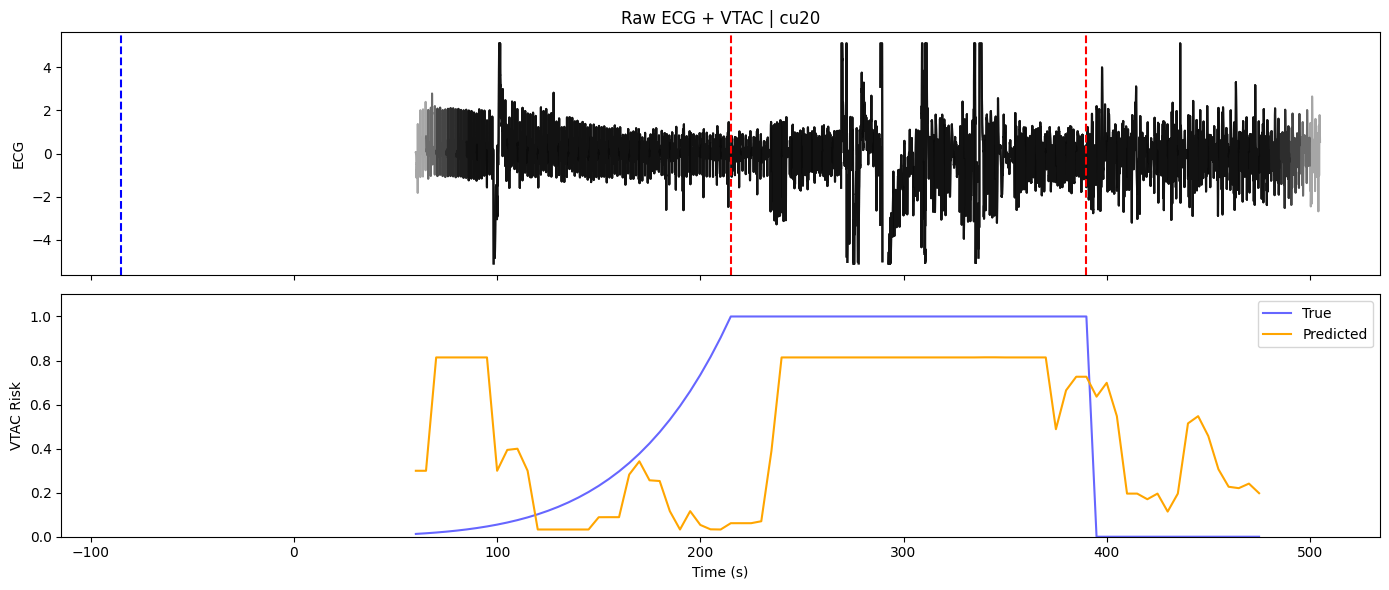

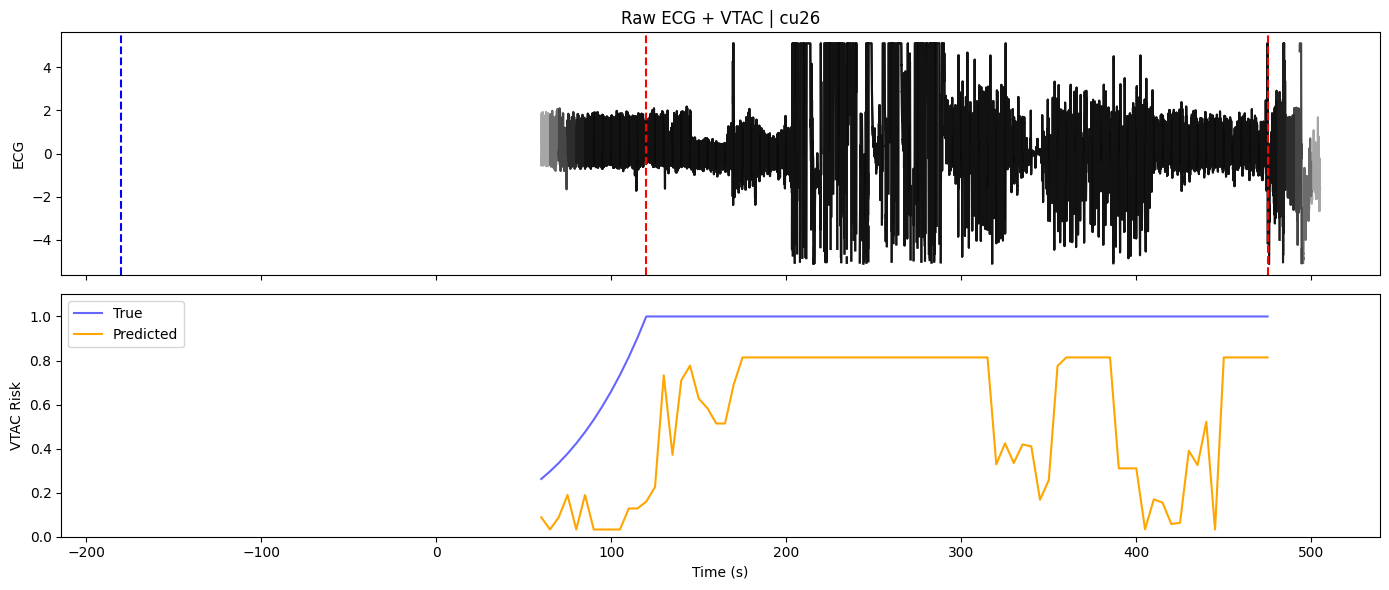


================ Fold 2 ================
RMSE (Train/Test): 0.1719 / 0.2265


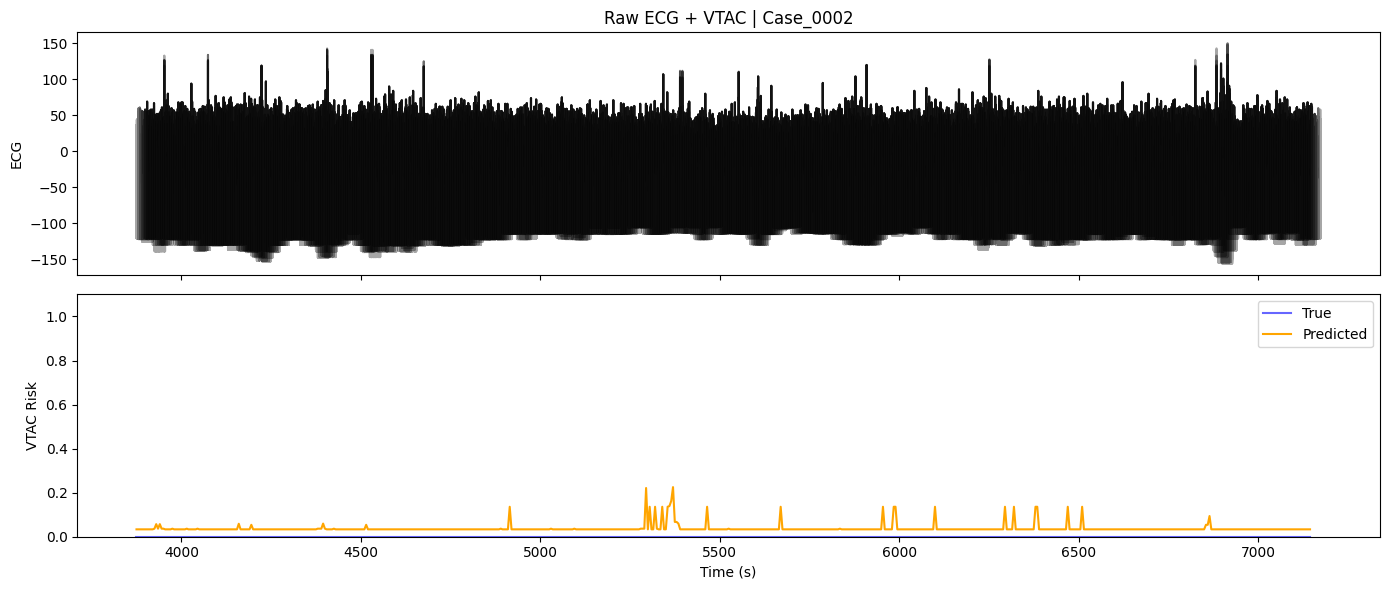

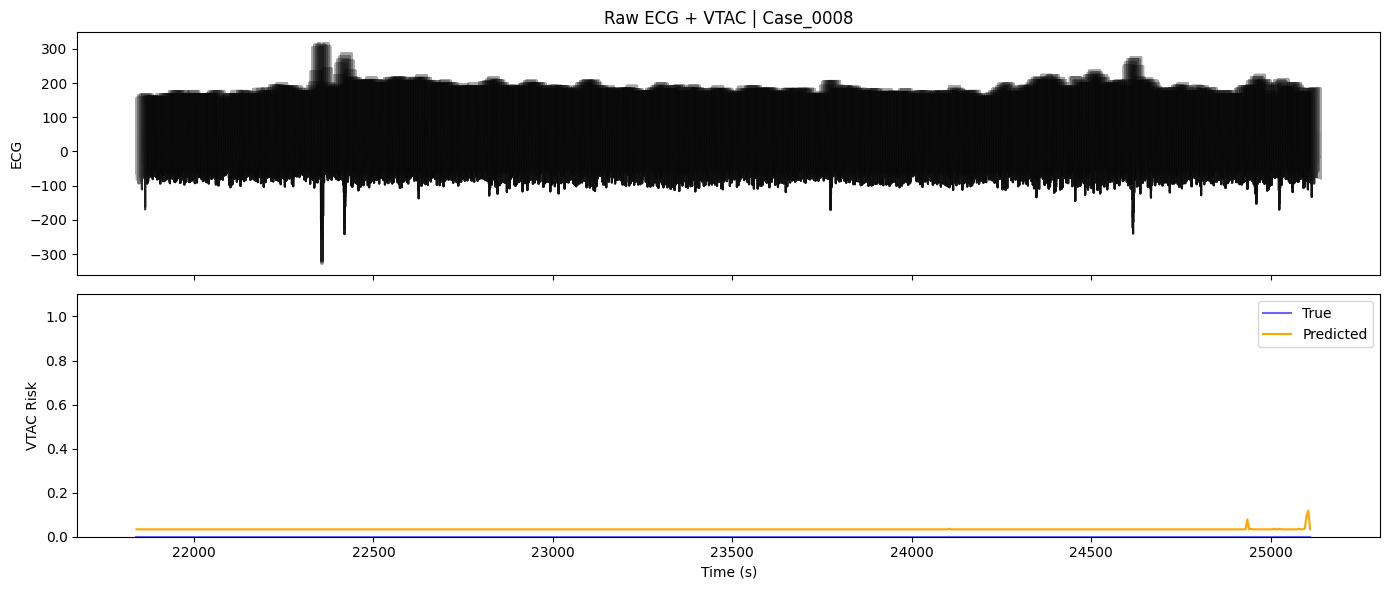

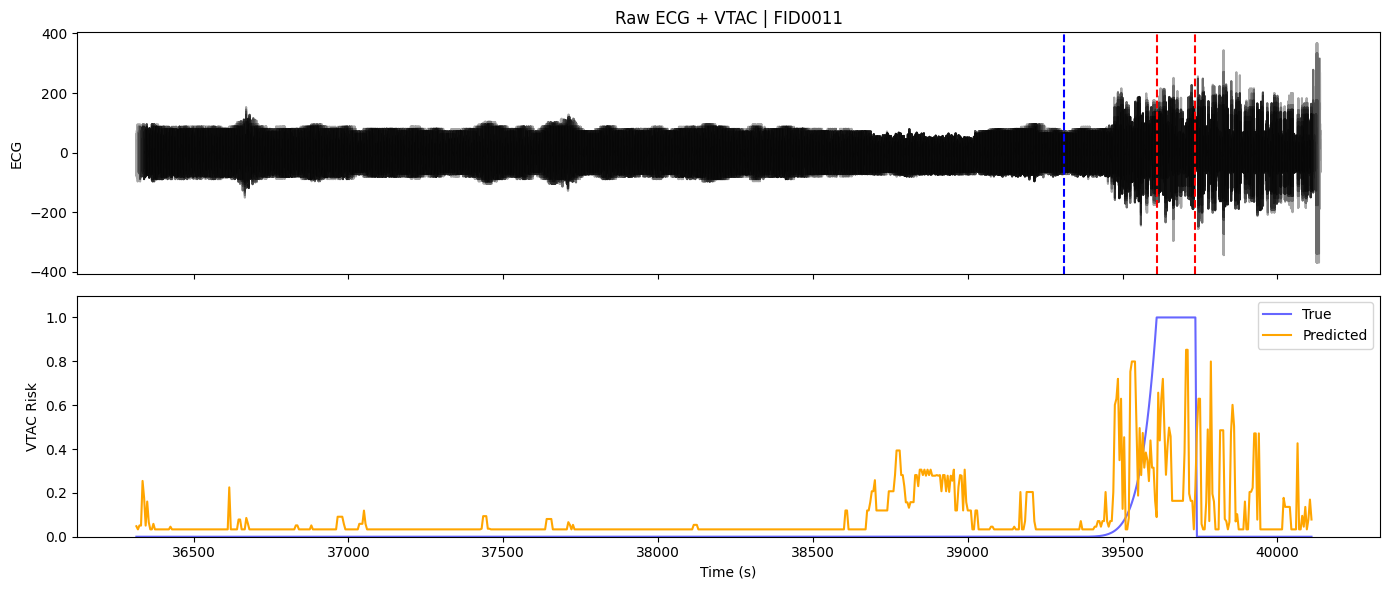

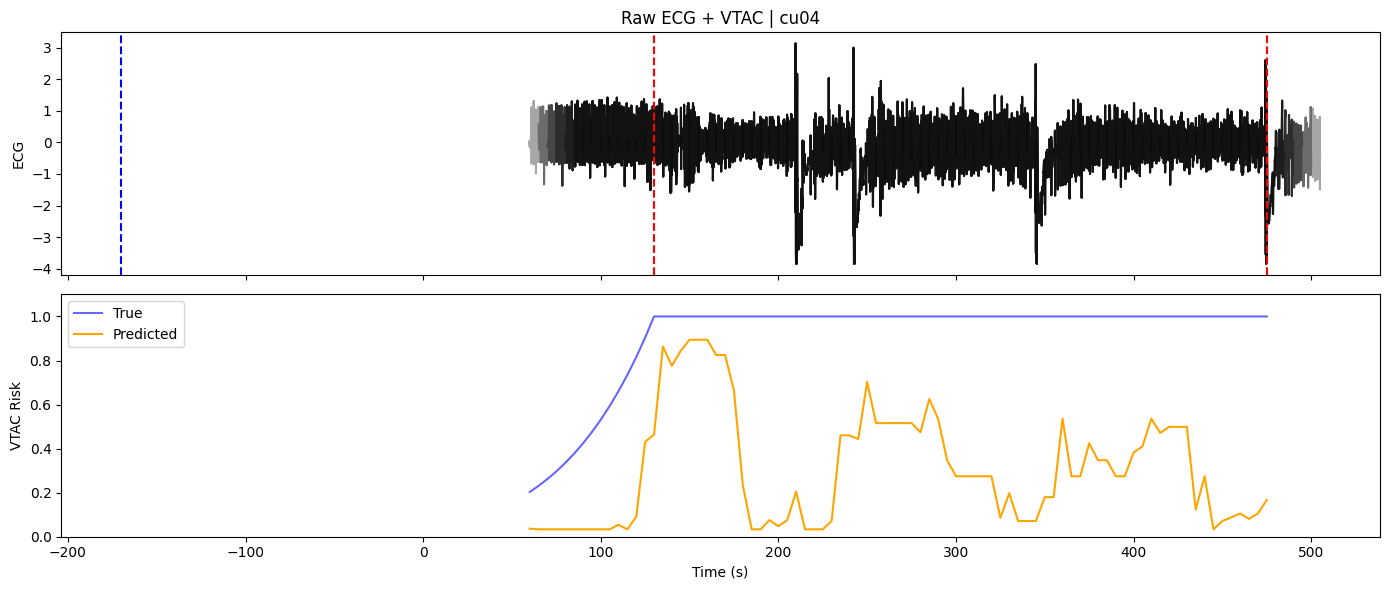

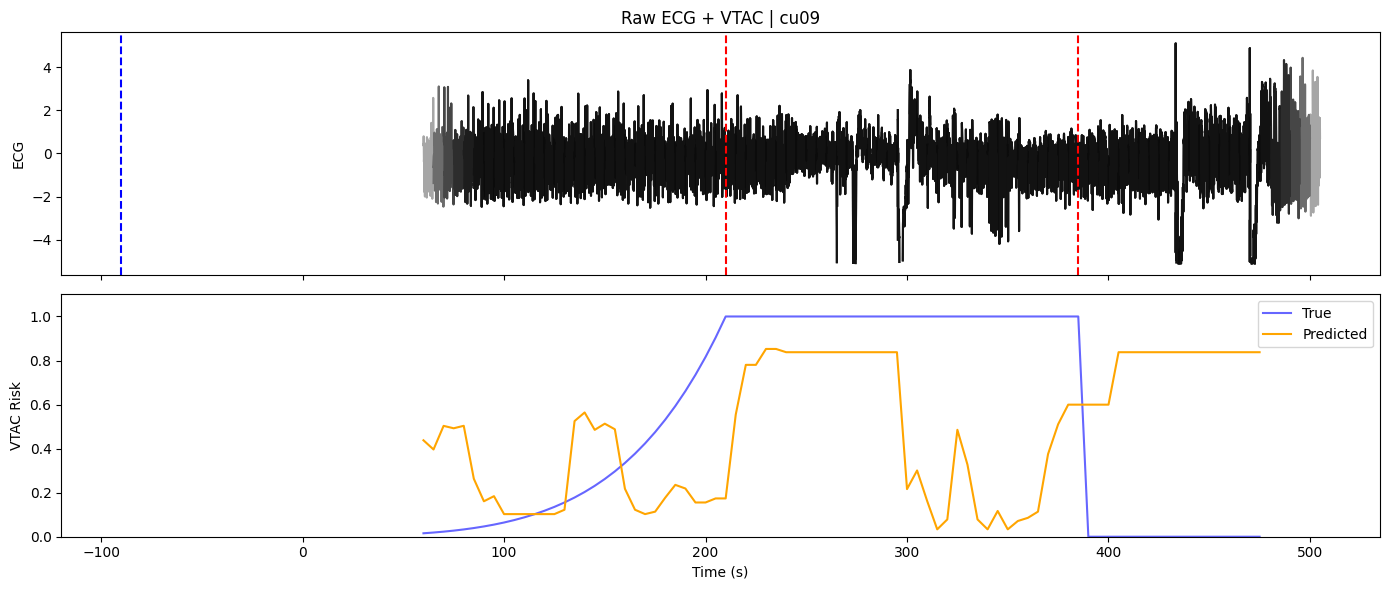

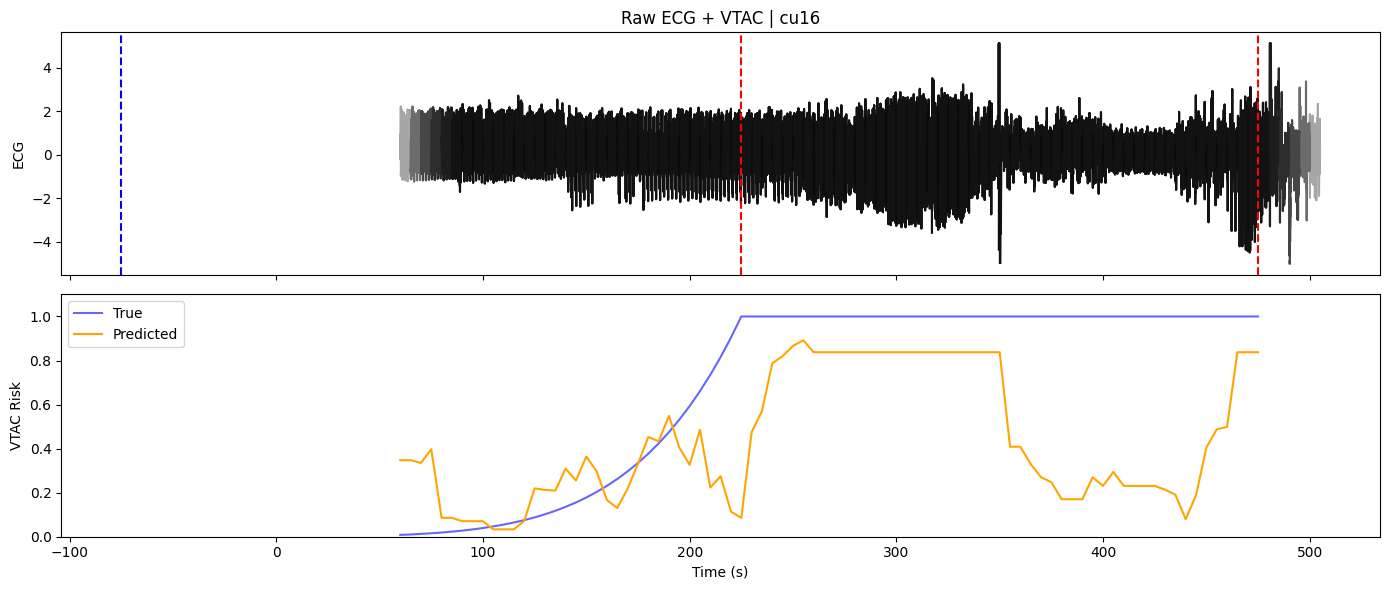

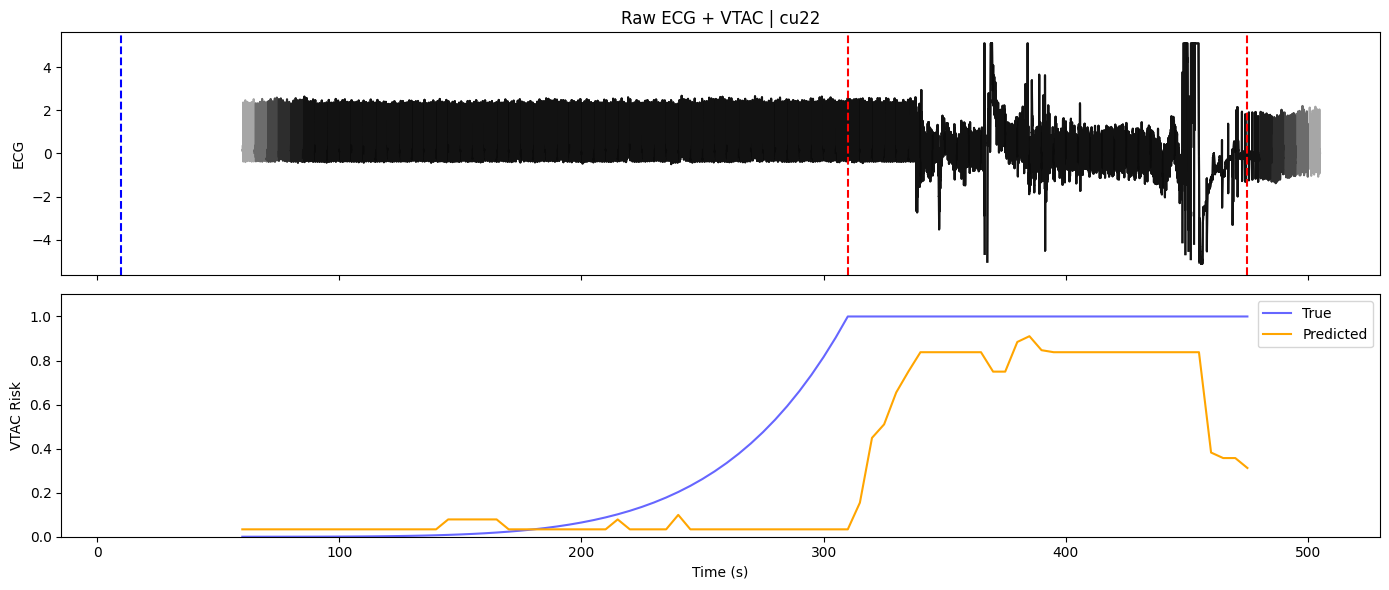

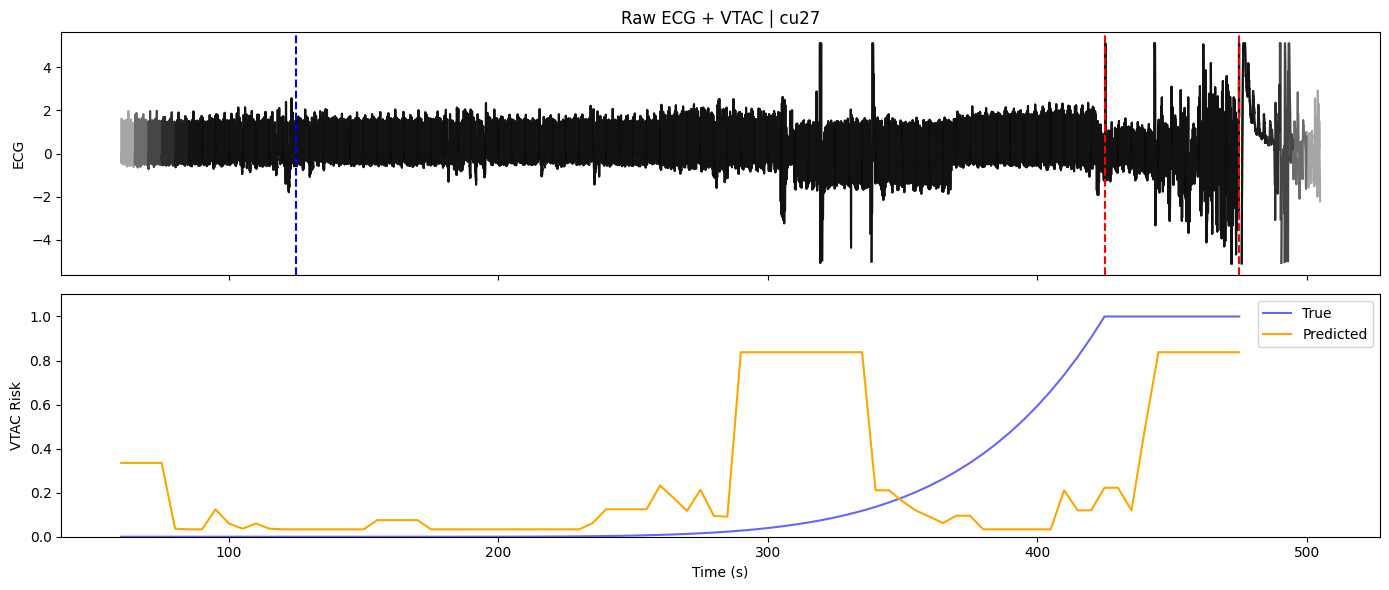


================ Fold 3 ================
RMSE (Train/Test): 0.1734 / 0.1947


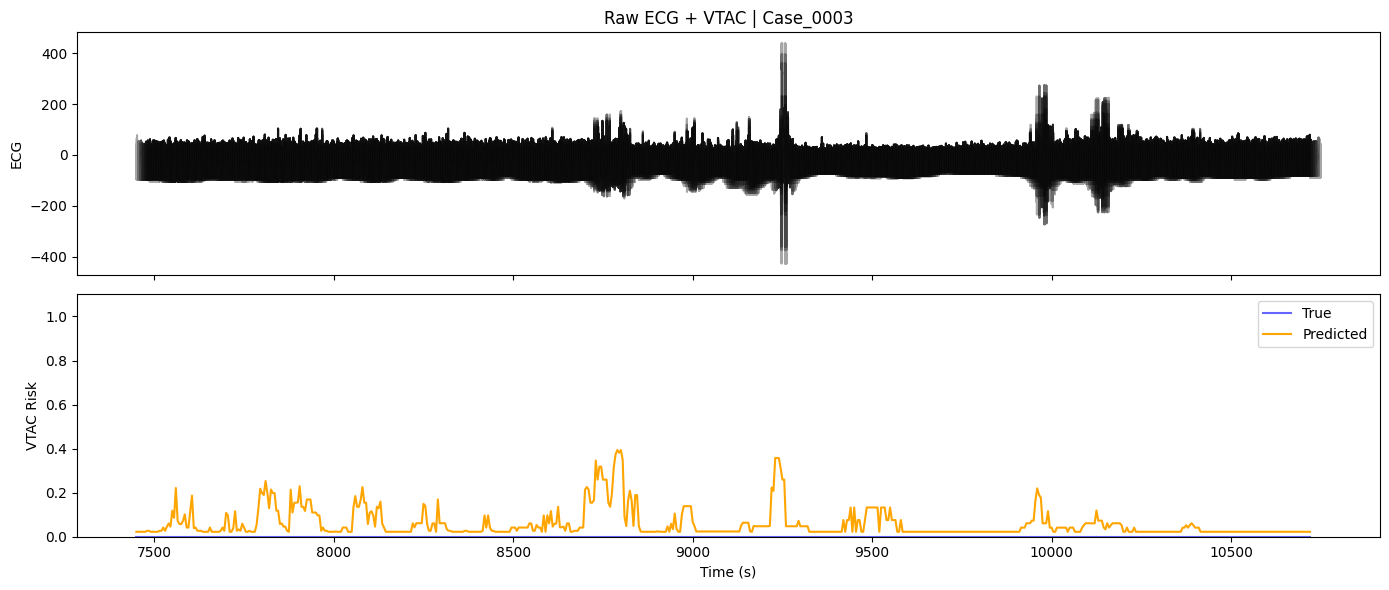

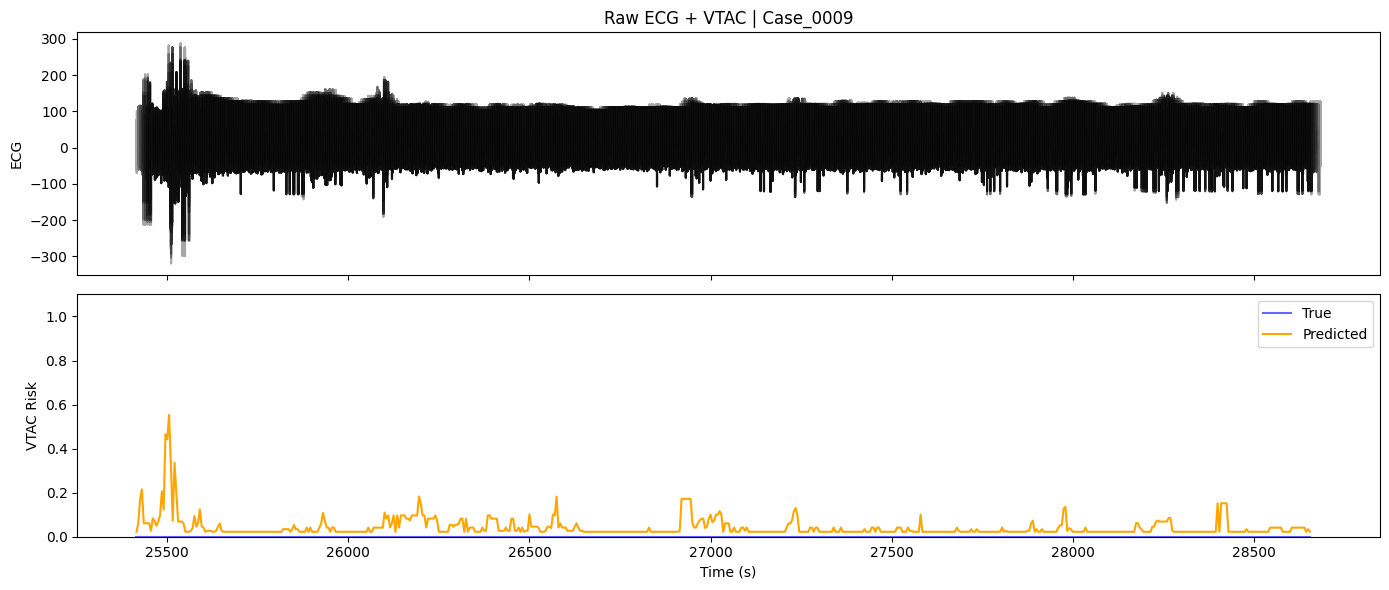

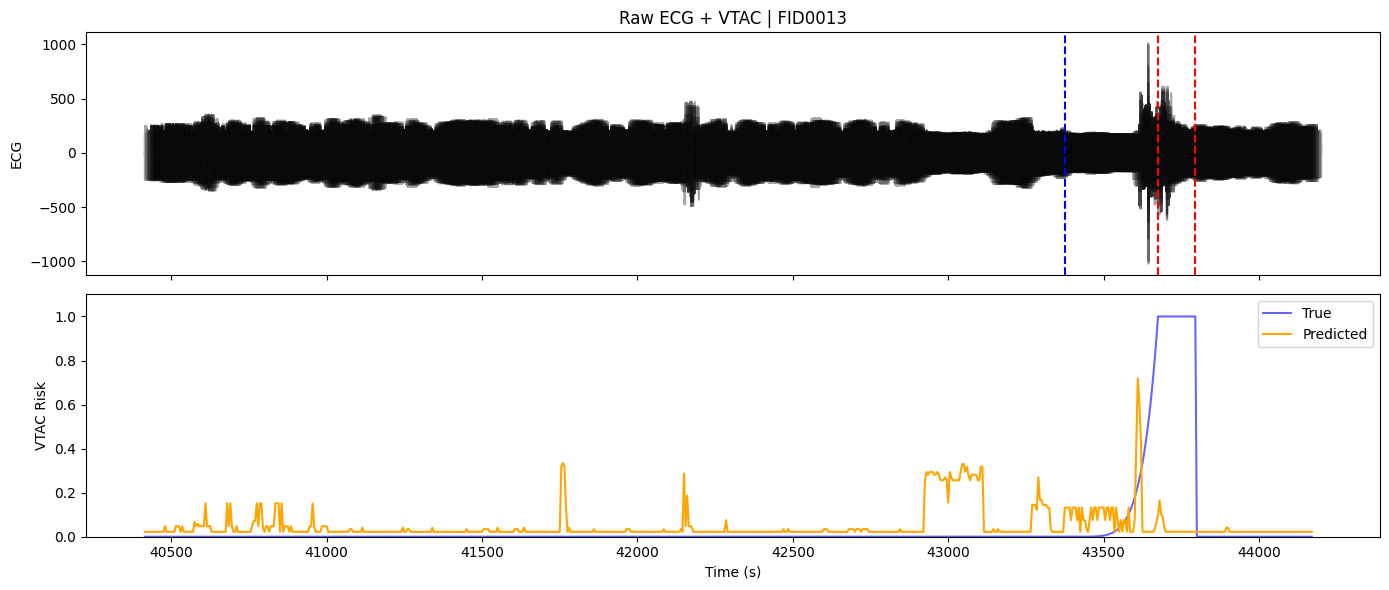

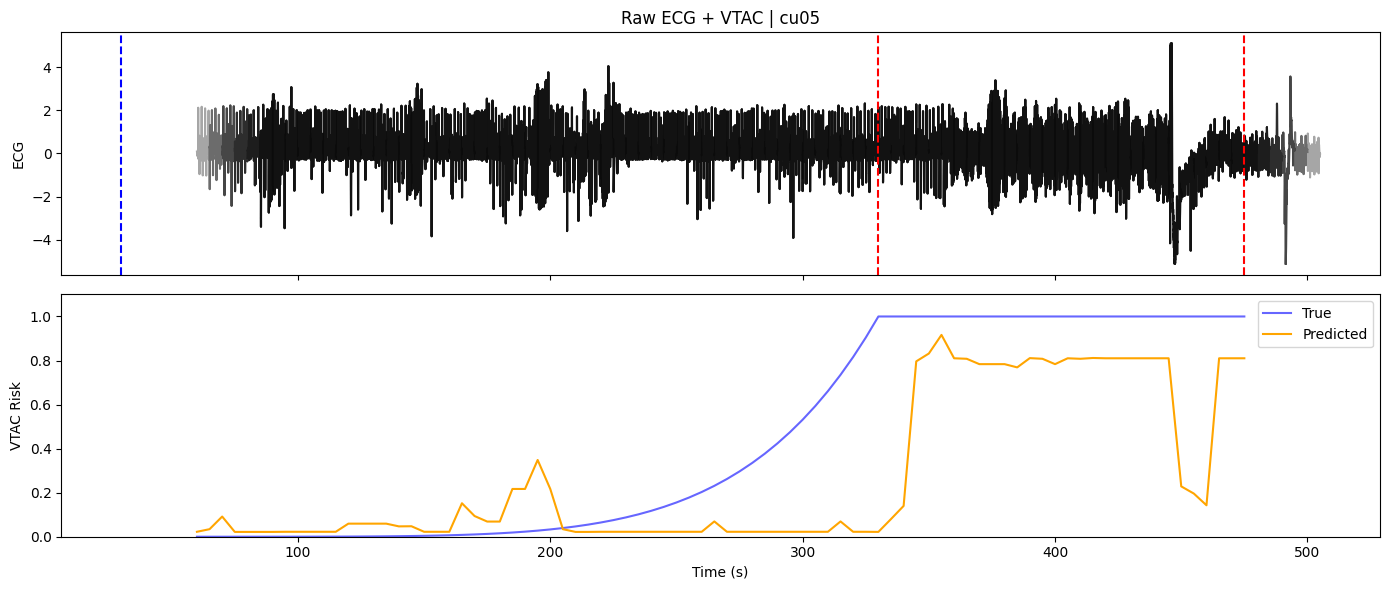

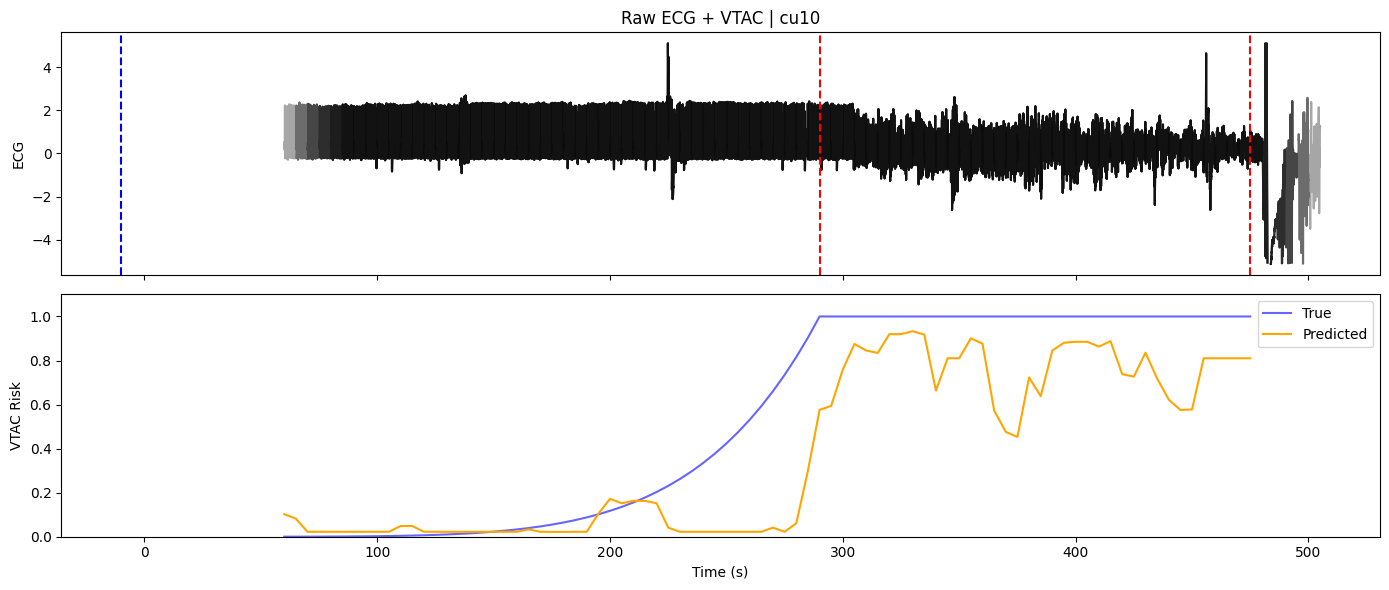

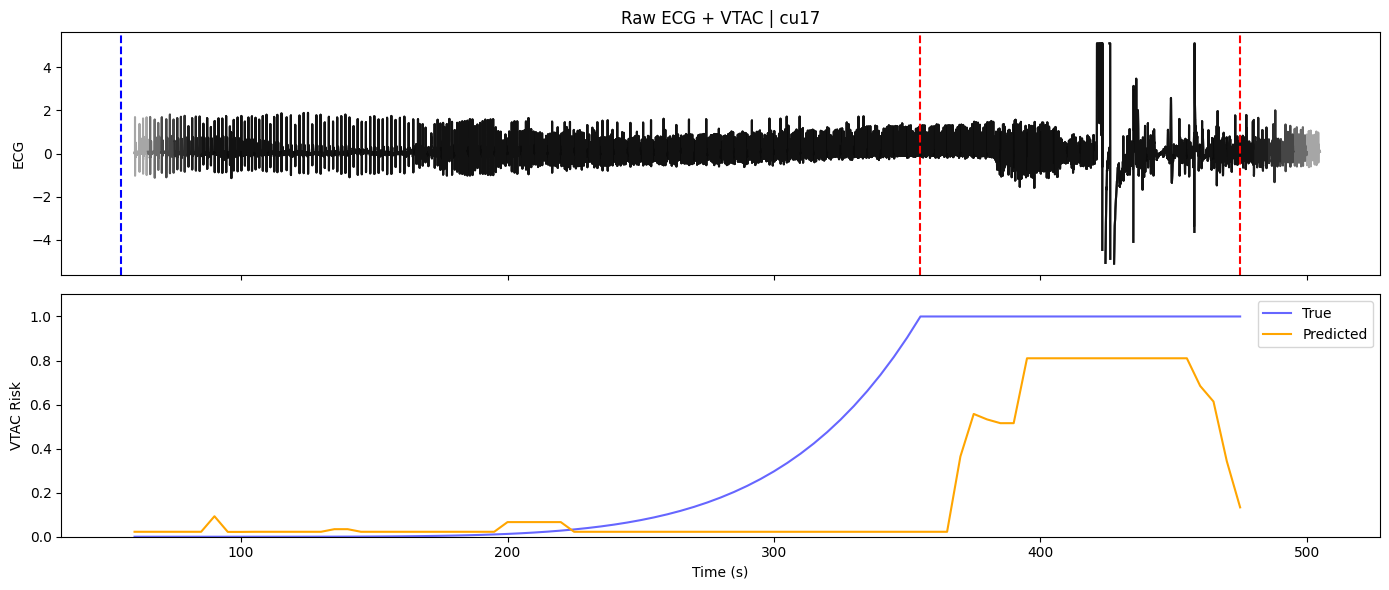

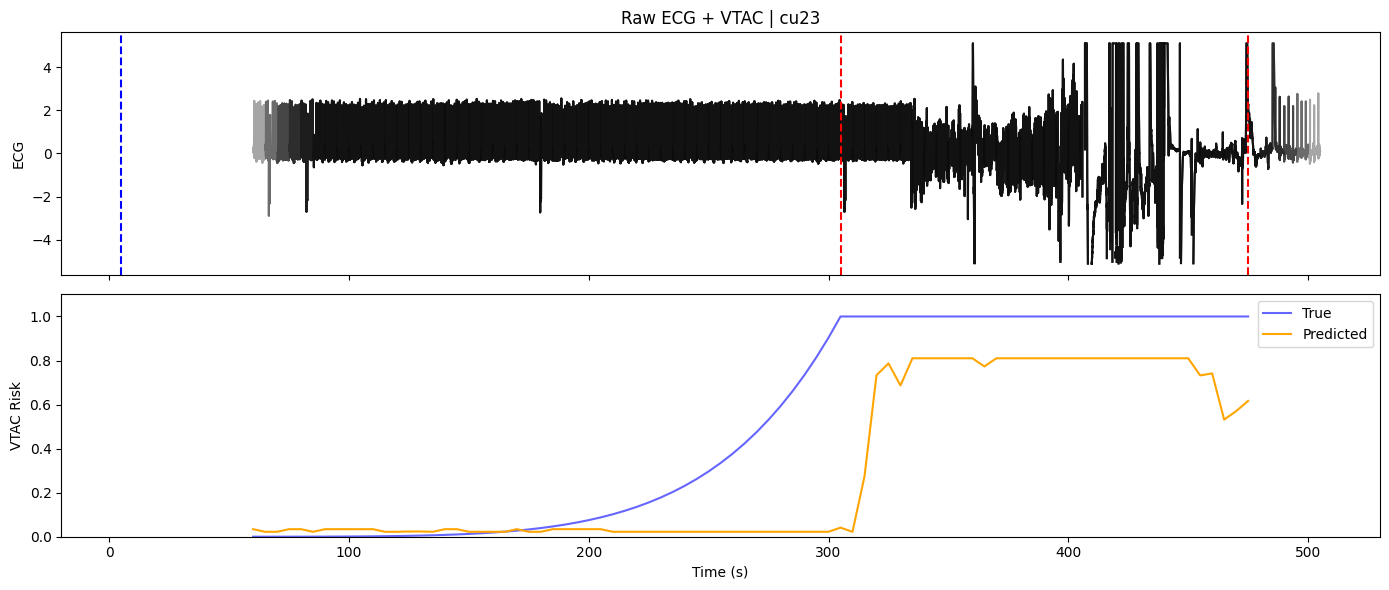

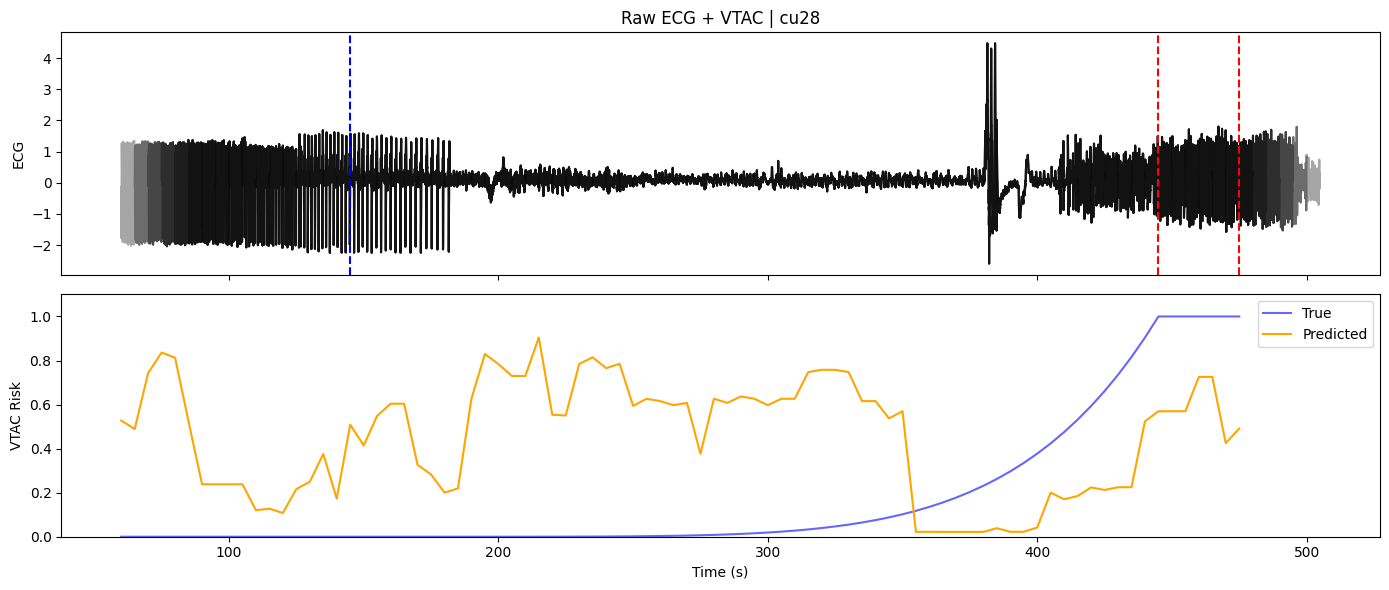


================ Fold 4 ================
RMSE (Train/Test): 0.1772 / 0.2341


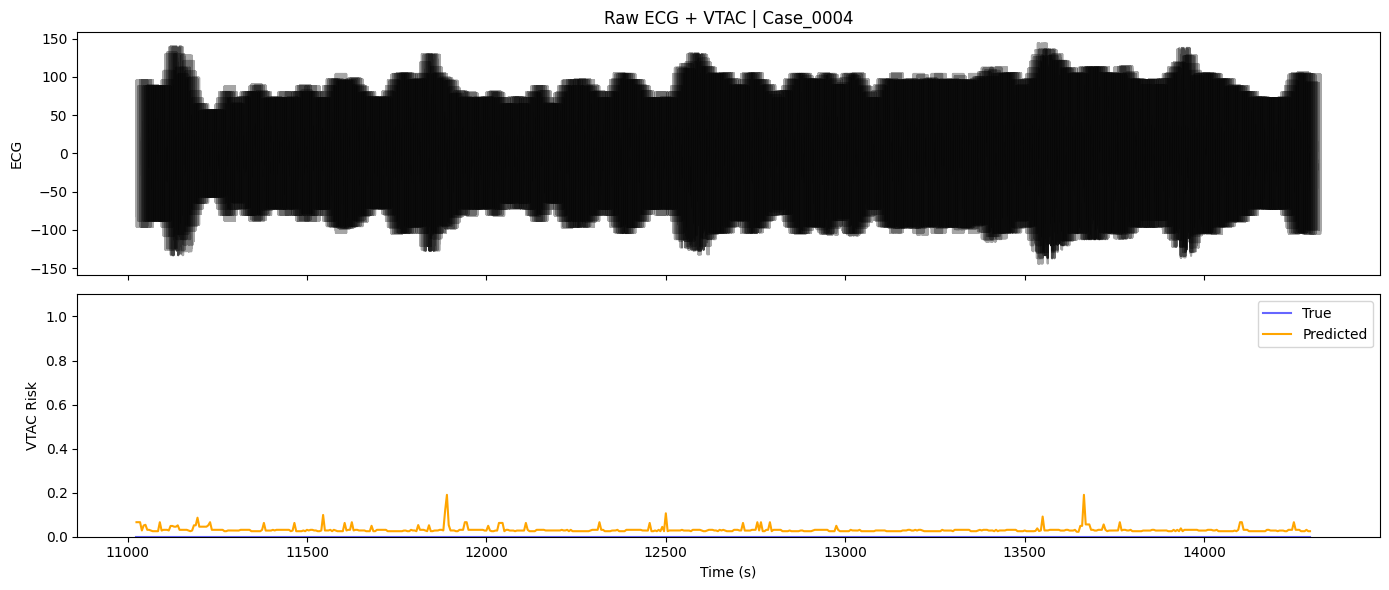

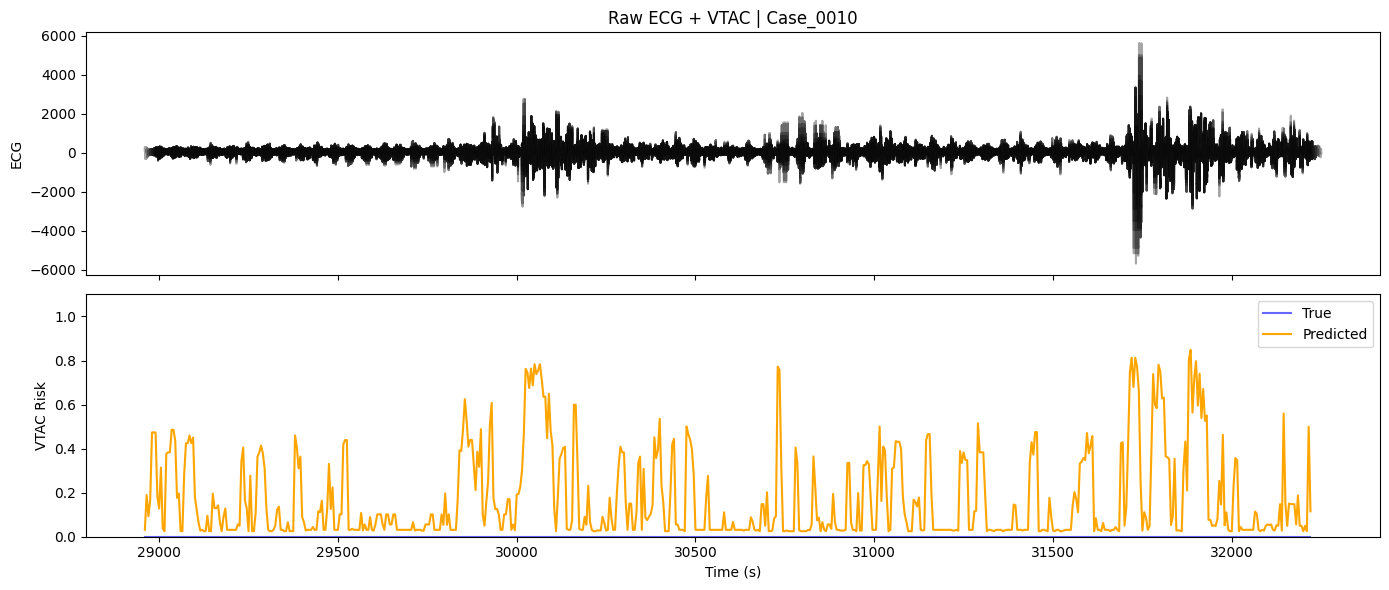

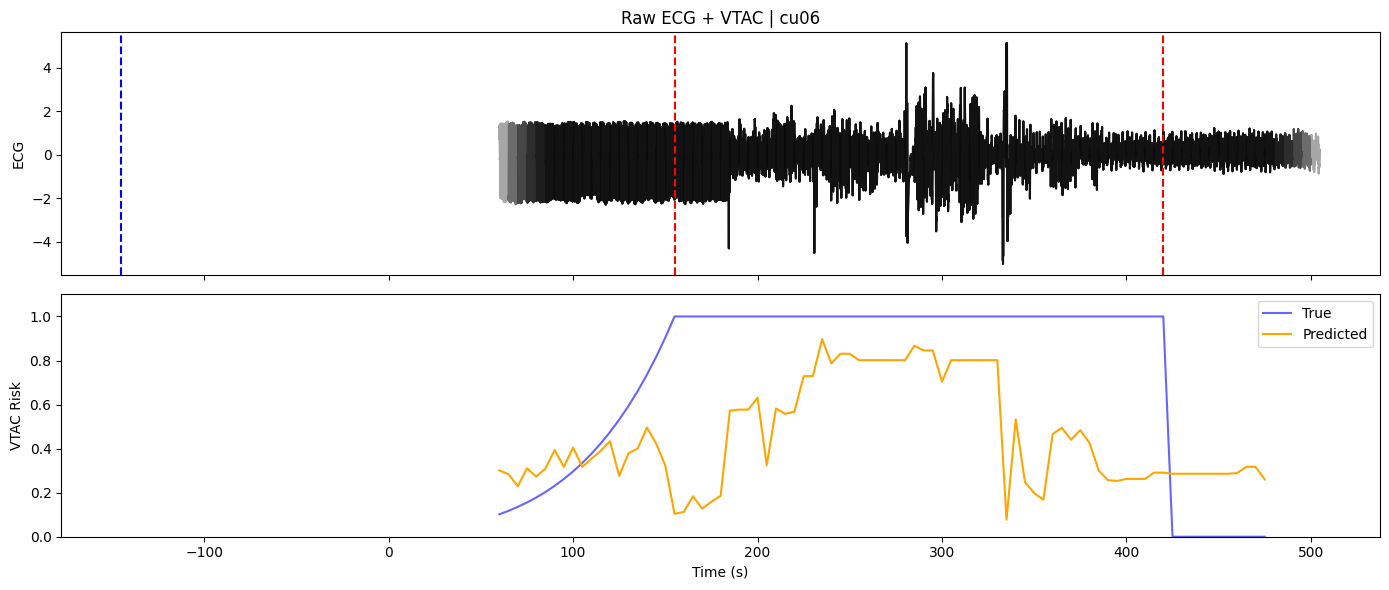

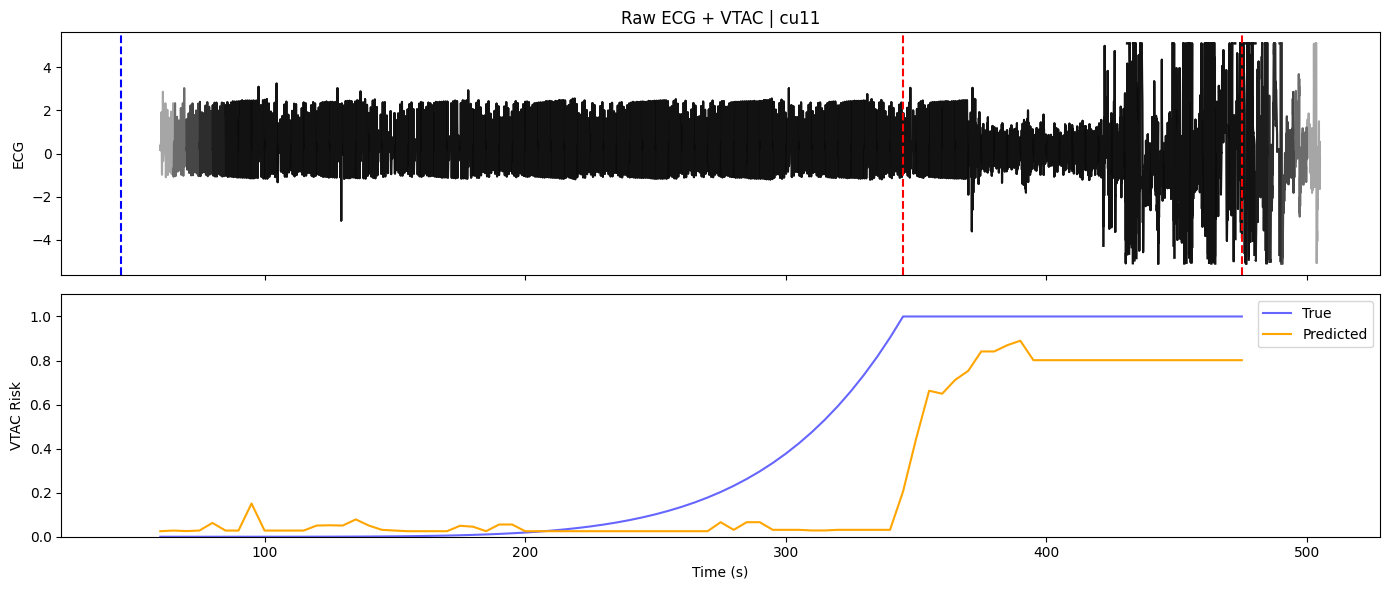

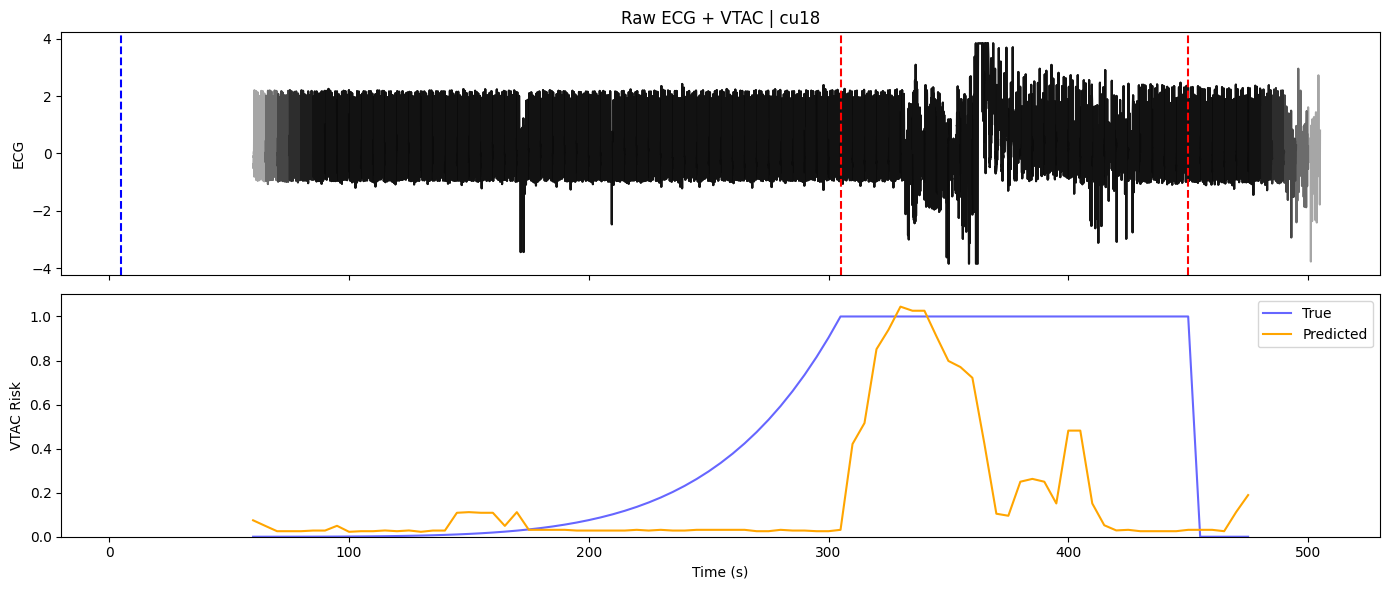

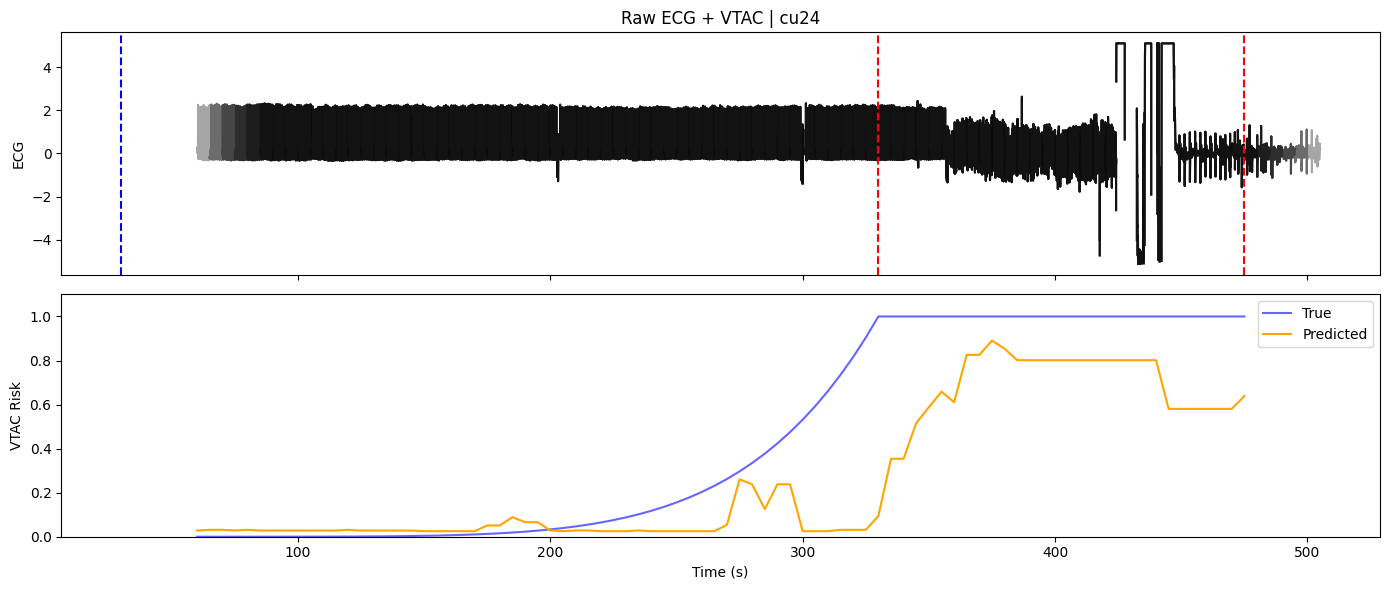

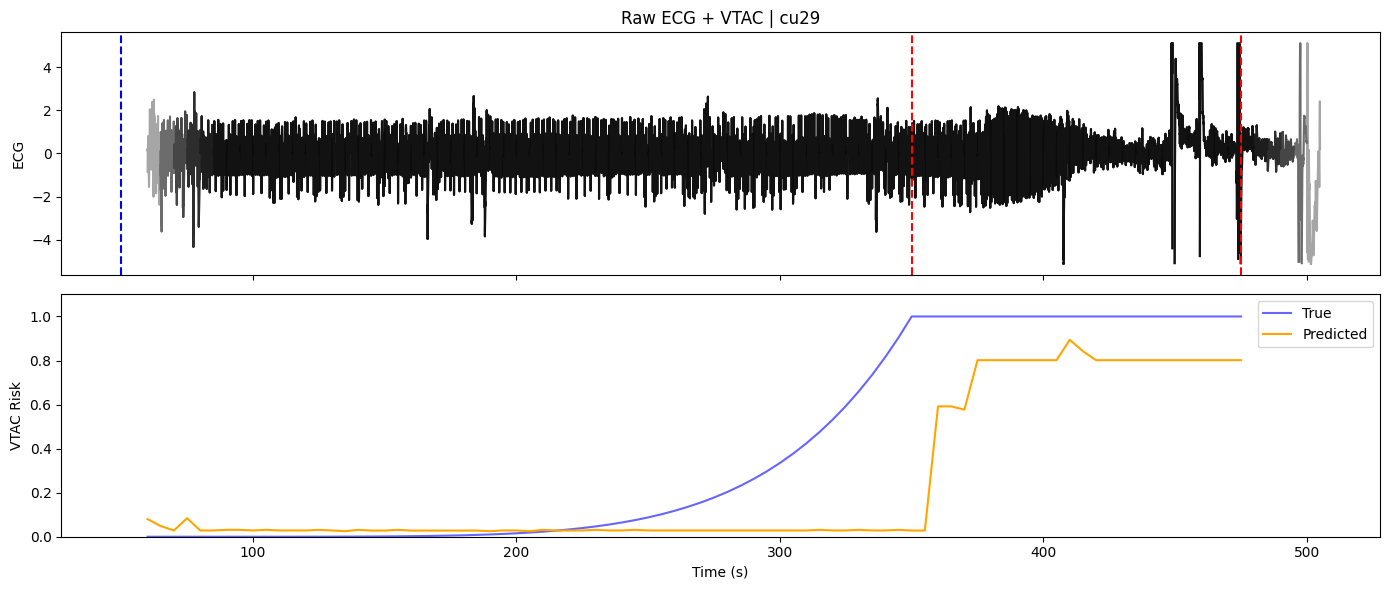


================ Fold 5 ================
RMSE (Train/Test): 0.1782 / 0.2155


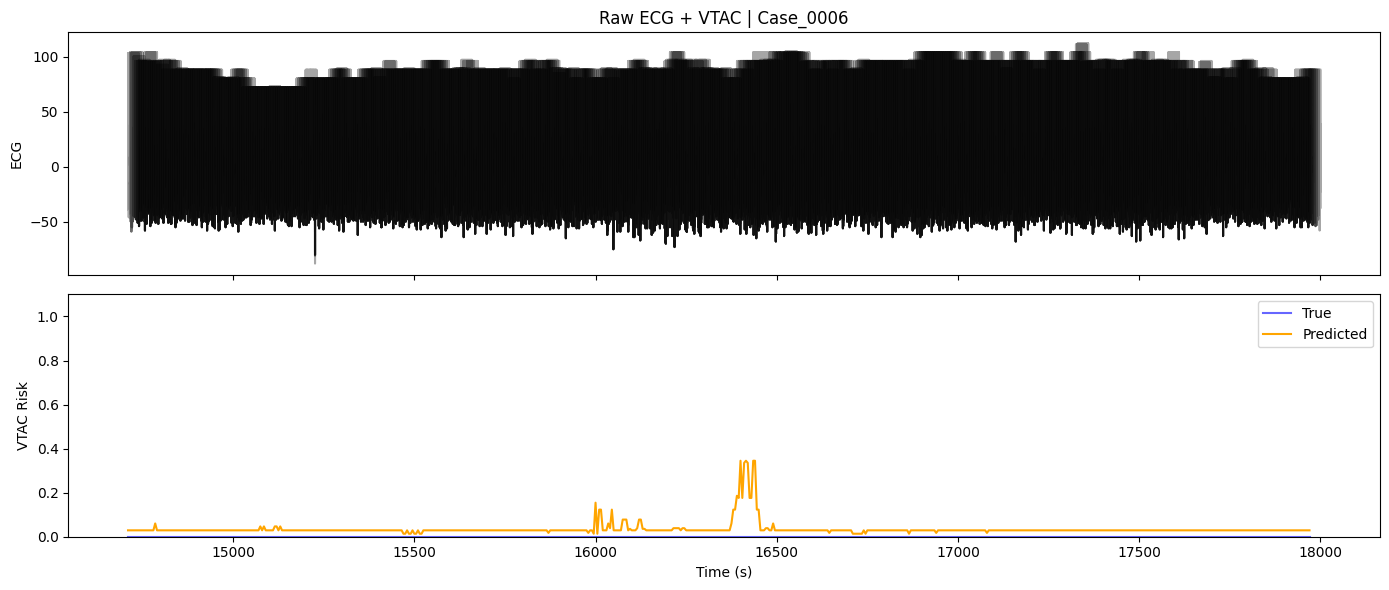

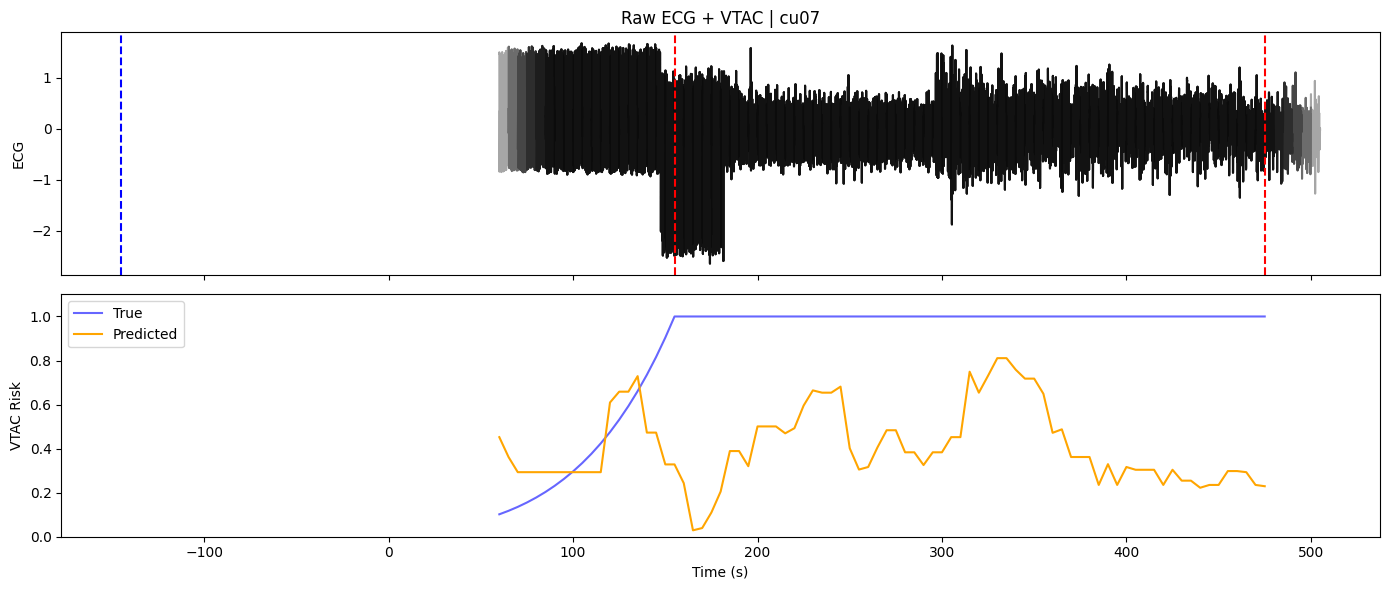

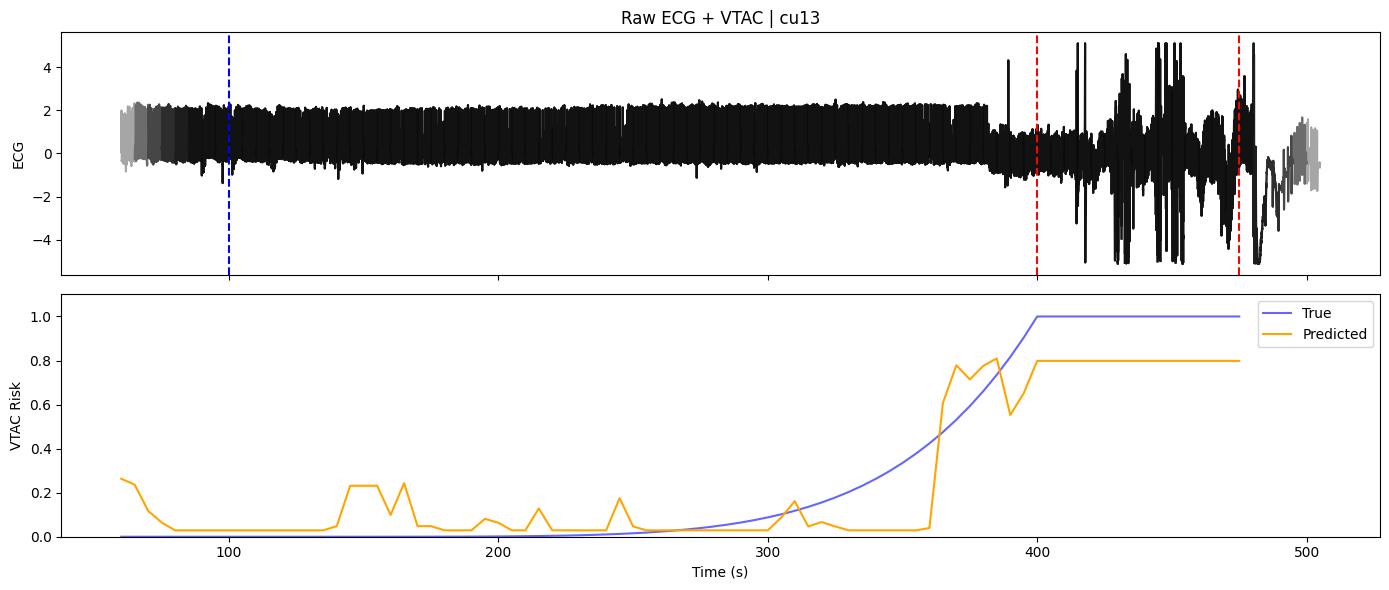

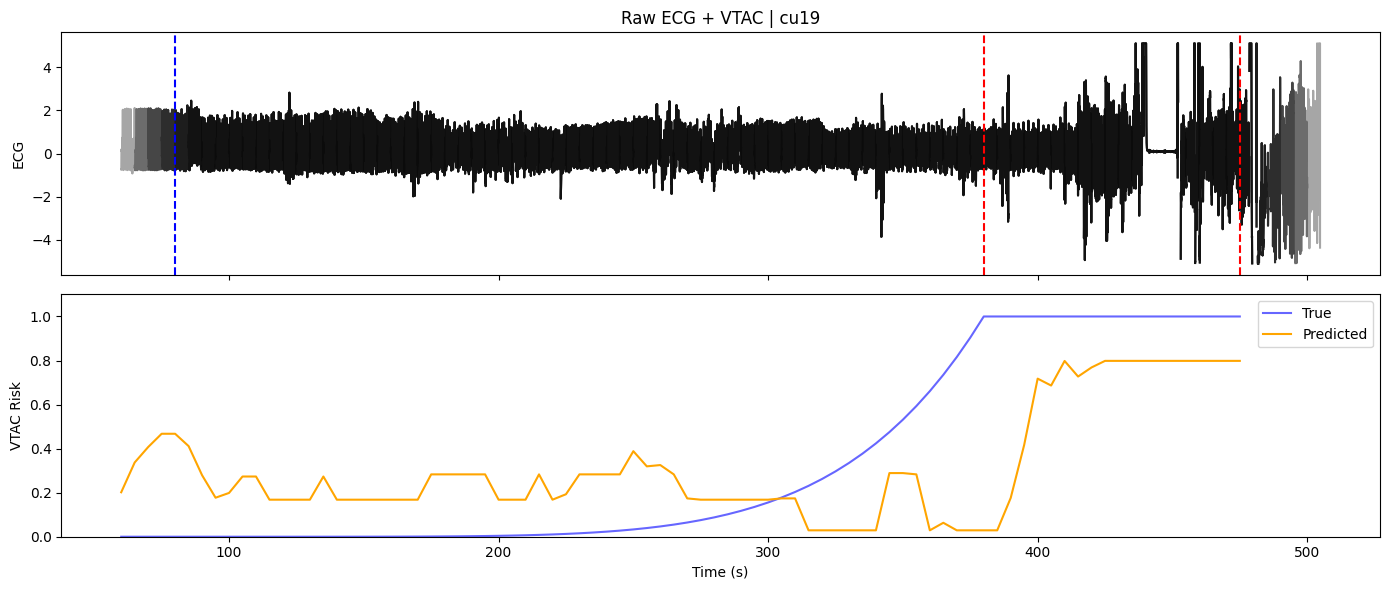

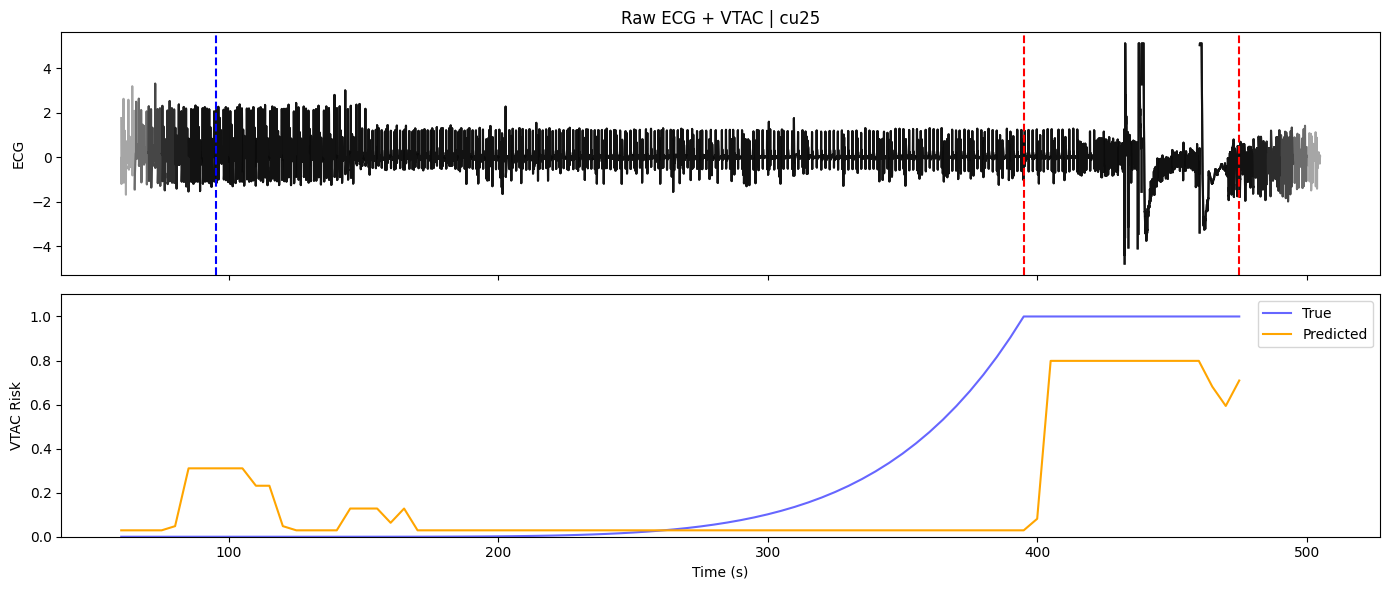

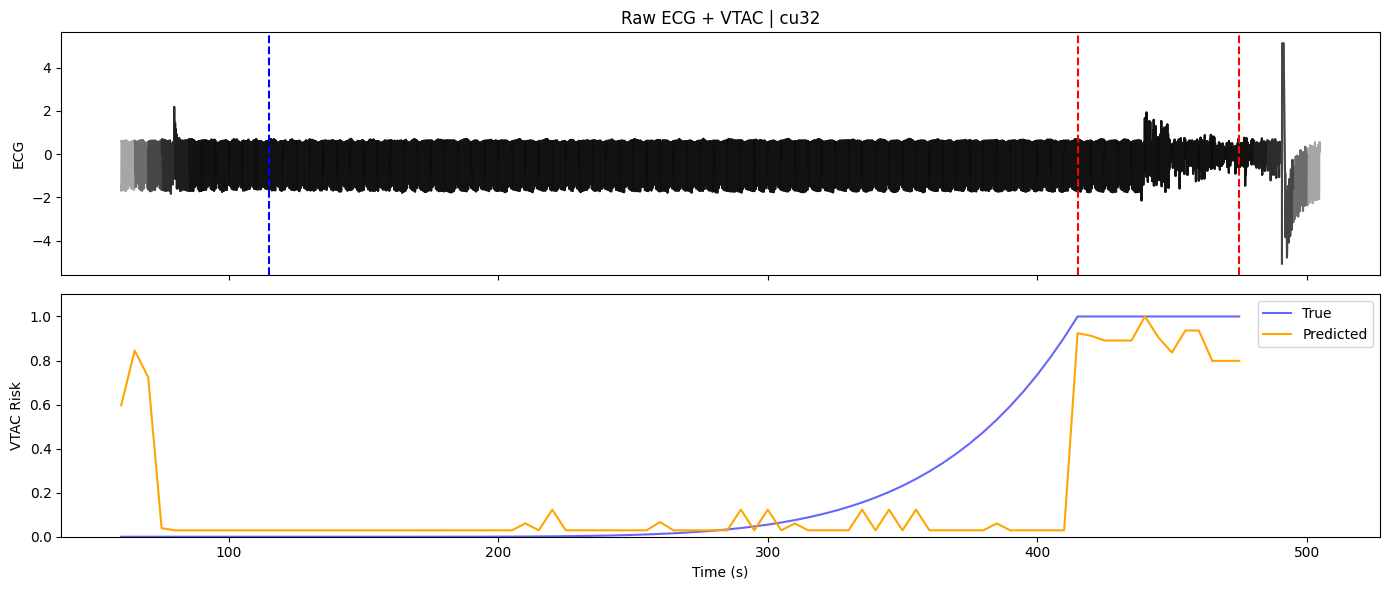


CROSS-VALIDATION PERFORMANCE
Train RMSE: 0.1765 ± 0.0035
Test  RMSE: 0.2115 ± 0.0181

POOLED PERFORMANCE
Pooled Train RMSE: 0.1766
Pooled Test  RMSE: 0.2103


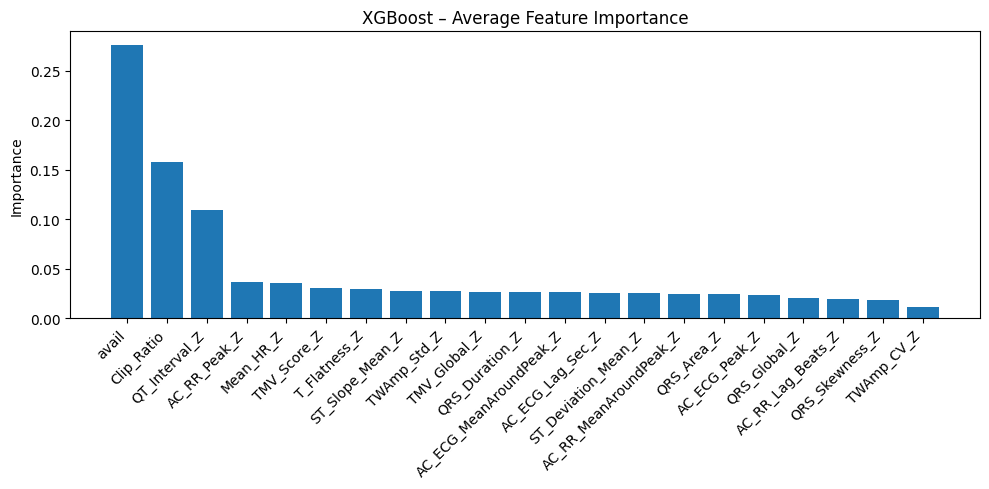

In [11]:
# ===============================
# CONFIG
# ===============================
random_state = 42
n_folds = 5
sigmoid_seconds = 300

features = [
    'QT_Interval_Z','TMV_Score_Z','Mean_HR_Z','QRS_Global_Z',"Clip_Ratio",
    'T_Flatness_Z','TWAmp_Std_Z','TWAmp_CV_Z','TMV_Global_Z',
    'QRS_Duration_Z','QRS_Area_Z','QRS_Skewness_Z','avail',
    'ST_Deviation_Mean_Z','ST_Slope_Mean_Z',
    'AC_ECG_Peak_Z','AC_ECG_Lag_Sec_Z','AC_ECG_MeanAroundPeak_Z',
    'AC_RR_Peak_Z','AC_RR_Lag_Beats_Z','AC_RR_MeanAroundPeak_Z'
]

def get_sampling_rate(record_id):
    return 250 if str(record_id).lower().startswith("cu") else 240

# ===============================
# LOAD DATA
# ===============================
df = zscores_df.copy()
excluded_subjects = [
    'cu01','cu02','cu12','cu14','cu21','cu30','cu31','cu33','cu34','cu35'
]
df = df[~df["Record"].isin(excluded_subjects)].copy()

# ===============================
# REGRESSION LABEL (300s ramp)
# ===============================
df["VTAC_Label_Regression"] = 0.0

for record_id in df["Record"].unique():

    fs = get_sampling_rate(record_id)
    sigmoid_samples = int(sigmoid_seconds * fs)

    subj_idx = df["Record"] == record_id
    subj_df = df.loc[subj_idx]

    vtac_rows = subj_df[subj_df["VTAC_Label"] == 1]
    if vtac_rows.empty:
        continue

    vtac_start = vtac_rows["Start"].min()
    start_min = max(0, vtac_start - sigmoid_samples)

    pre_mask = (
        subj_idx &
        (df["Start"] >= start_min) &
        (df["Start"] < vtac_start)
    )

    i = vtac_start - df.loc[pre_mask, "Start"].values
    t = -i / fs
    t_norm = (t + sigmoid_seconds) / sigmoid_seconds

    df.loc[pre_mask, "VTAC_Label_Regression"] = t_norm ** 6
    df.loc[subj_idx & (df["VTAC_Label"] == 1), "VTAC_Label_Regression"] = 1.0

# ===============================
# ML INPUTS
# ===============================
df = df.dropna(
    subset=features + ["VTAC_Label_Regression", "Record", "ECG_Raw", "Start"]
)

X = df[features].values
y = df["VTAC_Label_Regression"].values
groups = df["Record"].astype(str).values

# ===============================
# BUILD BALANCED SUBJECT FOLDS
# ===============================
subjects = np.unique(groups)

fid_subjects  = sorted([s for s in subjects if s.startswith("FID")])
case_subjects = sorted([s for s in subjects if s.startswith("Case_")])
cu_subjects   = sorted([s for s in subjects if s.lower().startswith("cu")])

fold_subjects = defaultdict(list)

for i, fid in enumerate(fid_subjects):
    fold_subjects[i % n_folds].append(fid)

for i, case in enumerate(case_subjects):
    fold_subjects[i % n_folds].append(case)

for i, cu in enumerate(cu_subjects):
    fold_subjects[i % n_folds].append(cu)

fold_indices = []

for fold_id in range(n_folds):

    test_subjects = fold_subjects[fold_id]
    test_mask = np.isin(groups, test_subjects)

    test_idx  = np.where(test_mask)[0]
    train_idx = np.where(~test_mask)[0]

    fold_indices.append((train_idx, test_idx))

    print(f"\nFold {fold_id + 1}")
    print(" Test subjects:", test_subjects)
    print("  FID :", [s for s in test_subjects if s.startswith("FID")])
    print("  Case:", [s for s in test_subjects if s.startswith("Case_")])
    print("  CU  :", [s for s in test_subjects if s.lower().startswith("cu")])

# ===============================
# METRIC CONTAINERS
# ===============================
train_rmse_folds = []
test_rmse_folds  = []

all_preds_train, all_true_train = [], []
all_preds_test,  all_true_test  = [], []

feature_importances = np.zeros(len(features))

# ===============================
# TRAINING LOOP
# ===============================
for fold_num, (train_idx, test_idx) in enumerate(fold_indices, start=1):

    print(f"\n================ Fold {fold_num} ================")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # -------------------------------
    # XGBoost Randomized Search
    # -------------------------------
    param_dist = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": uniform(0.01, 0.2),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "gamma": uniform(0, 5),
        "reg_alpha": uniform(0, 1),
        "reg_lambda": uniform(1, 2),
    }

    base_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=random_state,
        verbosity=0,
        n_jobs=-1,
    )

    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist,
        n_iter=50,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=random_state,
        n_jobs=-1,
    )

    search.fit(X_train, y_train)
    model = search.best_estimator_

    # -------------------------------
    # Predictions
    # -------------------------------
    preds_train = medfilt(model.predict(X_train), kernel_size=5)
    preds_test  = medfilt(model.predict(X_test),  kernel_size=5)

    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test, preds_test))

    print(f"RMSE (Train/Test): {rmse_train:.4f} / {rmse_test:.4f}")

    train_rmse_folds.append(rmse_train)
    test_rmse_folds.append(rmse_test)

    all_preds_train.extend(preds_train)
    all_true_train.extend(y_train)

    all_preds_test.extend(preds_test)
    all_true_test.extend(y_test)

    feature_importances += model.feature_importances_

    # ===============================
    # SUBJECT-LEVEL PLOTS
    # ===============================
    test_records = np.unique(groups[test_idx])

    for subject_id in test_records:

        sr = get_sampling_rate(subject_id)

        subject_df = df.iloc[test_idx]
        subject_df = subject_df[subject_df["Record"] == subject_id]
        subject_df = subject_df.sort_values("Start")

        if subject_df.empty:
            continue

        X_sub = subject_df[features].values
        subject_df["Prediction"] = model.predict(X_sub)

        fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

        # --- Raw ECG ---
        for _, row in subject_df.iterrows():
            ecg = row["ECG_Raw"]
            if isinstance(ecg, list) and len(ecg) > 0:
                t = np.linspace(
                    row["Start"] / sr,
                    (row["Start"] + 30 * sr) / sr,
                    len(ecg),
                )
                axs[0].plot(t, ecg, color="black", alpha=0.35)

        # --- VTAC markers ---
        vtac_rows = subject_df[subject_df["VTAC_Label"] == 1]
        if not vtac_rows.empty:
            vtac_start = vtac_rows["Start"].min() / sr
            vtac_end   = vtac_rows["Start"].max() / sr

            axs[0].axvline(vtac_start, color="red", linestyle="--")
            axs[0].axvline(vtac_end,   color="red", linestyle="--")
            axs[0].axvline(vtac_start - sigmoid_seconds, color="blue", linestyle="--")

        axs[0].set_title(f"Raw ECG + VTAC | {subject_id}")
        axs[0].set_ylabel("ECG")

        # --- Regression ---
        axs[1].plot(
            subject_df["Start"] / sr,
            subject_df["VTAC_Label_Regression"],
            label="True",
            color="blue",
            alpha=0.6,
        )

        axs[1].plot(
            subject_df["Start"] / sr,
            subject_df["Prediction"],
            label="Predicted",
            color="orange",
        )

        axs[1].set_ylim(0, 1.1)
        axs[1].set_ylabel("VTAC Risk")
        axs[1].set_xlabel("Time (s)")
        axs[1].legend()

        plt.tight_layout()
        plt.show()

# ===============================
# FINAL METRICS
# ===============================
rmse_pooled_train = np.sqrt(
    mean_squared_error(all_true_train, all_preds_train)
)
rmse_pooled_test = np.sqrt(
    mean_squared_error(all_true_test, all_preds_test)
)

print("\n==============================")
print("CROSS-VALIDATION PERFORMANCE")
print("==============================")
print(f"Train RMSE: {np.mean(train_rmse_folds):.4f} ± {np.std(train_rmse_folds):.4f}")
print(f"Test  RMSE: {np.mean(test_rmse_folds):.4f} ± {np.std(test_rmse_folds):.4f}")

print("\n==============================")
print("POOLED PERFORMANCE")
print("==============================")
print(f"Pooled Train RMSE: {rmse_pooled_train:.4f}")
print(f"Pooled Test  RMSE: {rmse_pooled_test:.4f}")

# ===============================
# FEATURE IMPORTANCE
# ===============================
feature_importances /= n_folds
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(features)), feature_importances[sorted_idx])
plt.xticks(
    range(len(features)),
    [features[i] for i in sorted_idx],
    rotation=45,
    ha="right",
)
plt.title("XGBoost – Average Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### Random Forest Regression


Fold 1
 Test subjects: ['FID0009', 'Case_0001', 'Case_0007', 'cu03', 'cu08', 'cu15', 'cu20', 'cu26']
  FID : ['FID0009']
  Case: ['Case_0001', 'Case_0007']
  CU  : ['cu03', 'cu08', 'cu15', 'cu20', 'cu26']

Fold 2
 Test subjects: ['FID0011', 'Case_0002', 'Case_0008', 'cu04', 'cu09', 'cu16', 'cu22', 'cu27']
  FID : ['FID0011']
  Case: ['Case_0002', 'Case_0008']
  CU  : ['cu04', 'cu09', 'cu16', 'cu22', 'cu27']

Fold 3
 Test subjects: ['FID0013', 'Case_0003', 'Case_0009', 'cu05', 'cu10', 'cu17', 'cu23', 'cu28']
  FID : ['FID0013']
  Case: ['Case_0003', 'Case_0009']
  CU  : ['cu05', 'cu10', 'cu17', 'cu23', 'cu28']

Fold 4
 Test subjects: ['Case_0004', 'Case_0010', 'cu06', 'cu11', 'cu18', 'cu24', 'cu29']
  FID : []
  Case: ['Case_0004', 'Case_0010']
  CU  : ['cu06', 'cu11', 'cu18', 'cu24', 'cu29']

Fold 5
 Test subjects: ['Case_0006', 'cu07', 'cu13', 'cu19', 'cu25', 'cu32']
  FID : []
  Case: ['Case_0006']
  CU  : ['cu07', 'cu13', 'cu19', 'cu25', 'cu32']

================ Fold 1 ===========

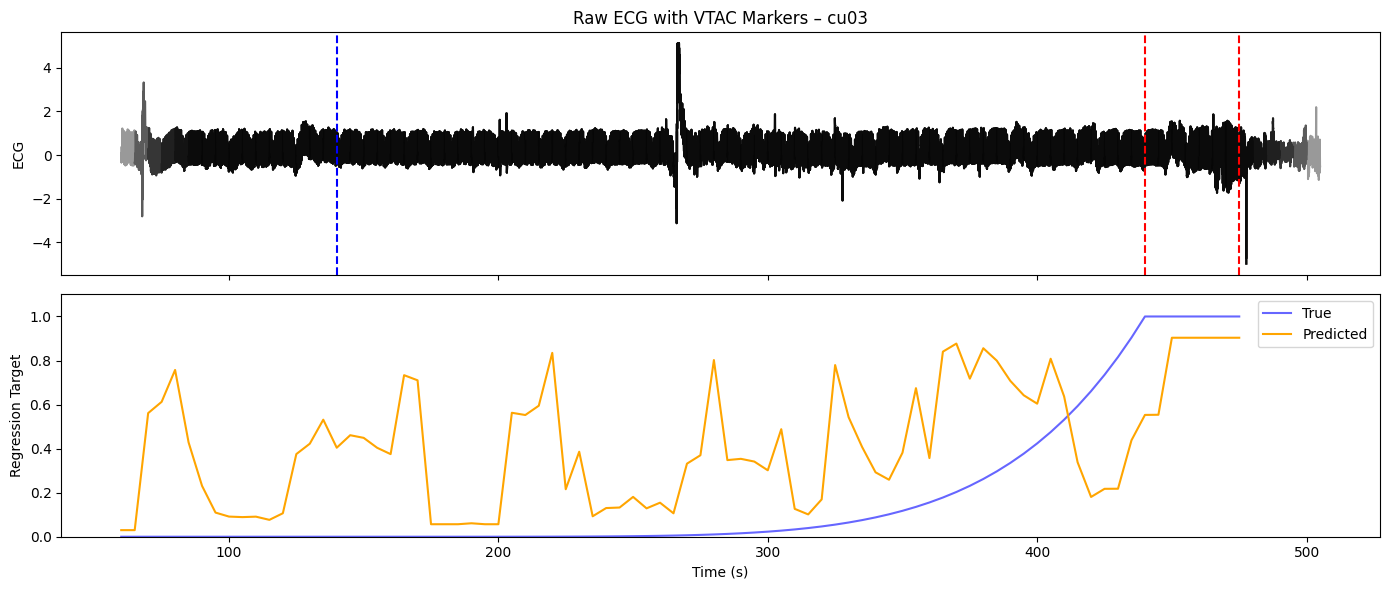

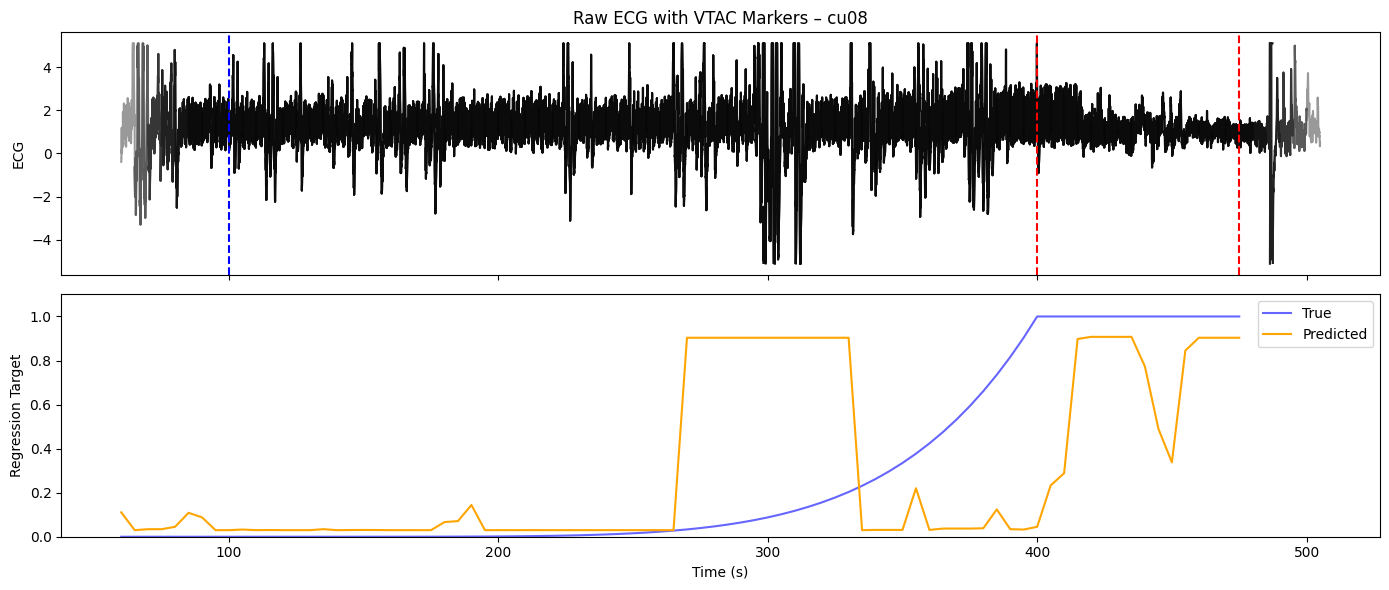

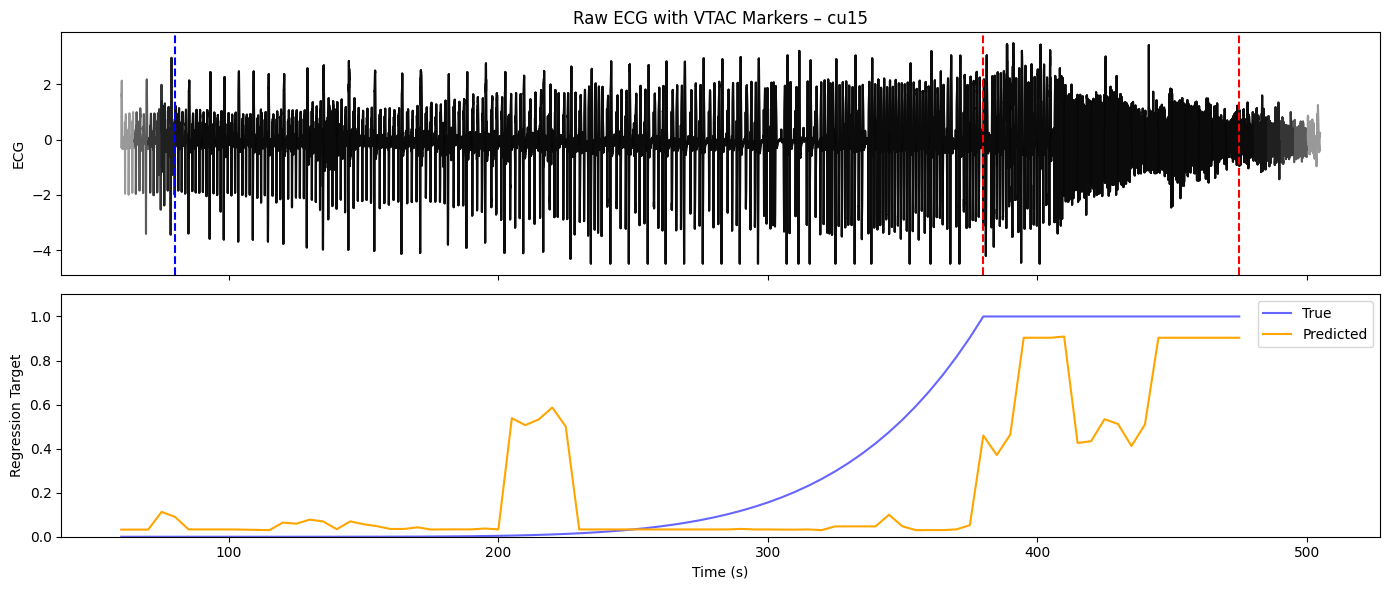

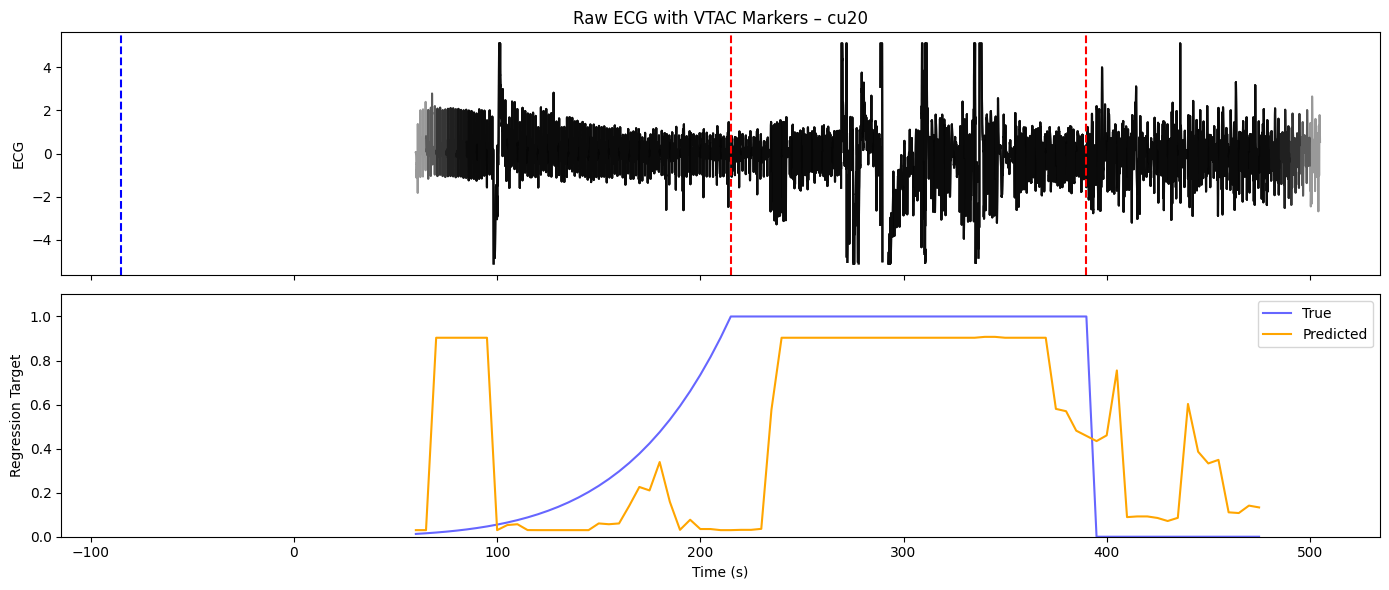

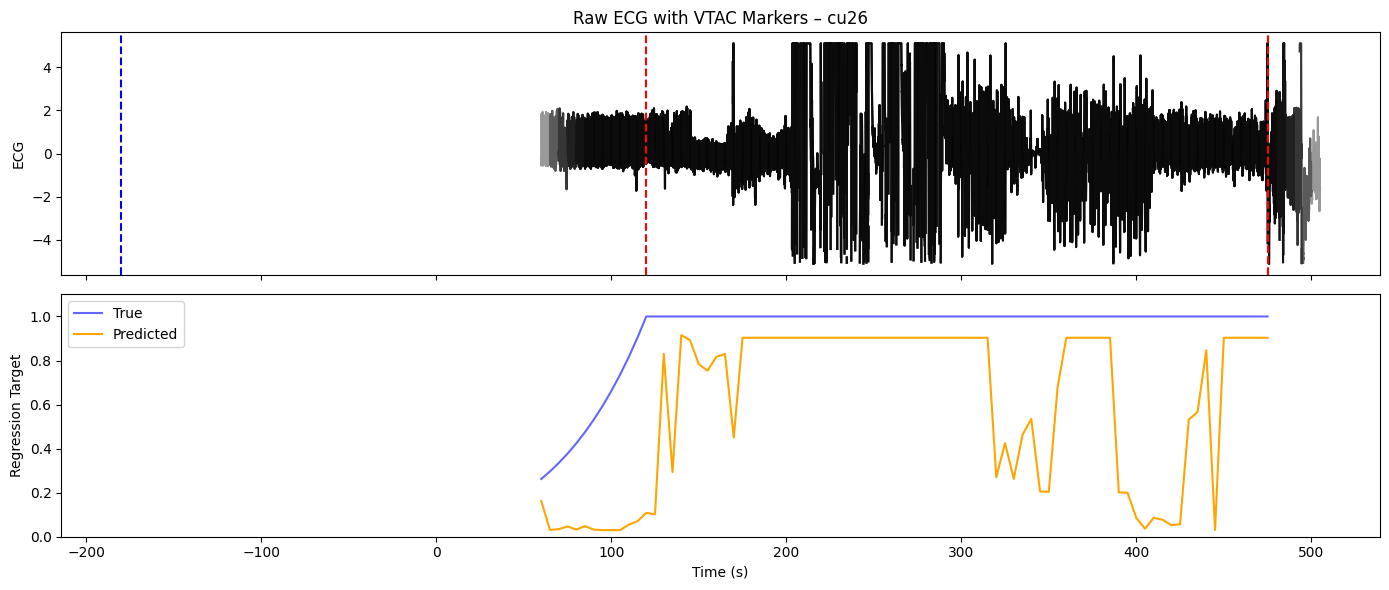

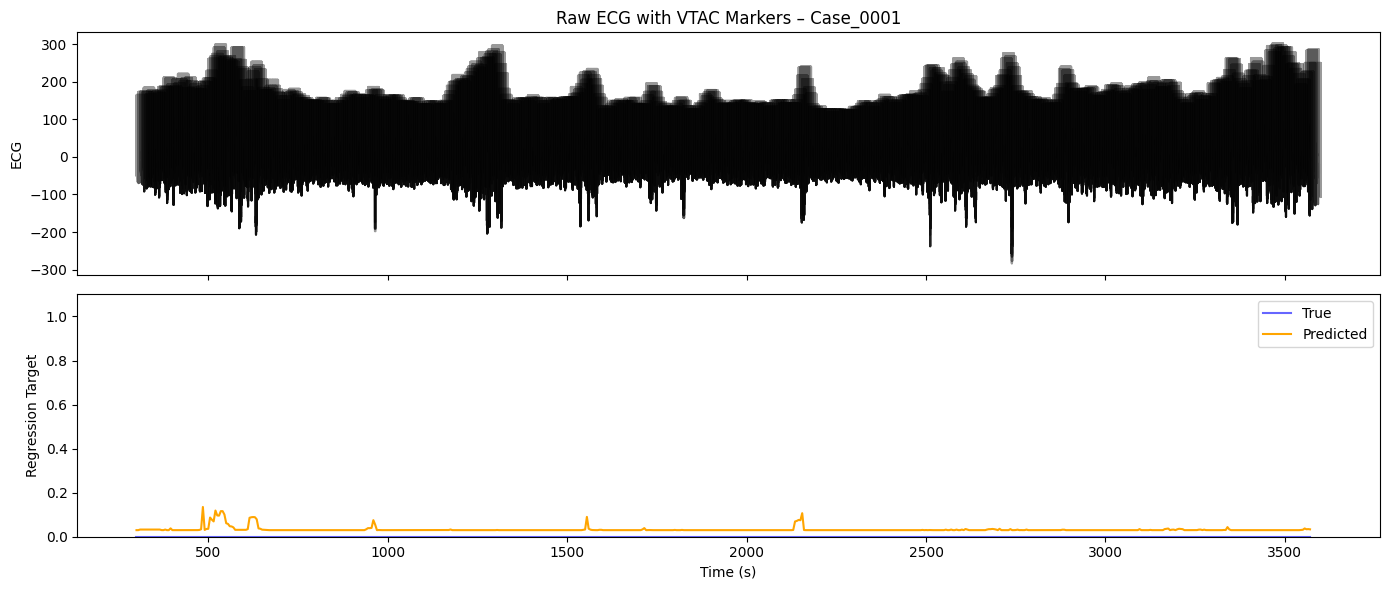

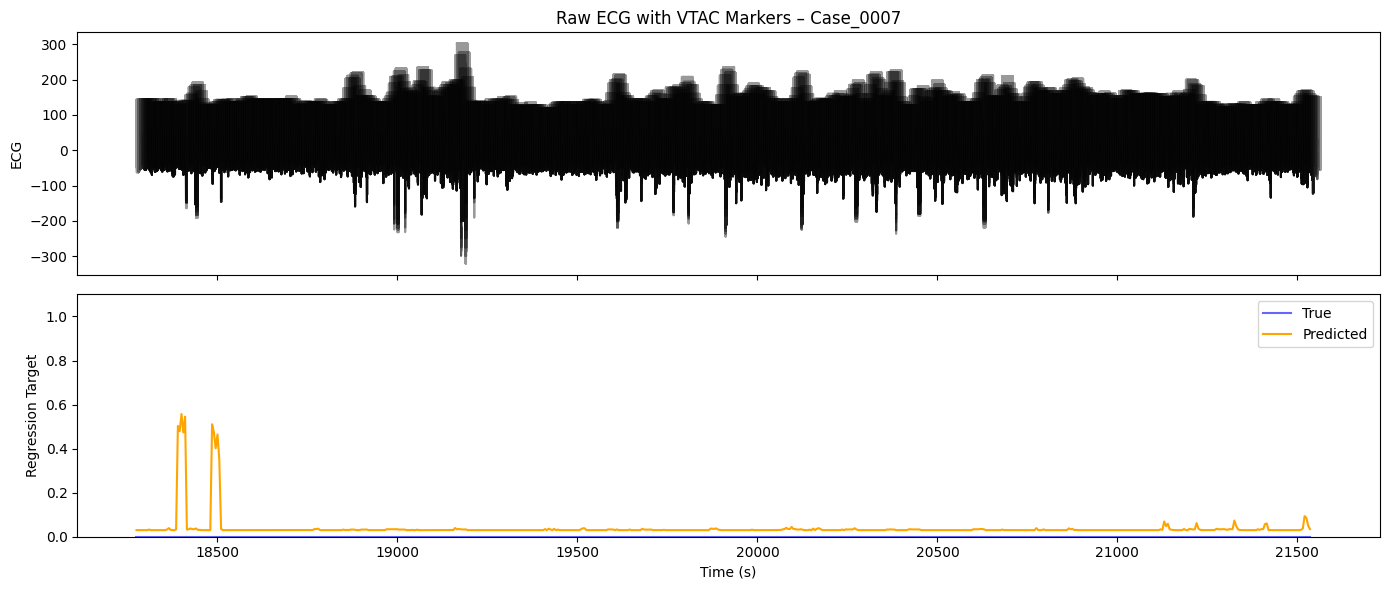

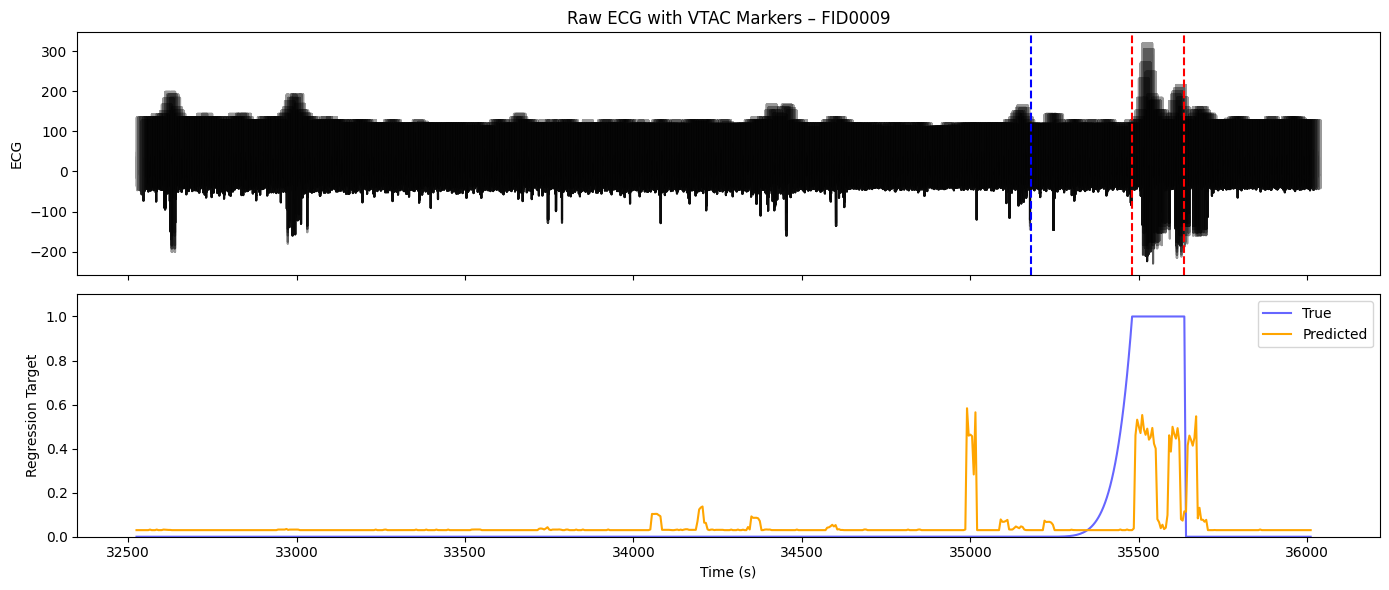


================ Fold 2 ================
RMSE (Train/Test): 0.1543 / 0.2294


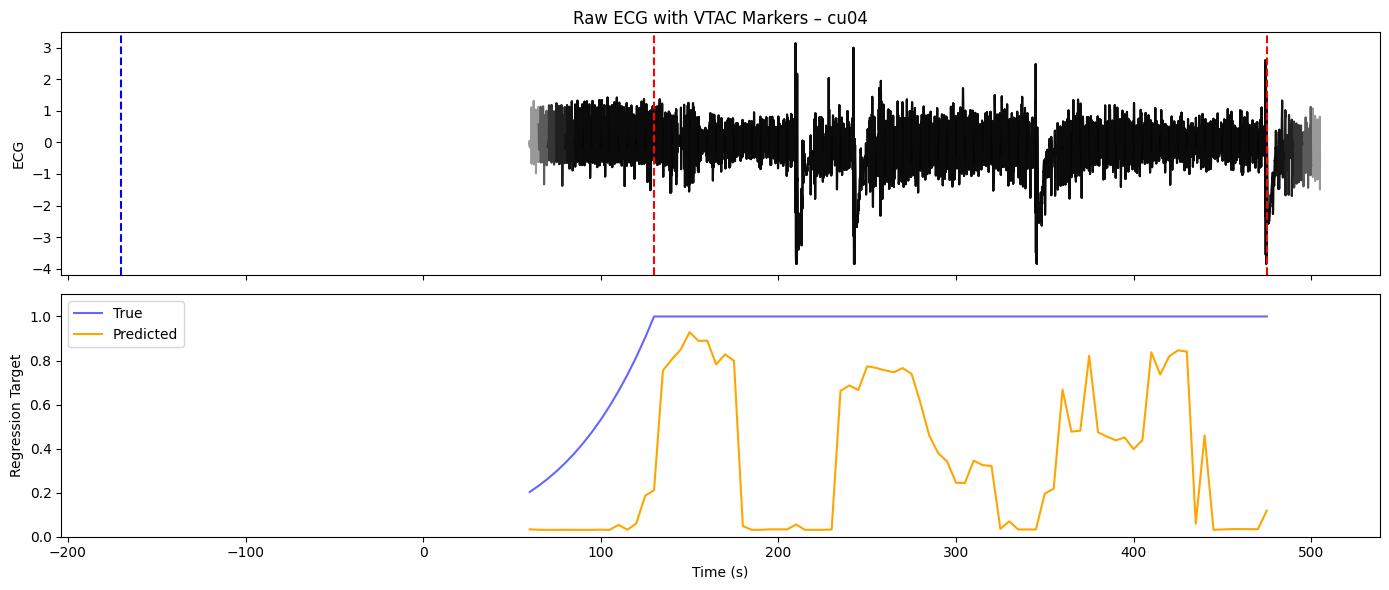

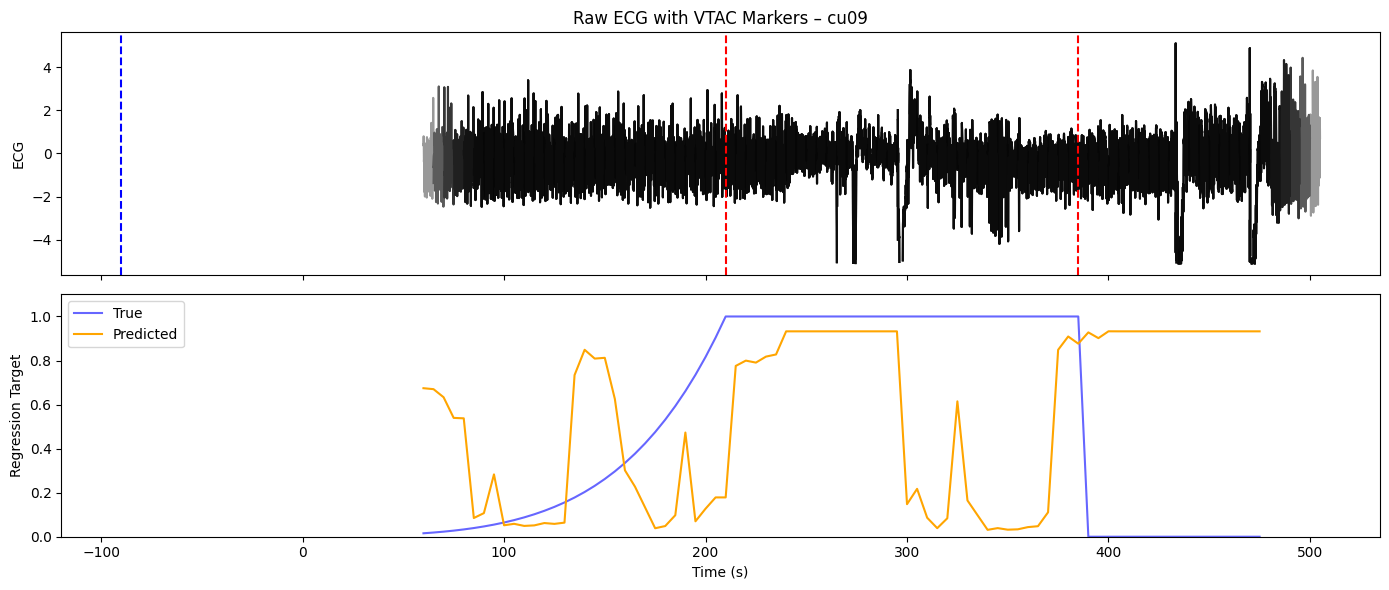

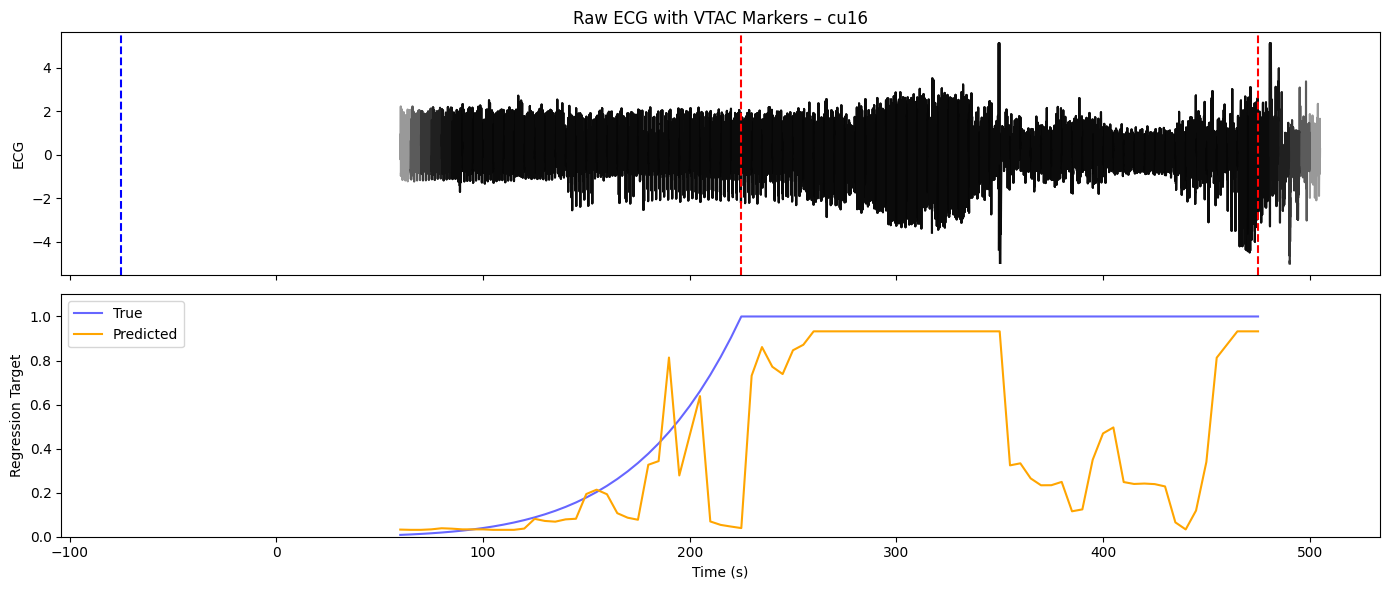

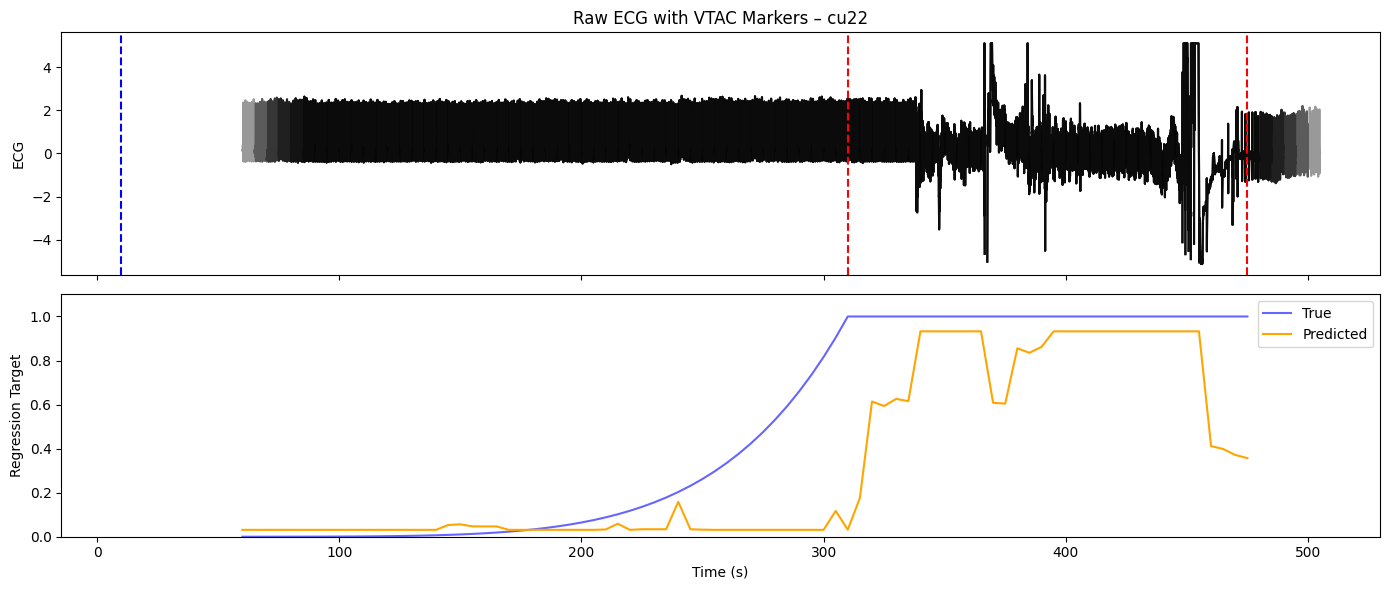

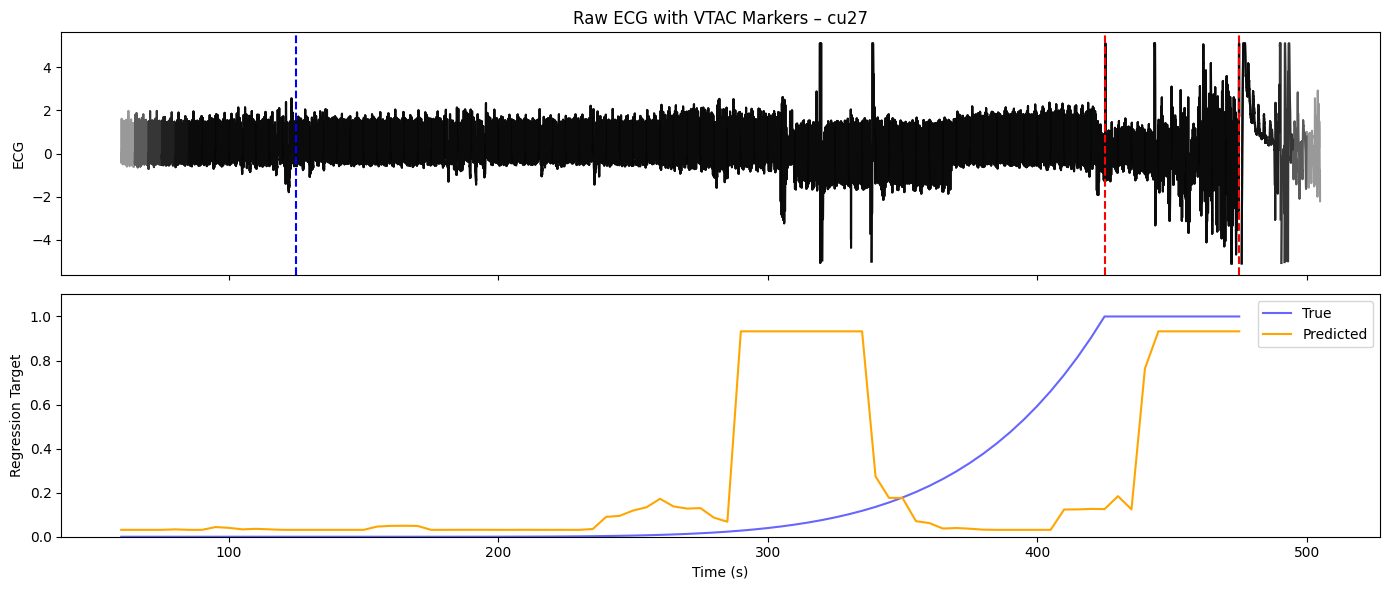

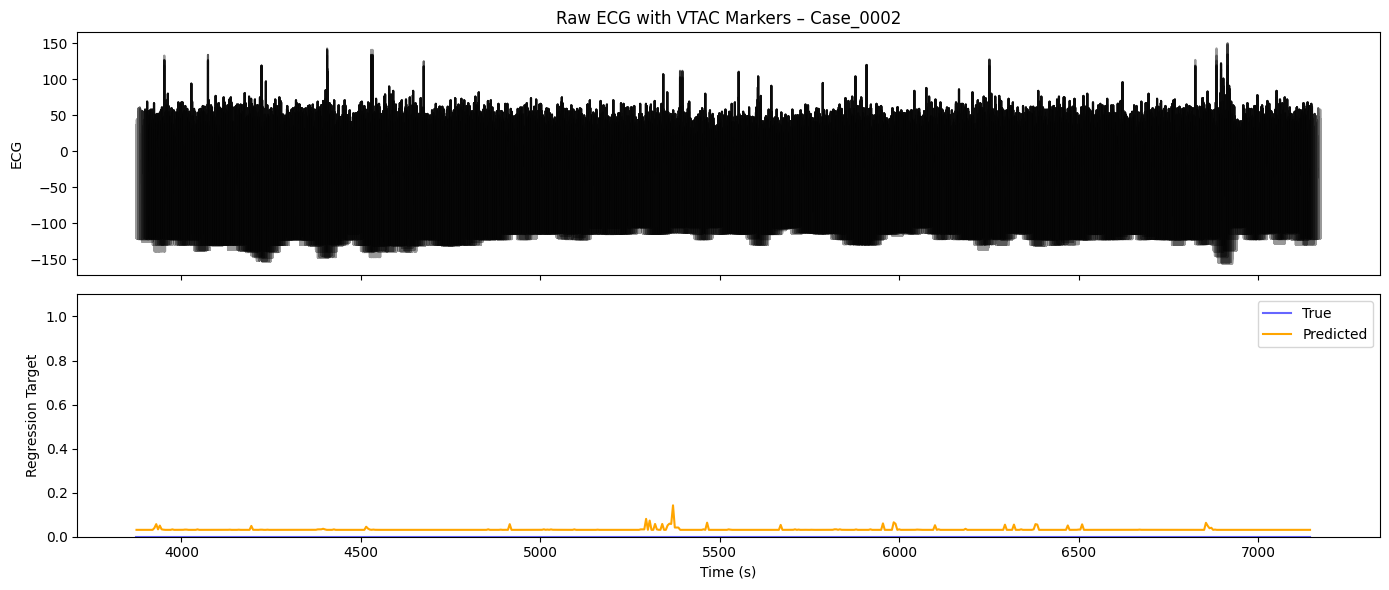

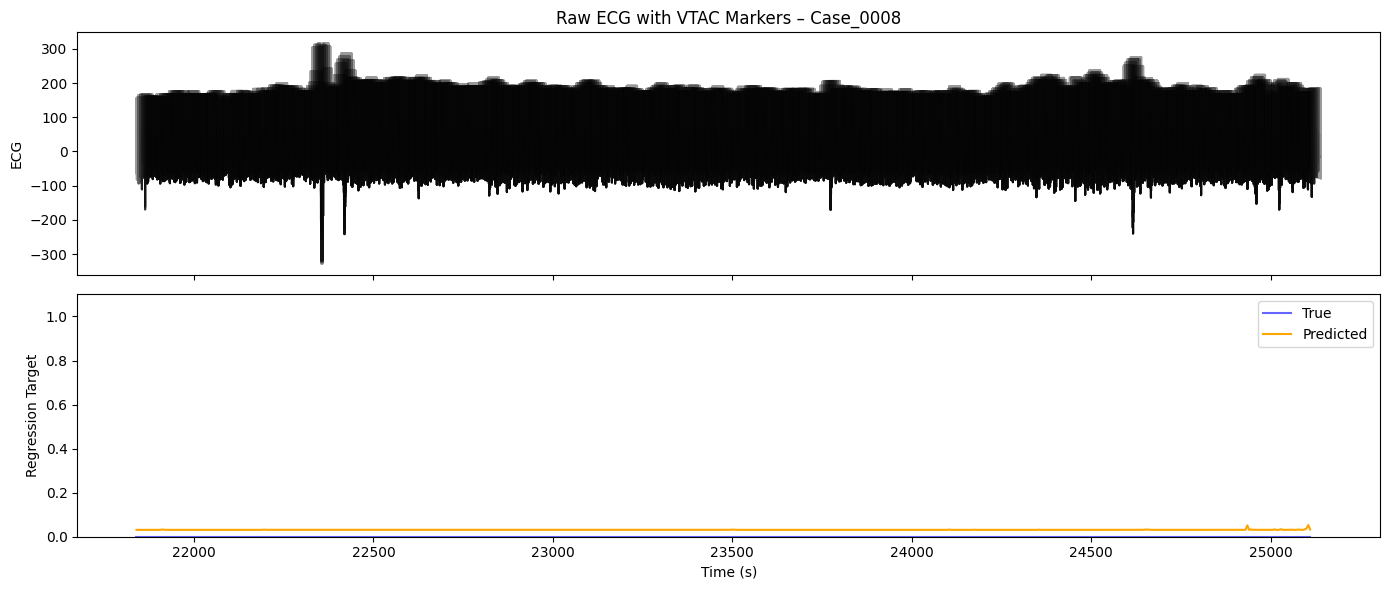

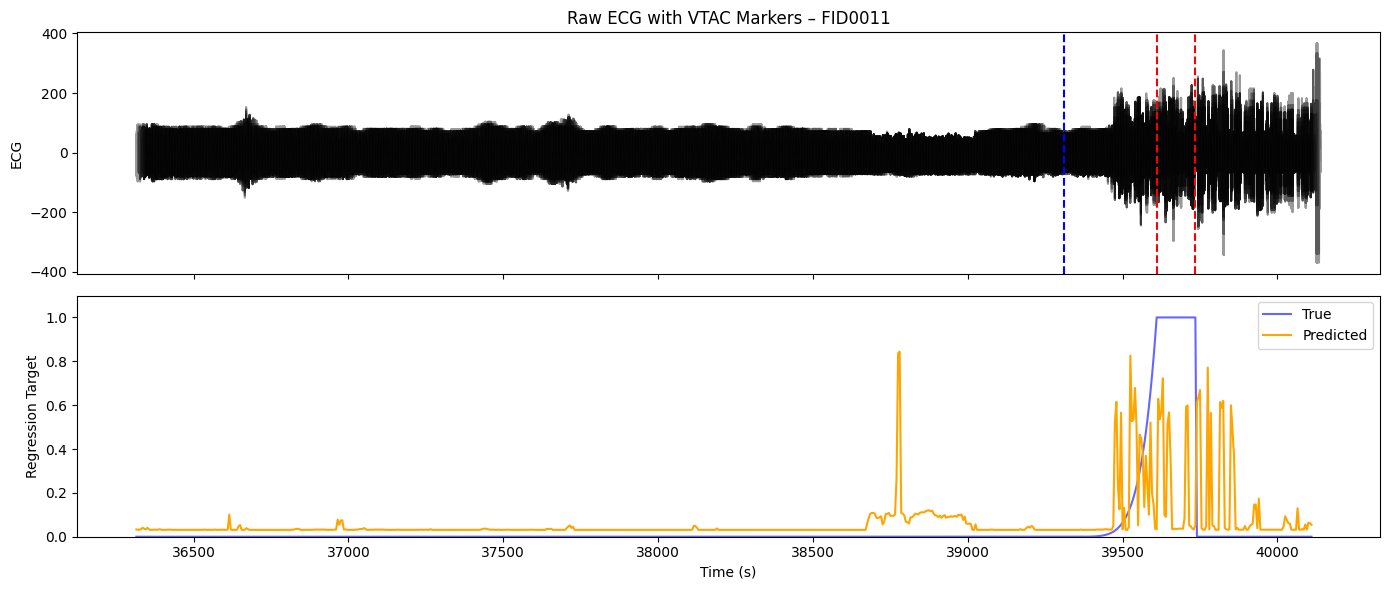


================ Fold 3 ================
RMSE (Train/Test): 0.1608 / 0.2038


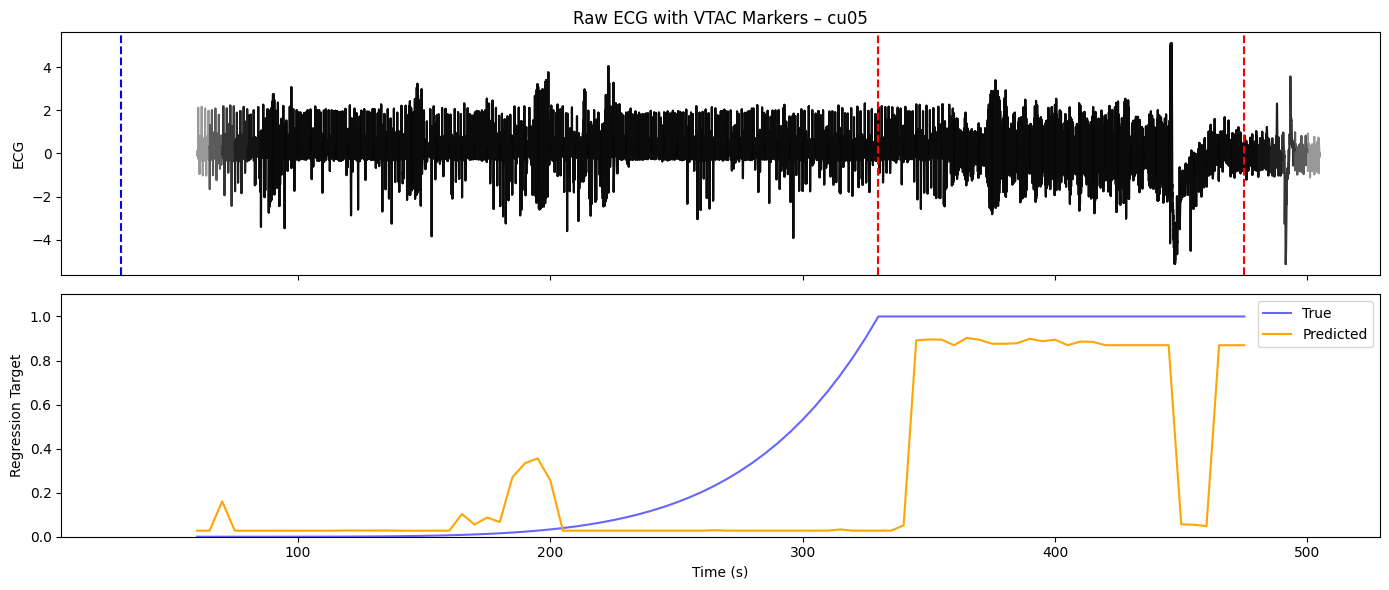

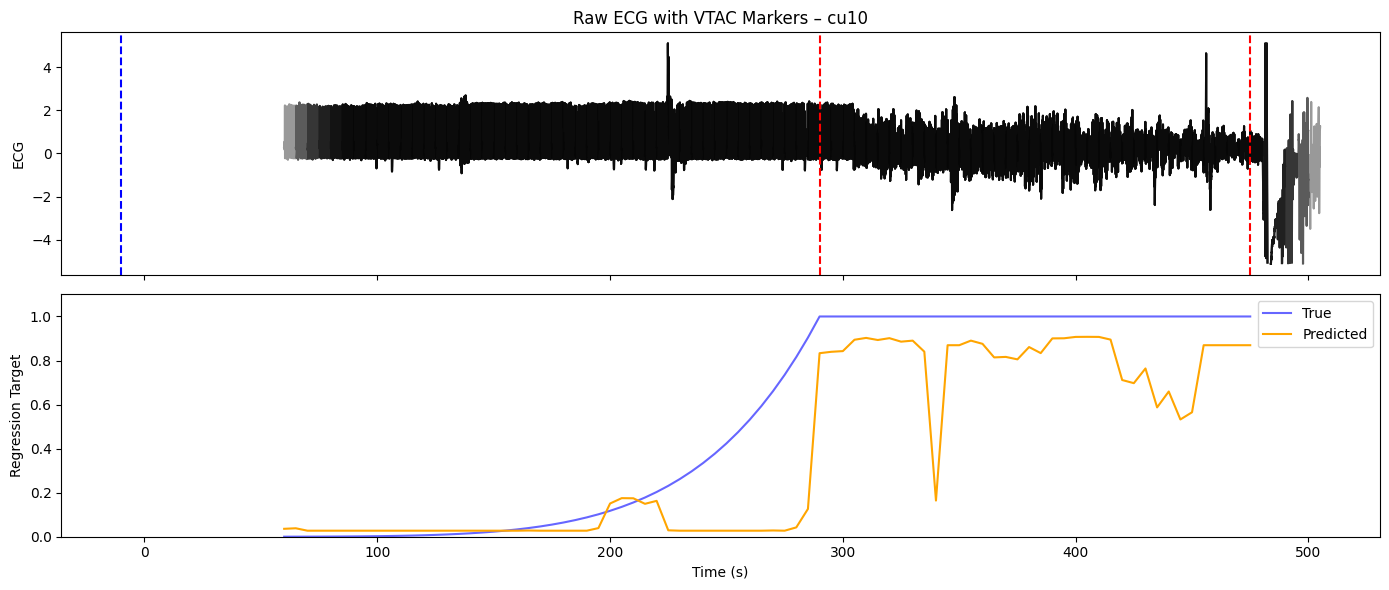

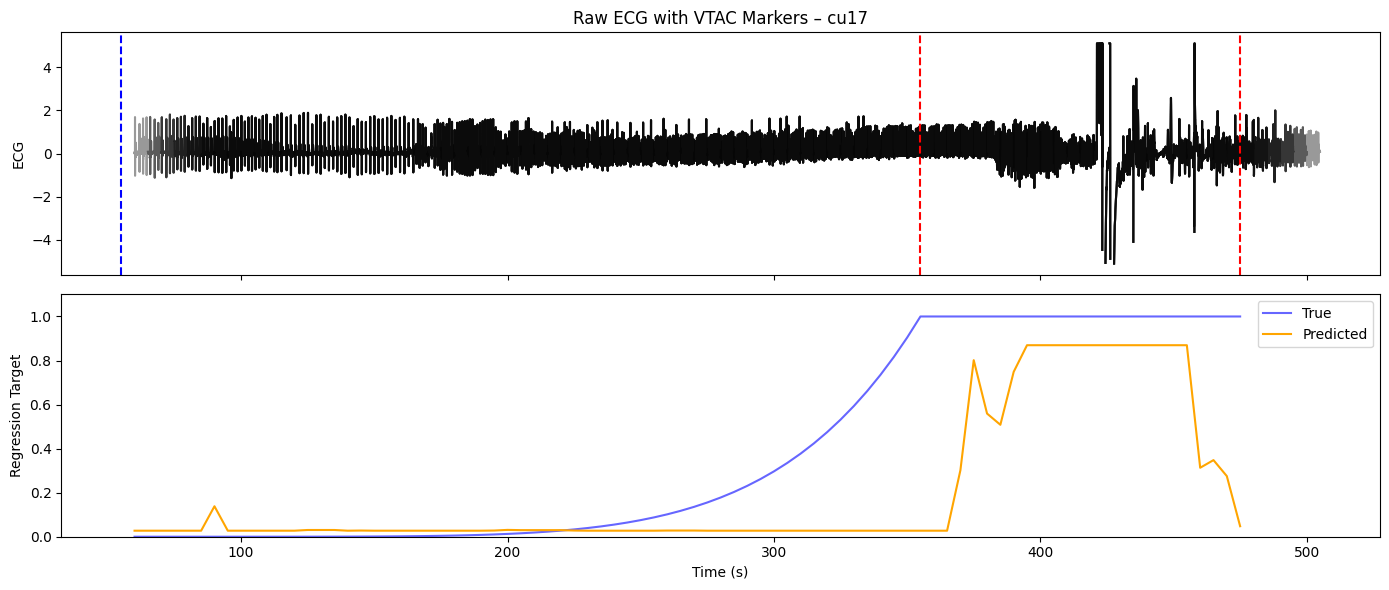

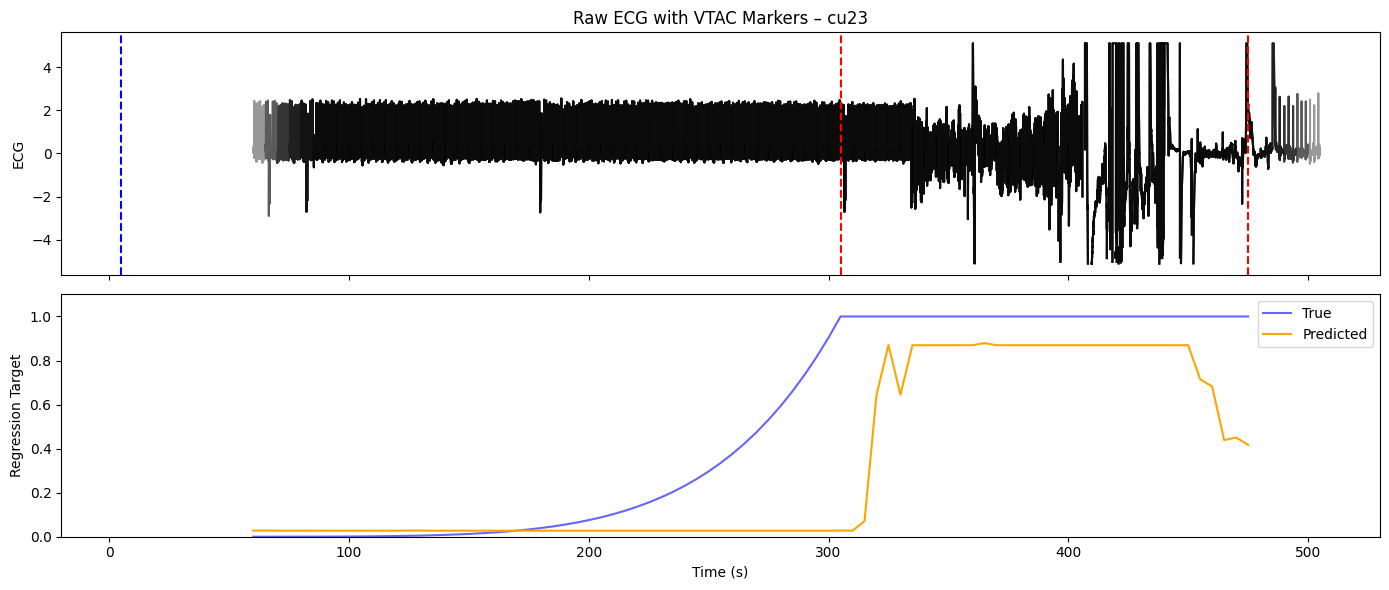

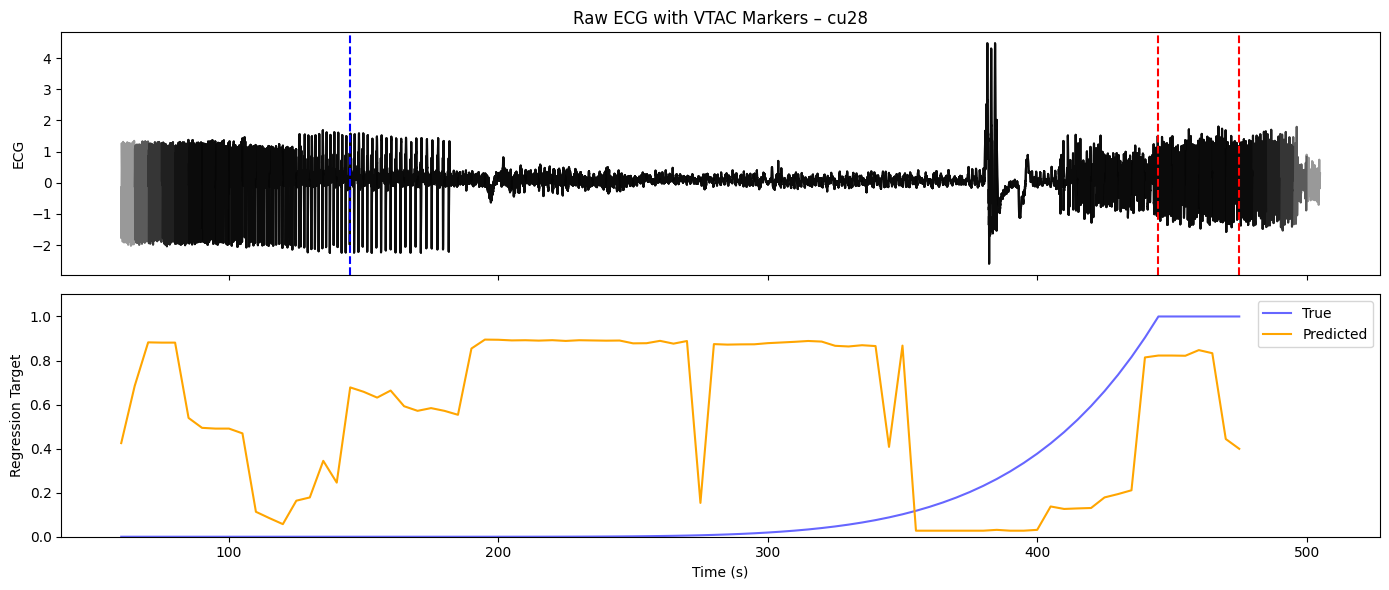

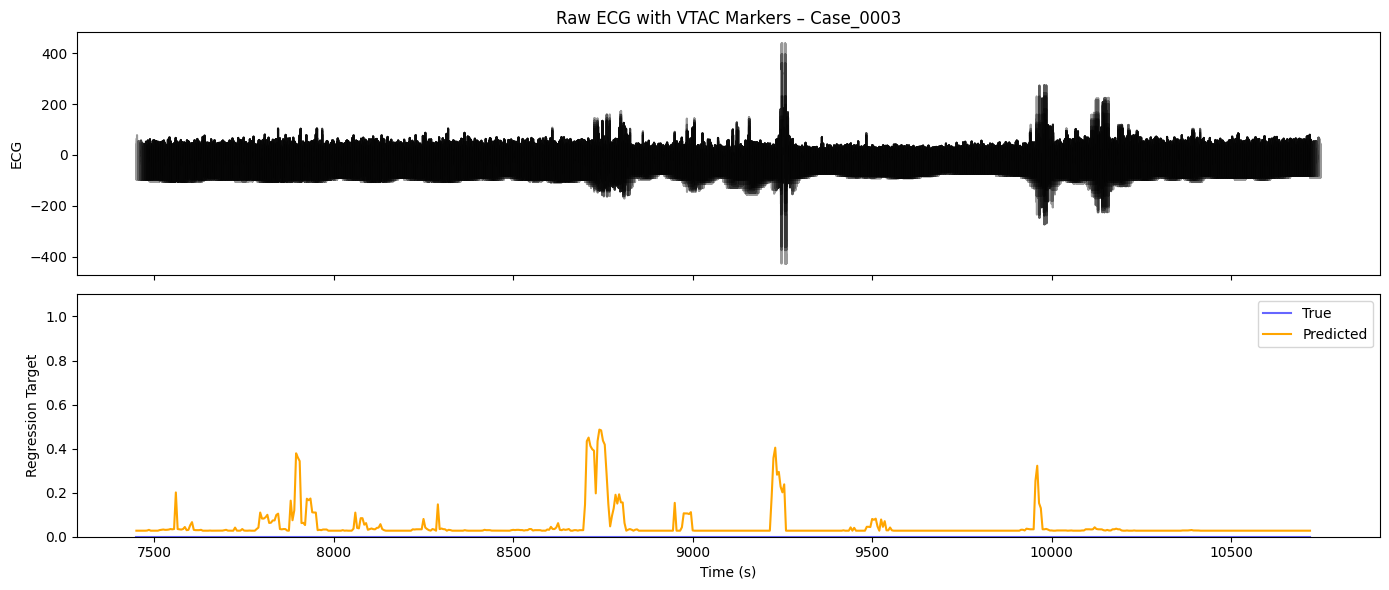

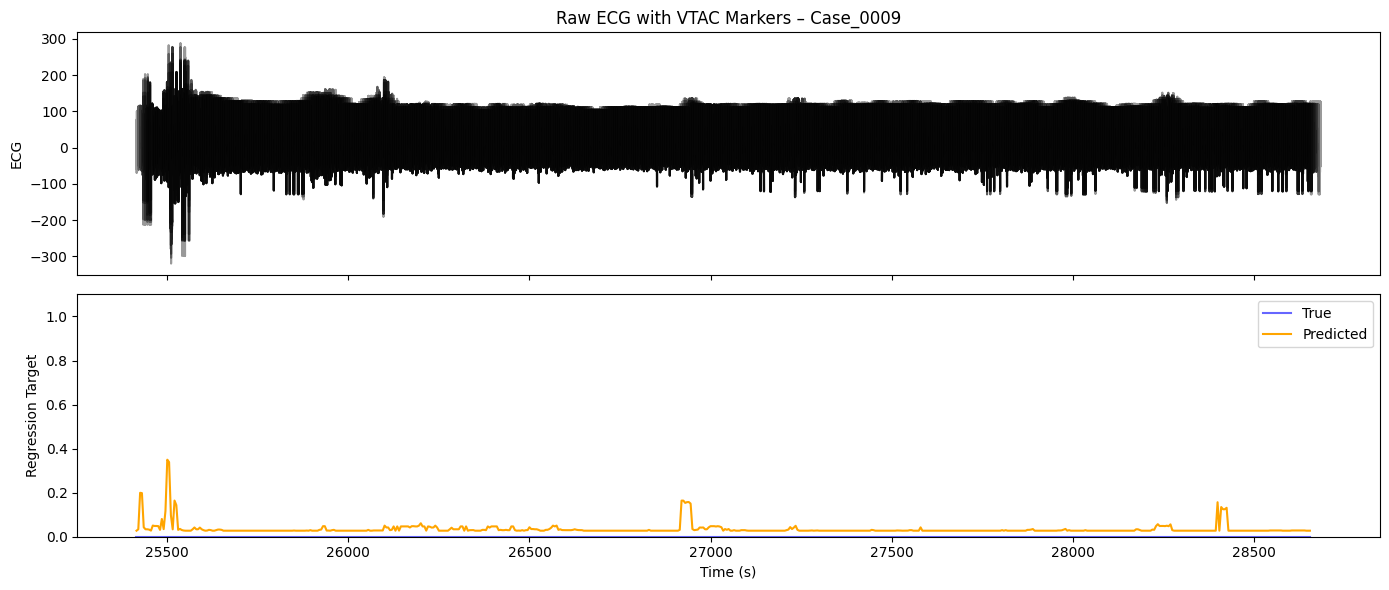

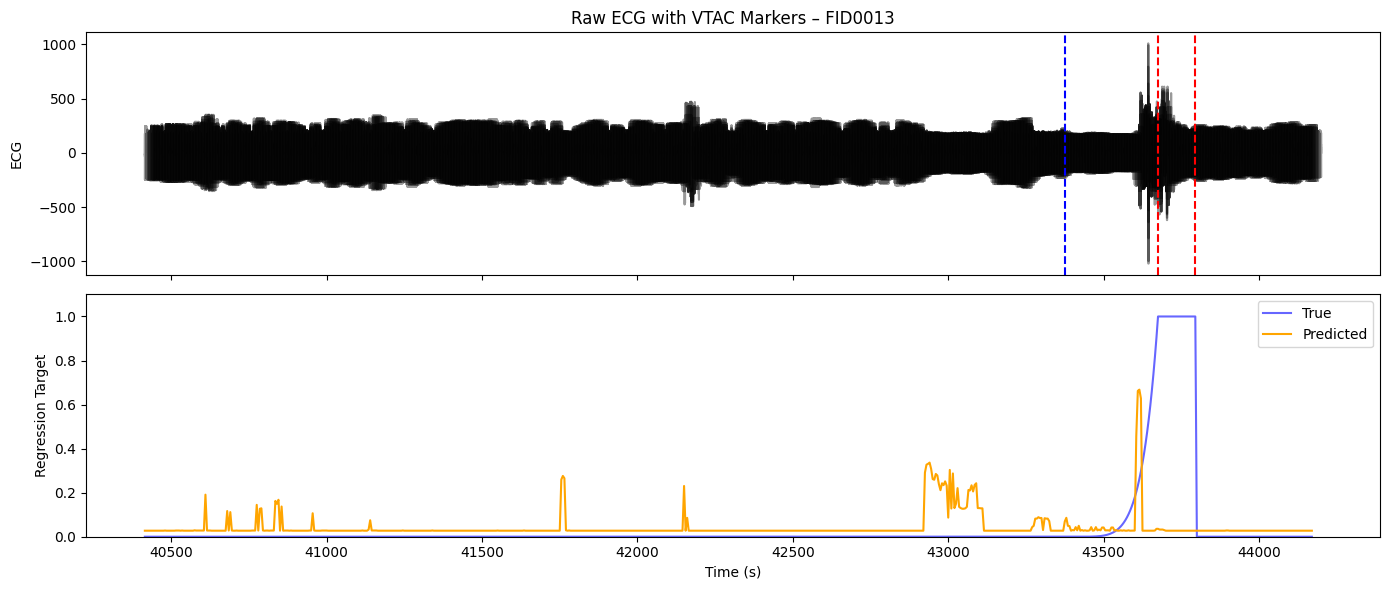


================ Fold 4 ================
RMSE (Train/Test): 0.1817 / 0.2434


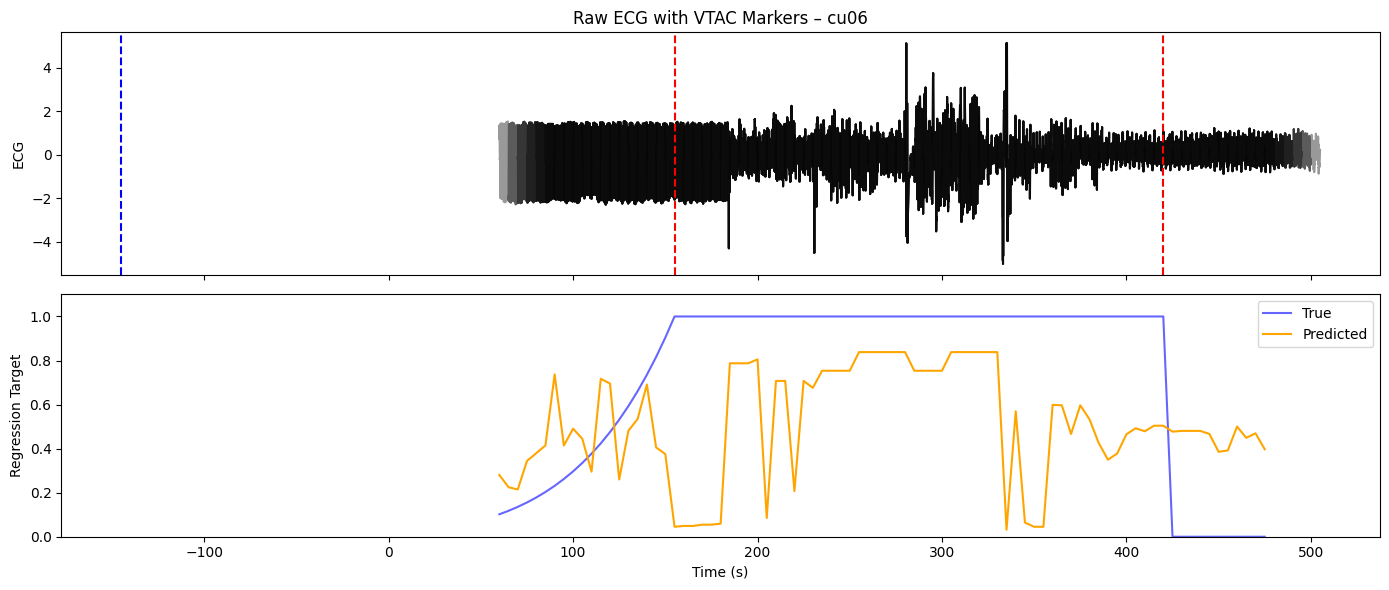

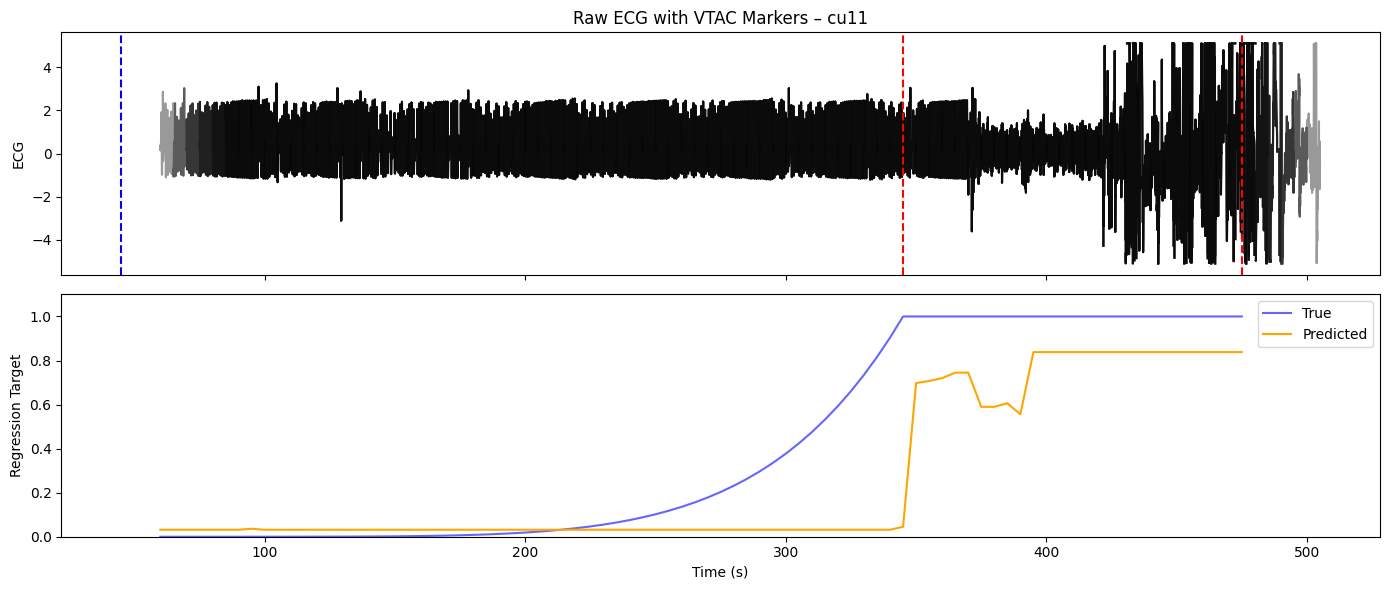

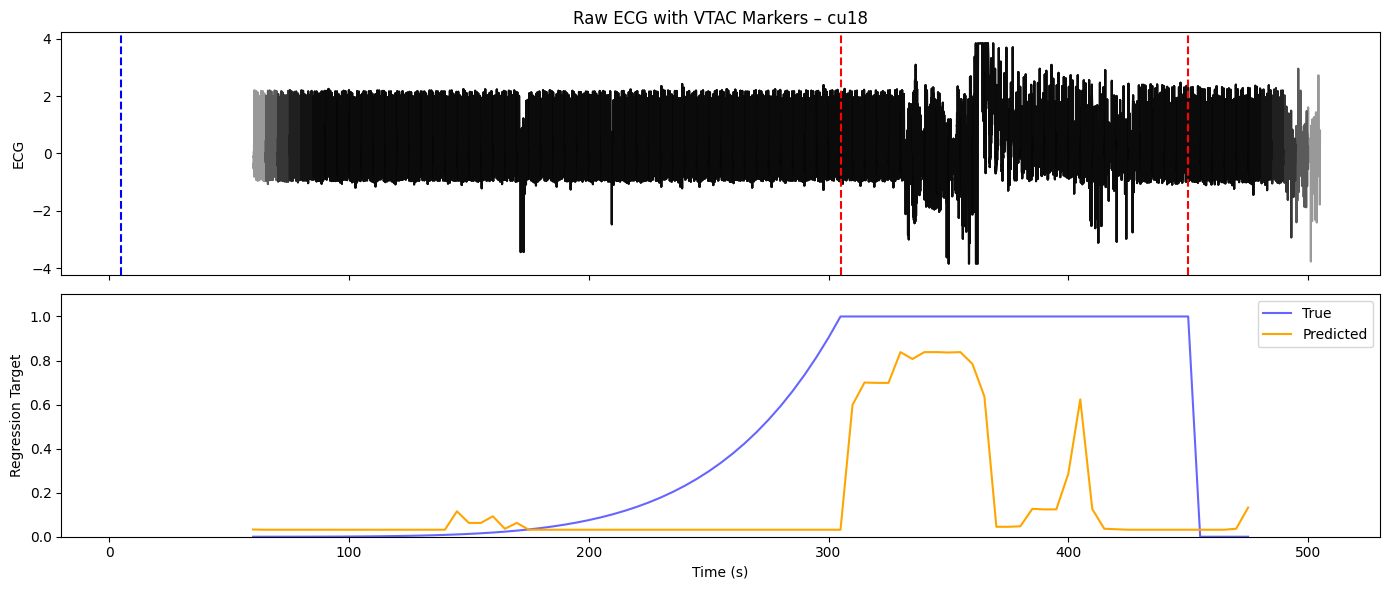

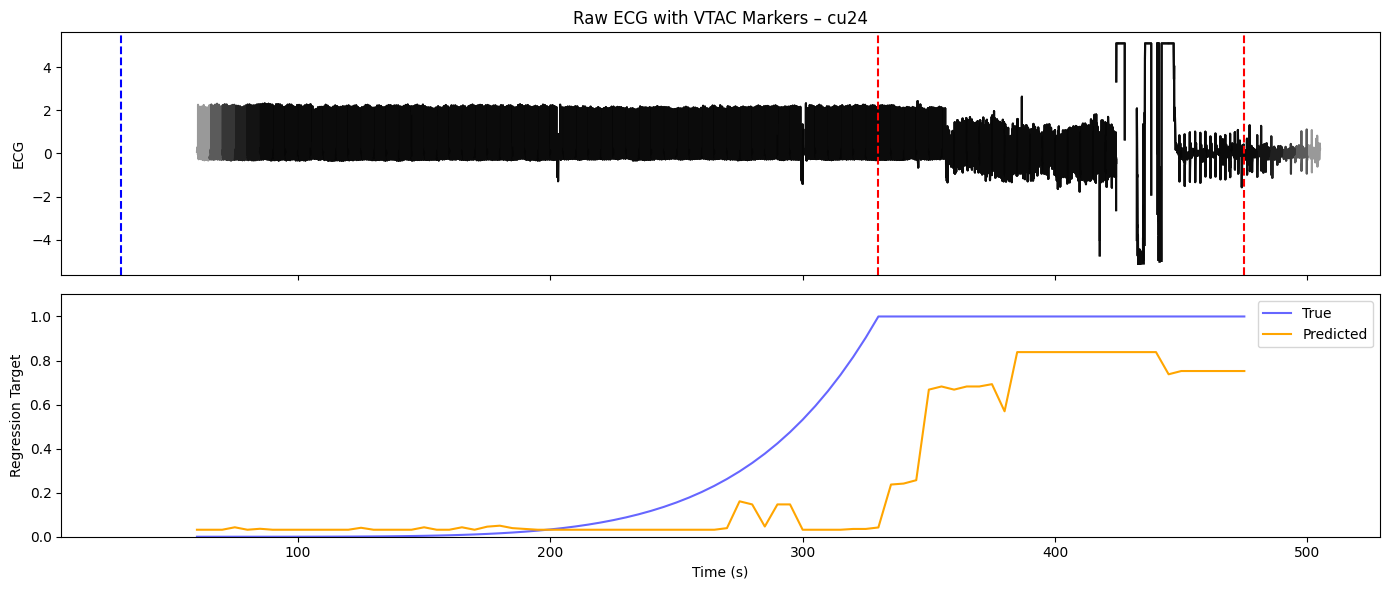

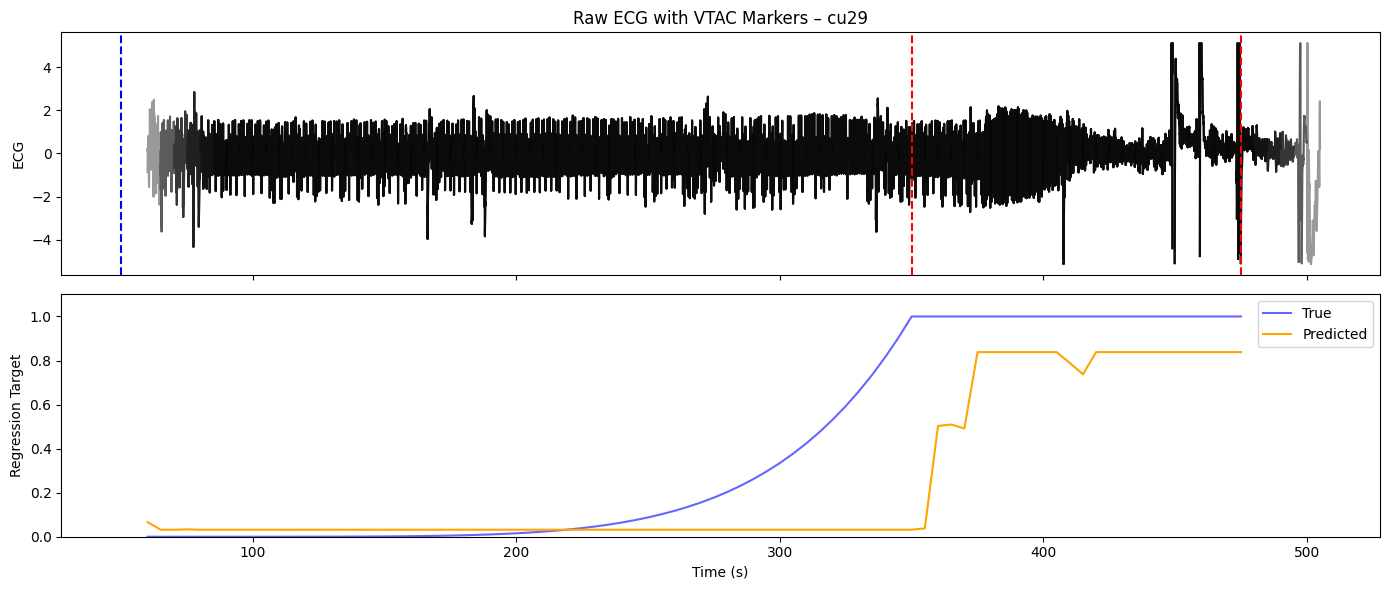

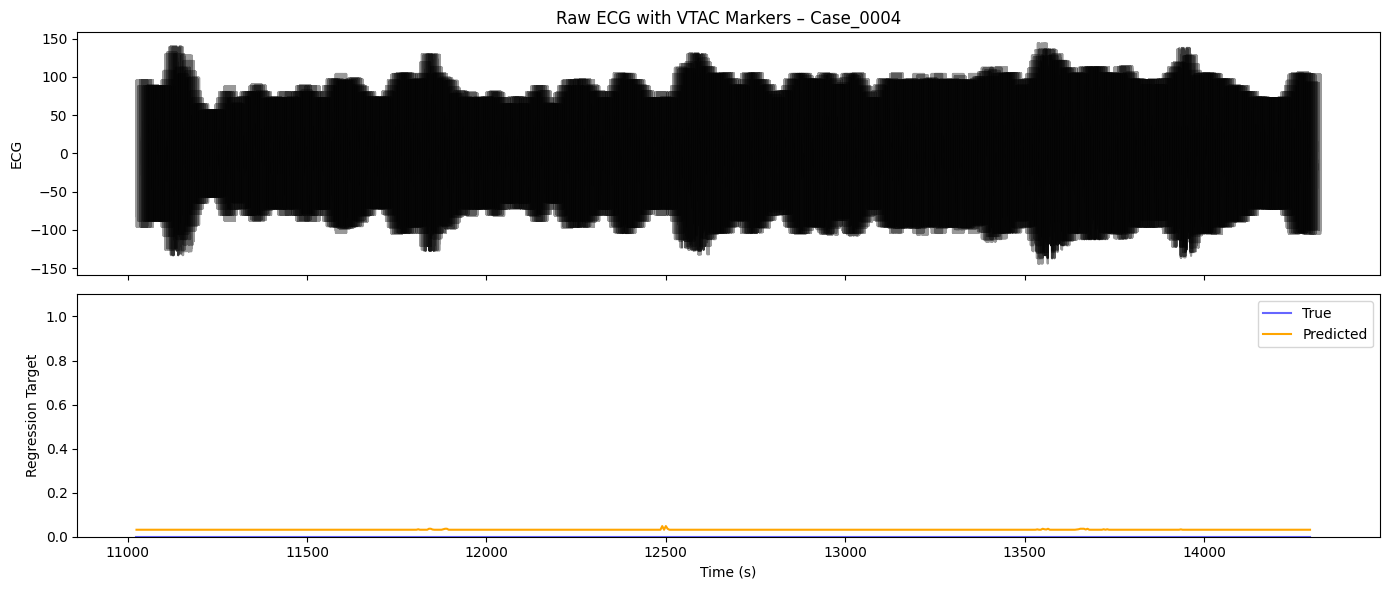

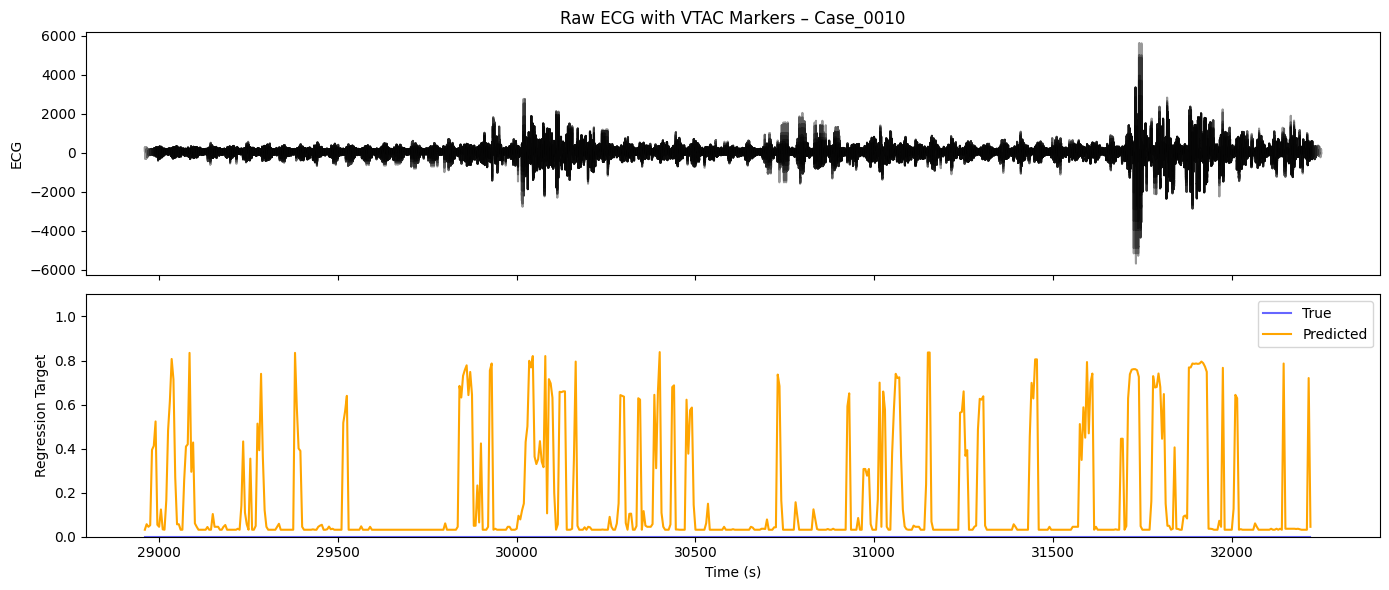


================ Fold 5 ================
RMSE (Train/Test): 0.1625 / 0.2002


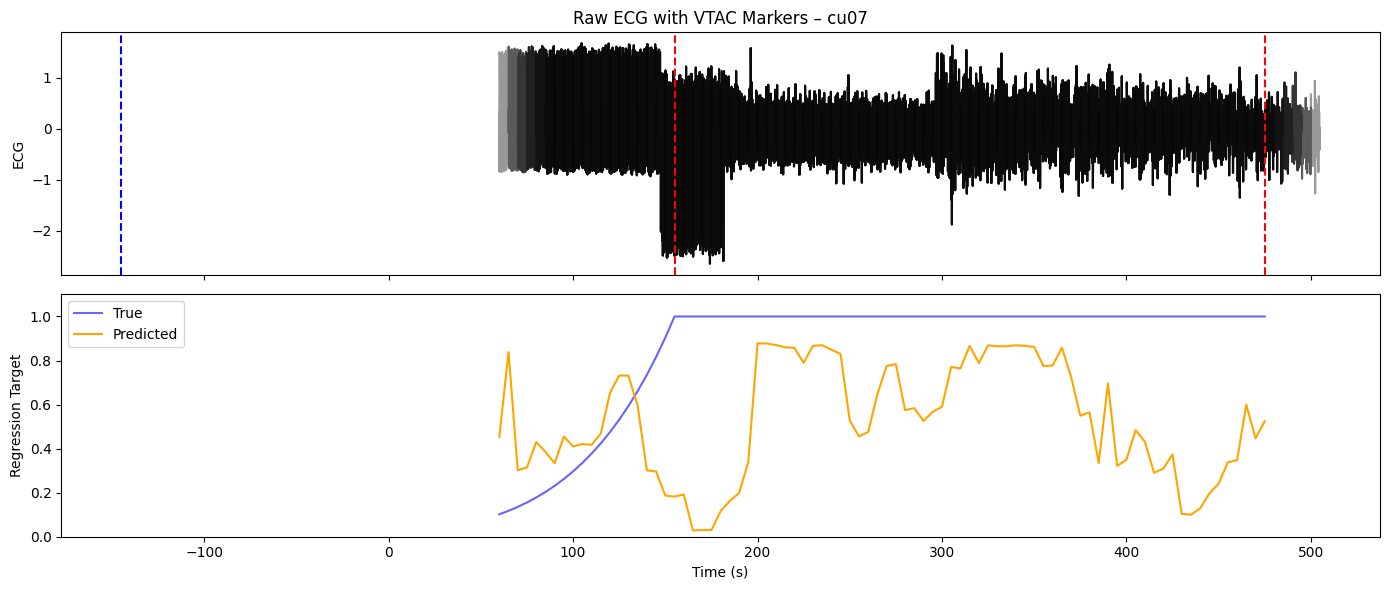

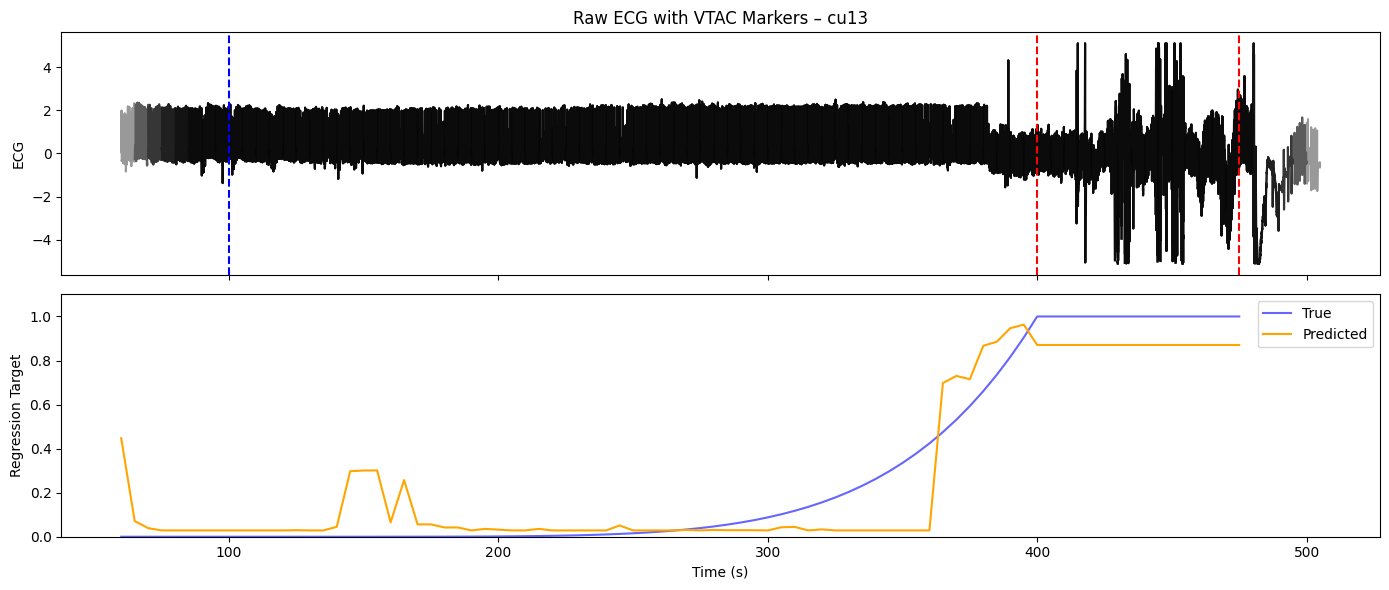

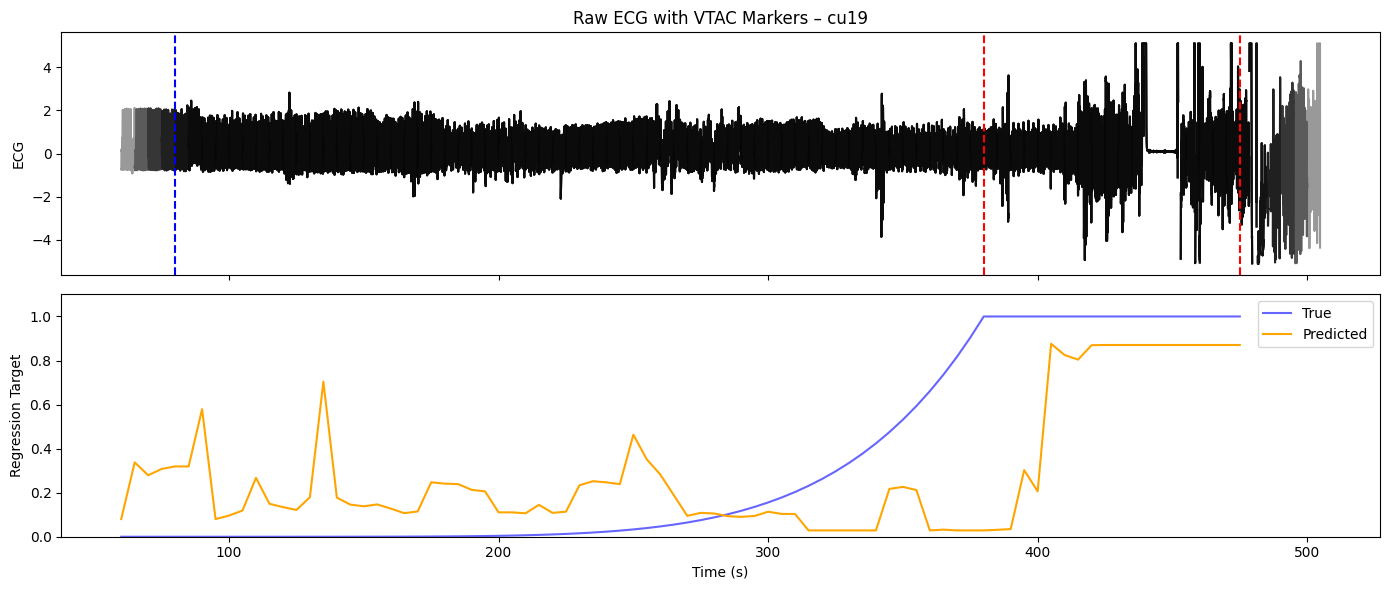

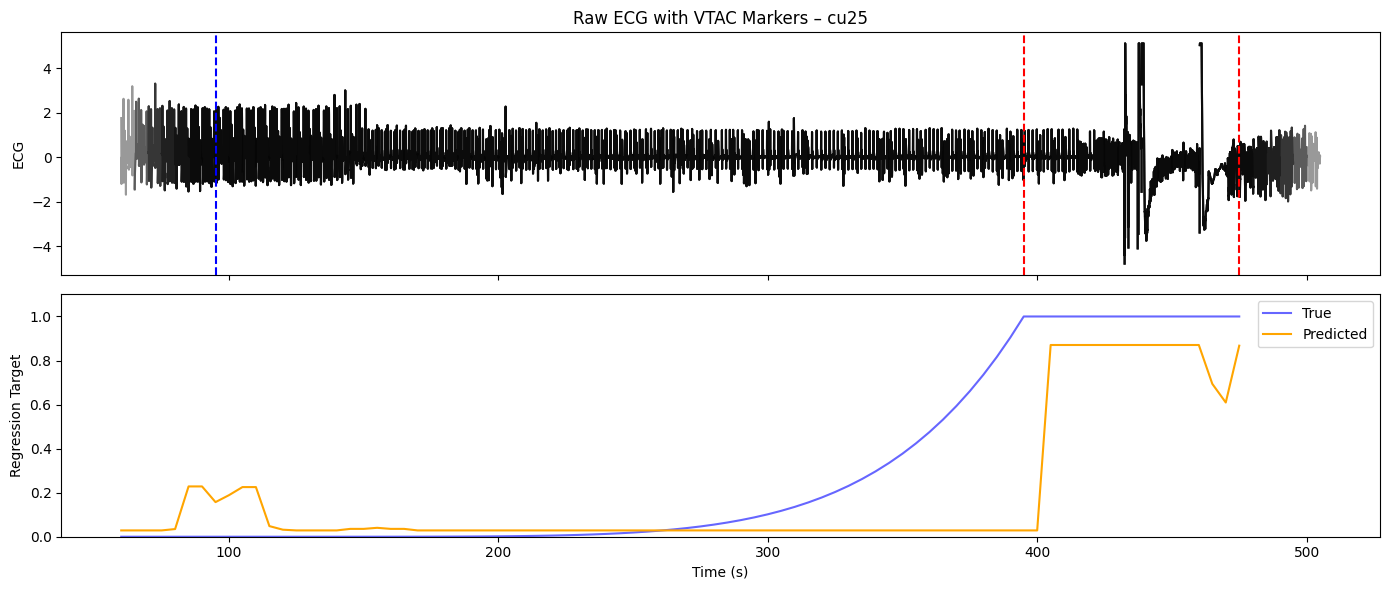

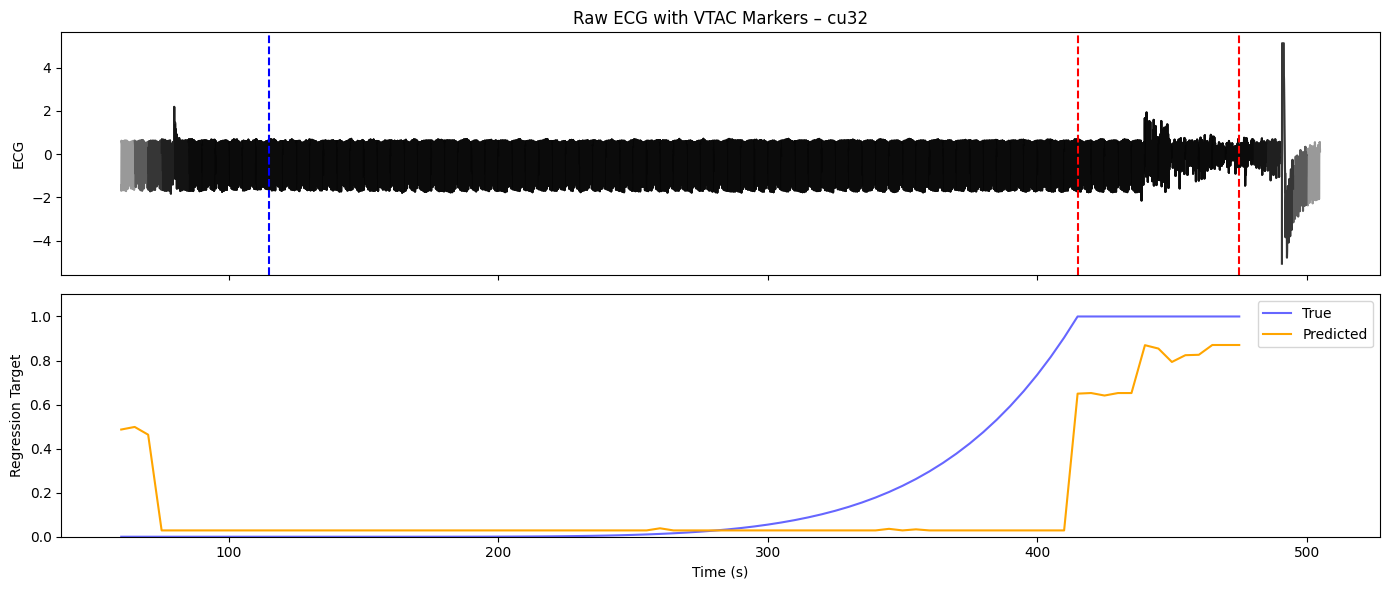

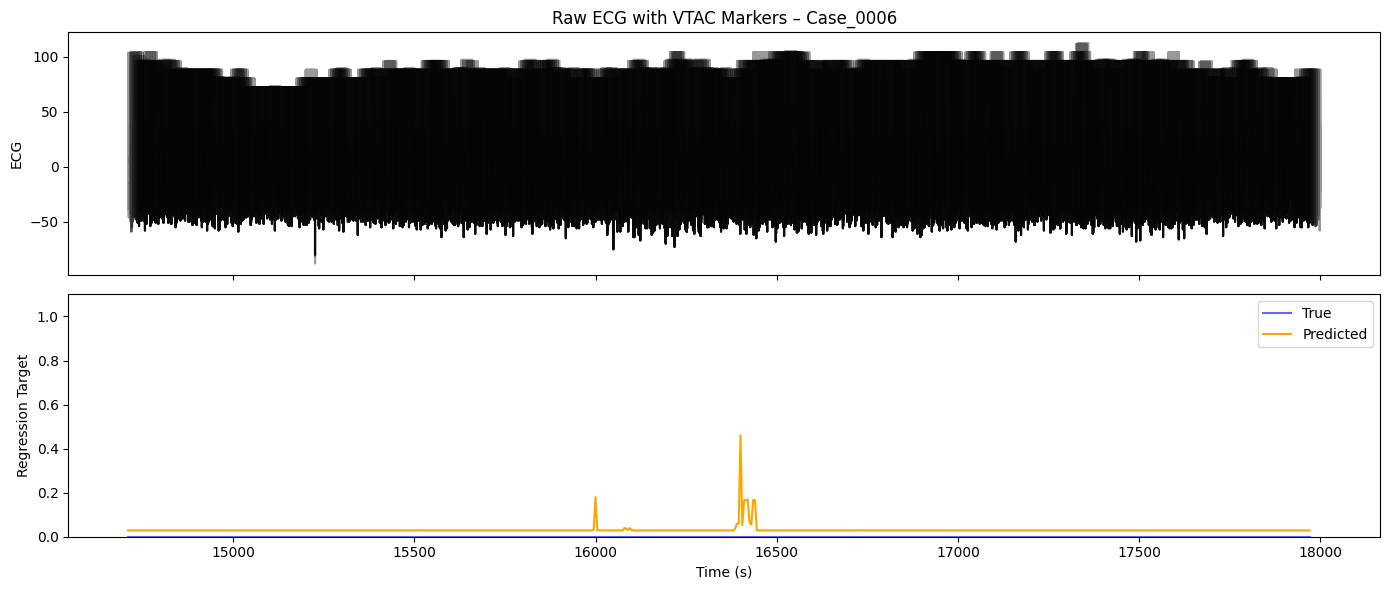

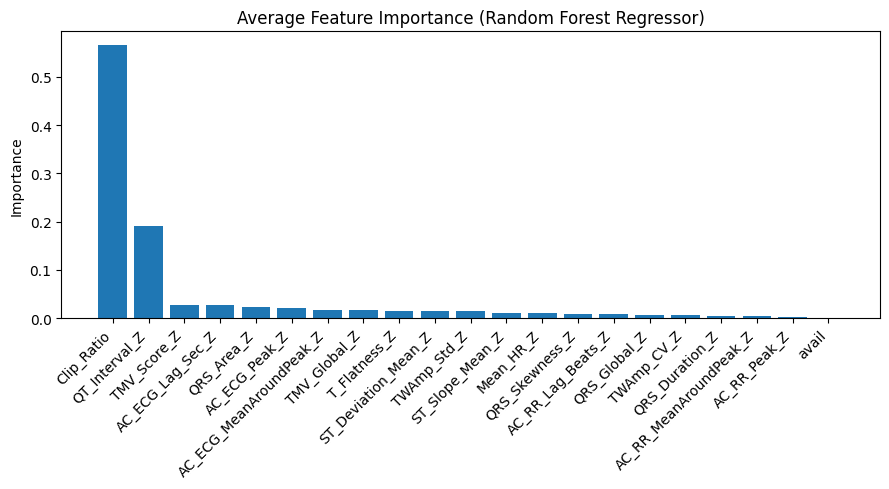


CROSS-FOLD PERFORMANCE
Train RMSE: 0.1636 ± 0.0094
Test  RMSE: 0.2137 ± 0.0195

POOLED PERFORMANCE
Pooled Train RMSE: 0.1642
Pooled Test  RMSE: 0.2144


In [13]:
# ===============================
# CONFIG
# ===============================
random_state = 42
n_folds = 5
sigmoid_seconds = 300

def get_sampling_rate(record_id):
    return 250 if str(record_id).lower().startswith("cu") else 240

# ===============================
# LOAD DATA
# ===============================
df = zscores_df.copy()
df = df[~df["Record"].isin(excluded_subjects)].copy()

# ===============================
# REGRESSION LABEL (300s ramp)
# ===============================
df["VTAC_Label_Regression"] = 0.0

for record_id in df["Record"].unique():

    fs = get_sampling_rate(record_id)
    sigmoid_samples = int(sigmoid_seconds * fs)

    subj_idx = df["Record"] == record_id
    subj_df = df.loc[subj_idx]

    vtac_rows = subj_df[subj_df["VTAC_Label"] == 1]
    if vtac_rows.empty:
        continue

    vtac_start = vtac_rows["Start"].min()
    start_min = max(0, vtac_start - sigmoid_samples)

    pre_mask = (
        subj_idx &
        (df["Start"] >= start_min) &
        (df["Start"] < vtac_start)
    )

    i = vtac_start - df.loc[pre_mask, "Start"].values
    t = -i / fs
    t_norm = (t + sigmoid_seconds) / sigmoid_seconds

    df.loc[pre_mask, "VTAC_Label_Regression"] = t_norm ** 6
    df.loc[subj_idx & (df["VTAC_Label"] == 1), "VTAC_Label_Regression"] = 1.0

# ===============================
# ML INPUTS
# ===============================
df = df.dropna(
    subset=features + ["VTAC_Label_Regression", "Record", "ECG_Raw", "Start"]
)

X = df[features].values
y = df["VTAC_Label_Regression"].values
groups = df["Record"].astype(str).values

# ===============================
# BUILD BALANCED SUBJECT FOLDS
# ===============================
subjects = np.unique(groups)

fid_subjects  = sorted([s for s in subjects if s.startswith("FID")])
case_subjects = sorted([s for s in subjects if s.startswith("Case_")])
cu_subjects   = sorted([s for s in subjects if s.lower().startswith("cu")])

fold_subjects = defaultdict(list)

for i, fid in enumerate(fid_subjects):
    fold_subjects[i % n_folds].append(fid)

for i, case in enumerate(case_subjects):
    fold_subjects[i % n_folds].append(case)

for i, cu in enumerate(cu_subjects):
    fold_subjects[i % n_folds].append(cu)

fold_indices = []

for fold_id in range(n_folds):

    test_subjects = fold_subjects[fold_id]
    test_mask = np.isin(groups, test_subjects)

    test_idx  = np.where(test_mask)[0]
    train_idx = np.where(~test_mask)[0]

    fold_indices.append((train_idx, test_idx))

    print(f"\nFold {fold_id + 1}")
    print(" Test subjects:", test_subjects)
    print("  FID :", [s for s in test_subjects if s.startswith("FID")])
    print("  Case:", [s for s in test_subjects if s.startswith("Case_")])
    print("  CU  :", [s for s in test_subjects if s.lower().startswith("cu")])

# ===============================
# METRIC CONTAINERS
# ===============================
rmse_train_folds = []
rmse_test_folds  = []

all_preds_train, all_true_train = [], []
all_preds_test,  all_true_test  = [], []

feature_importances = np.zeros(len(features))

# ===============================
# TRAINING LOOP
# ===============================
for fold_num, (train_idx, test_idx) in enumerate(fold_indices, start=1):

    print(f"\n================ Fold {fold_num} ================")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    test_records = df.iloc[test_idx]["Record"].unique()

    # -------------------------------
    # Randomized Search (RF Regressor)
    # -------------------------------
    param_dist = {
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [3, 5, 7],
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 5),
    }

    base_model = RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    )

    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist,
        n_iter=50,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=random_state,
        n_jobs=-1,
    )

    search.fit(X_train, y_train)
    model = search.best_estimator_

    # -------------------------------
    # Predictions
    # -------------------------------
    preds_train = medfilt(model.predict(X_train), kernel_size=5)
    preds_test  = medfilt(model.predict(X_test),  kernel_size=5)

    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test, preds_test))

    print(f"RMSE (Train/Test): {rmse_train:.4f} / {rmse_test:.4f}")

    rmse_train_folds.append(rmse_train)
    rmse_test_folds.append(rmse_test)

    all_preds_train.extend(preds_train)
    all_true_train.extend(y_train)

    all_preds_test.extend(preds_test)
    all_true_test.extend(y_test)

    feature_importances += model.feature_importances_

    # ===============================
    # SUBJECT-LEVEL PLOTS (UNCHANGED)
    # ===============================
    for subject_id in test_records:

        sr = get_sampling_rate(subject_id)

        subject_df = df.iloc[test_idx]
        subject_df = subject_df[subject_df["Record"] == subject_id]
        subject_df = subject_df.sort_values("Start")

        X_sub = subject_df[features].values
        subject_df["Prediction"] = model.predict(X_sub)

        fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

        for _, row in subject_df.iterrows():
            ecg = row["ECG_Raw"]
            if isinstance(ecg, list) and len(ecg) > 0:
                t = np.linspace(
                    row["Start"] / sr,
                    (row["Start"] + 30 * sr) / sr,
                    len(ecg),
                )
                axs[0].plot(t, ecg, color="black", alpha=0.4)

        vtac_rows = subject_df[subject_df["VTAC_Label"] == 1]
        if not vtac_rows.empty:
            vtac_start = vtac_rows["Start"].min() / sr
            vtac_end   = vtac_rows["Start"].max() / sr
            axs[0].axvline(vtac_start, color="red", linestyle="--")
            axs[0].axvline(vtac_end,   color="red", linestyle="--")
            axs[0].axvline(vtac_start - sigmoid_seconds, color="blue", linestyle="--")

        axs[0].set_title(f"Raw ECG with VTAC Markers – {subject_id}")
        axs[0].set_ylabel("ECG")

        axs[1].plot(
            subject_df["Start"] / sr,
            subject_df["VTAC_Label_Regression"],
            label="True",
            color="blue",
            alpha=0.6,
        )
        axs[1].plot(
            subject_df["Start"] / sr,
            subject_df["Prediction"],
            label="Predicted",
            color="orange",
        )

        axs[1].legend()
        axs[1].set_ylabel("Regression Target")
        axs[1].set_xlabel("Time (s)")
        axs[1].set_ylim(0, 1.1)

        plt.tight_layout()
        plt.show()

# ===============================
# FEATURE IMPORTANCE
# ===============================
feature_importances /= n_folds
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(features)), feature_importances[sorted_idx])
plt.xticks(
    range(len(features)),
    [features[i] for i in sorted_idx],
    rotation=45,
    ha="right",
)
plt.title("Average Feature Importance (Random Forest Regressor)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ===============================
# FINAL PERFORMANCE SUMMARY
# ===============================
rmse_train_folds = np.array(rmse_train_folds)
rmse_test_folds  = np.array(rmse_test_folds)

rmse_pooled_train = np.sqrt(
    mean_squared_error(all_true_train, all_preds_train)
)
rmse_pooled_test = np.sqrt(
    mean_squared_error(all_true_test, all_preds_test)
)

print("\n==============================")
print("CROSS-FOLD PERFORMANCE")
print("==============================")
print(f"Train RMSE: {rmse_train_folds.mean():.4f} ± {rmse_train_folds.std():.4f}")
print(f"Test  RMSE: {rmse_test_folds.mean():.4f} ± {rmse_test_folds.std():.4f}")

print("\n==============================")
print("POOLED PERFORMANCE")
print("==============================")
print(f"Pooled Train RMSE: {rmse_pooled_train:.4f}")
print(f"Pooled Test  RMSE: {rmse_pooled_test:.4f}")

### Train and Save Final VTAC Random Forest & XGBoost Regression Models

In [14]:
# --- Train Final Random Forest Model on Full Data ---
rf_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}
rf_model = RandomForestRegressor(random_state=42)
rf_search = RandomizedSearchCV(rf_model, param_distributions=rf_param_dist, n_iter=50, cv=3,
                               scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
rf_search.fit(X, y)
rf_best = rf_search.best_estimator_

# Save model
model_path = os.path.join("model", "random_forest_vtac_model_regression.joblib")
joblib.dump(rf_best, model_path)
print(f"✅ Random Forest model saved to '{model_path}'")


xgb_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(1, 2)
}
xgb_model = XGBRegressor(random_state=42, verbosity=0, eval_metric='rmse')
xgb_search = RandomizedSearchCV(xgb_model, param_distributions=xgb_param_dist, n_iter=20, cv=3,
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
xgb_search.fit(X, y)
xgb_best = xgb_search.best_estimator_

# Save model
model_path = os.path.join("model", "xgboost_vtac_model_regression.joblib")
joblib.dump(xgb_best, model_path)
print(f"✅ XGBoost model saved to '{model_path}'")

✅ Random Forest model saved to 'model/random_forest_vtac_model_regression.joblib'
✅ XGBoost model saved to 'model/xgboost_vtac_model_regression.joblib'



=== Random Forest Feature Importance ===
                    Feature  Importance
4                Clip_Ratio    0.563170
0             QT_Interval_Z    0.203248
16         AC_ECG_Lag_Sec_Z    0.033635
1               TMV_Score_Z    0.027835
8              TMV_Global_Z    0.020791
15            AC_ECG_Peak_Z    0.018590
13      ST_Deviation_Mean_Z    0.016770
17  AC_ECG_MeanAroundPeak_Z    0.016570
10               QRS_Area_Z    0.014653
2                 Mean_HR_Z    0.011725


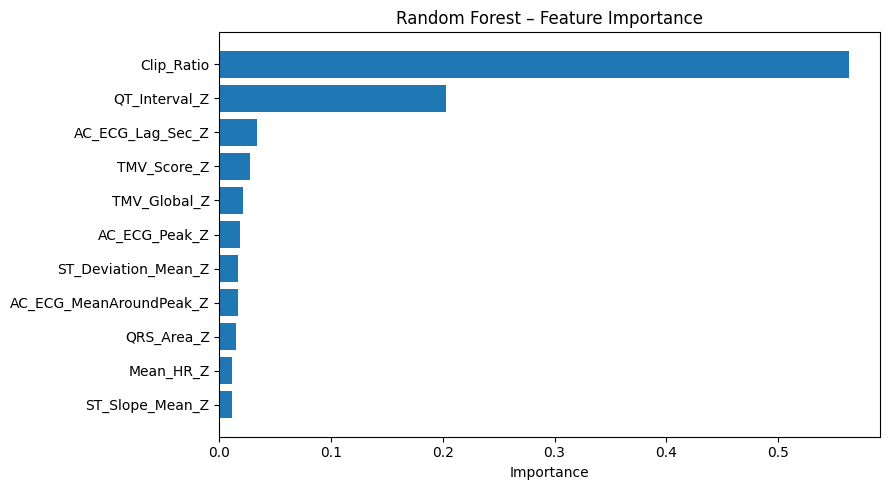

In [15]:
rf_importance = rf_best.feature_importances_

rf_fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_importance
}).sort_values("Importance", ascending=False)

print("\n=== Random Forest Feature Importance ===")
print(rf_fi_df.head(10))

plt.figure(figsize=(9, 5))
plt.barh(
    rf_fi_df["Feature"][:11][::-1],
    rf_fi_df["Importance"][:11][::-1]
)
plt.title("Random Forest – Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [16]:
import shap

# -------------------------------
# SHAP EXPLAINER
# -------------------------------
rf_explainer = shap.TreeExplainer(rf_best)
rf_shap_values = rf_explainer.shap_values(X)

# -------------------------------
# Rank features by mean |SHAP|
# -------------------------------
mean_abs_shap = np.mean(np.abs(rf_shap_values), axis=0)
top10_idx = np.argsort(mean_abs_shap)[-10:][::-1]

X_top10 = X[:, top10_idx]
shap_top10 = rf_shap_values[:, top10_idx]
features_top10 = [features[i] for i in top10_idx]

# -------------------------------
# Plot (figure-ready)
# -------------------------------
plt.figure(figsize=(7, 4.5))

shap.summary_plot(
    shap_top10,
    X_top10,
    feature_names=features_top10,
    plot_type="dot",
    show=False
)

plt.tight_layout()
plt.savefig("assets/shap_rf.png", dpi=300, bbox_inches="tight")
plt.close()


Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored



=== XGBoost Feature Importance ===
                    Feature  Importance
12                    avail    0.286915
4                Clip_Ratio    0.124783
0             QT_Interval_Z    0.097293
1               TMV_Score_Z    0.086485
6               TWAmp_Std_Z    0.067383
7                TWAmp_CV_Z    0.035311
17  AC_ECG_MeanAroundPeak_Z    0.032087
8              TMV_Global_Z    0.030573
14          ST_Slope_Mean_Z    0.029325
13      ST_Deviation_Mean_Z    0.026164
3              QRS_Global_Z    0.023006
5              T_Flatness_Z    0.022863
2                 Mean_HR_Z    0.022205
10               QRS_Area_Z    0.021363
11           QRS_Skewness_Z    0.021353


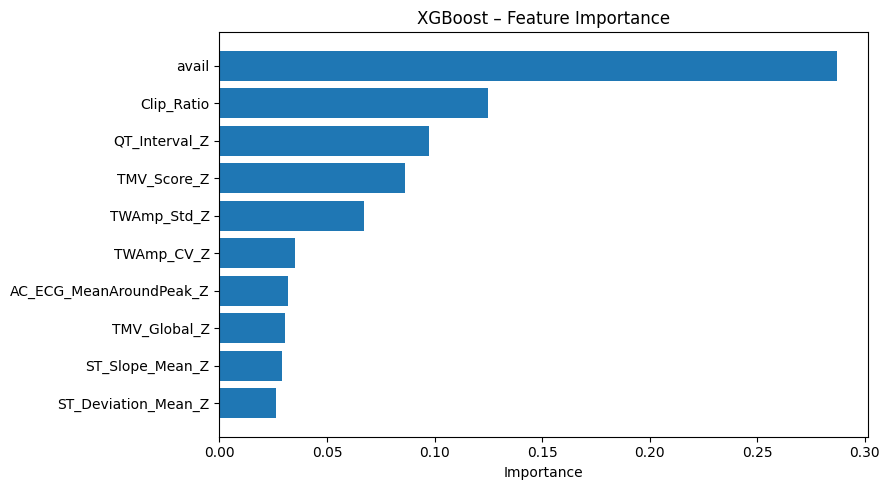

In [17]:
xgb_importance = xgb_best.feature_importances_

xgb_fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_importance
}).sort_values("Importance", ascending=False)

print("\n=== XGBoost Feature Importance ===")
print(xgb_fi_df.head(15))

plt.figure(figsize=(9, 5))
plt.barh(
    xgb_fi_df["Feature"][:10][::-1],
    xgb_fi_df["Importance"][:10][::-1]
)
plt.title("XGBoost – Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


[INFO] Computing SHAP for XGBoost (native pred_contribs)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


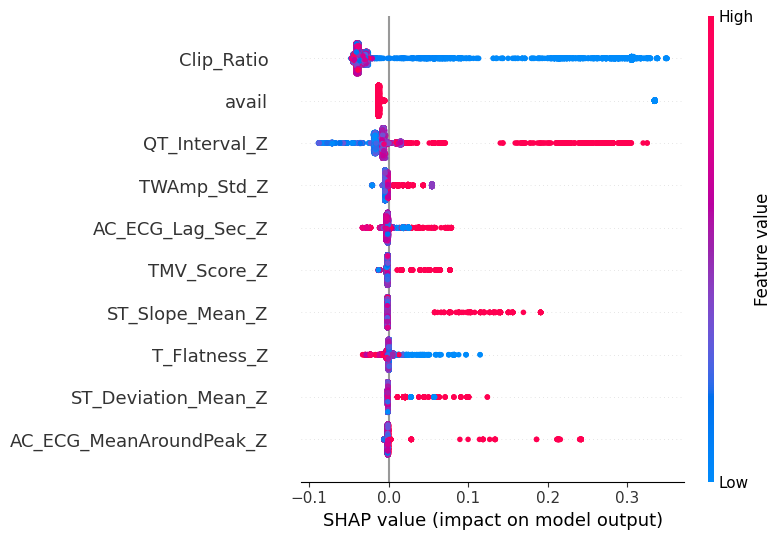

In [18]:
import xgboost

print("\n[INFO] Computing SHAP for XGBoost (native pred_contribs)")

# Native XGBoost SHAP (last column = bias)
xgb_shap_full = xgb_best.get_booster().predict(
    xgboost.DMatrix(X),
    pred_contribs=True
)

# Remove bias term
xgb_shap_values = xgb_shap_full[:, :-1]

# Rank features by mean absolute SHAP
mean_abs_shap = np.mean(np.abs(xgb_shap_values), axis=0)
top10_idx = np.argsort(mean_abs_shap)[-10:]   # top 10
top10_idx = top10_idx[::-1]                   # descending

# Slice arrays
X_top10 = X[:, top10_idx]
shap_top10 = xgb_shap_values[:, top10_idx]
features_top10 = [features[i] for i in top10_idx]

# Plot
shap.summary_plot(
    shap_top10,
    X_top10,
    feature_names=features_top10,
    plot_type="dot",
    show=True
)